### Importar bibliotecas

In [478]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, r2_score

### Importar base

In [248]:
# pré processamento por conta da vírgula no campo de intervalo do campo vl_bem
arquivo = '/home/brujojin/Documentos/Obsidian Vault/monitoramento_modelo/2_envio_case_base_Total_2026.csv'
import re

with open(arquivo) as f:
    texto = f.read()

texto = re.sub(r'\((\d+),\s*(\d+)\]', r'(\1;\2]', texto)

from io import StringIO
df = pd.read_csv(StringIO(texto), sep=",")

In [249]:
df.drop(columns=['Unnamed: 18'], inplace=True)

In [5]:
df.head()

,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,Profissao,entrada,prazo,pmt,target,FPD,score,contratado
0,534521536,202301,3_5,Chevrolet,(25000;70000],43,solteiro,0,18422,SE,liberais,20,12,2775,0.0,0.0,8,1
1,894445785,202301,10,Chevrolet,(25000;70000],39,solteiro,0,11175,N,empresarios,20,48,734,0.0,0.0,5,1
2,510004819,202301,1_2,Fiat,(25000;70000],37,solteiro,>2,26031,NE,consignados,30,36,1510,1.0,0.0,7,1
3,230978528,202301,10,VW,(25000;70000],61,casado,0,3009,SE,empresarios,20,36,1588,1.0,0.0,4,1
4,489909079,202301,3_5,Fiat,(25000;70000],48,casado,2,10253,CO,assalariados,30,12,2712,0.0,0.0,8,1


### Novas variáveis a criar

- prestacao/renda - comprometimento de renda
- prazo * pmt = total financiado com juros
- (min fx vl bem + max fx vl bem ) / 2 - média da faixa do valor do bem
- média da faixa da idade veiculo 
- média da faixa do valor do bem / média da faixa da idade veiculo  = valor médio por tempo médio de fabricação
- total financiado com juros / média da faixa da idade veiculo = valor a pagar do contrato por média de tempo do veículo
- separar as marcas por nacionalidade
- contar ids duplicados
- flg qt_restr
- a partir de quando foi a primeira restrição? (possível mudança de mercado)
- tx restrição mensal por renda
- Criar one hot encoder para veriifcar percentual por mês de cada categoria



In [250]:
df['comp_renda'] = df['pmt'] / df['renda']
df['tt_financiado_com_juros'] = df['pmt'] * df['prazo']
df['valor_min'] = df['vl_bem'].str.extract(r'\((\d+);').fillna(0).astype(int)
df['valor_max'] = df['vl_bem'].str.extract(r';(\d+)\]').fillna(0).astype(int)
df['valor_medio_fx'] = (df['valor_max'] + df['valor_min']) / 2

In [251]:
df['idade_veiculo'].unique()

def media_idade(row):
    if row.idade_veiculo == '3_5':
        return 4
    elif row.idade_veiculo == '1_2':
        return 1.5
    elif row.idade_veiculo == '6_10':
        return 8
    else:
        return int(row.idade_veiculo)

df['idade_media_veiculo'] = df.apply(media_idade, axis = 1)

In [252]:
#df['vl_medio_por_idade_media_veiculo'] = df['valor_medio_fx'] / df['idade_media_veiculo']
#df['vl_a_pagar_por_idade_media_veiculo'] = df['tt_financiado_com_juros'] / df['idade_media_veiculo']


df['vl_medio_por_idade_media_veiculo']  = np.divide(
    df['valor_medio_fx'],
    df['idade_media_veiculo'],
    out=np.zeros_like(df['valor_medio_fx'], dtype=float),
    where=df['idade_media_veiculo'] != 0
)

df['vl_a_pagar_por_idade_media_veiculo']  = np.divide(
    df['tt_financiado_com_juros'],
    df['idade_media_veiculo'],
    out=np.zeros_like(df['tt_financiado_com_juros'], dtype=float),
    where=df['idade_media_veiculo'] != 0
)


In [253]:
# nacionalidade da marca
nacionalidade_marcas = {
    'Chevrolet': 'Estados Unidos',
    'Fiat': 'Itália',
    'VW': 'Alemanha',
    'Ford': 'Estados Unidos',
    'Toyota': 'Japão',
    'Outros': 'Outros',
    'Honda': 'Japão',
    'Nissan': 'Japão',
    'Peugeot': 'França',
    'Hyundai': 'Coreia do Sul',
    'Jac': 'China'
}
df['nacionalidade'] = df['marca'].map(nacionalidade_marcas)

In [254]:
# id duplicado
df['id_duplicado'] = df['id'].duplicated()

In [255]:
# se tem alguma restrição, marcar
df['flg_restr'] = (df['qt_restr'] != '0').astype(int)

### Pilar 1: Estabilidade

In [256]:
# Inserção dos períodos de treinamento e observação do modelo

peri_treinamento = [202203,202204,202205,202206,202207,202208,202209,202210,202211,202212,202301,202302]
peri_observacao = [202303,202304,202305,202306,202307,202308,202309,202310,202311,202312,202401,202402]

In [257]:
meses = df.groupby('ano_mes').size().index
meses


Index([202203, 202204, 202205, 202206, 202207, 202208, 202209, 202210, 202211,
       202212, 202301, 202302, 202303, 202304, 202305, 202306, 202307, 202308,
       202309, 202310, 202311, 202312, 202401, 202402, 202403, 202404, 202405,
       202406, 202407, 202408, 202409, 202410, 202411, 202412, 202501, 202502,
       202503, 202504, 202505, 202506, 202507, 202508, 202509, 202510, 202511,
       202512],
      dtype='int64', name='ano_mes')

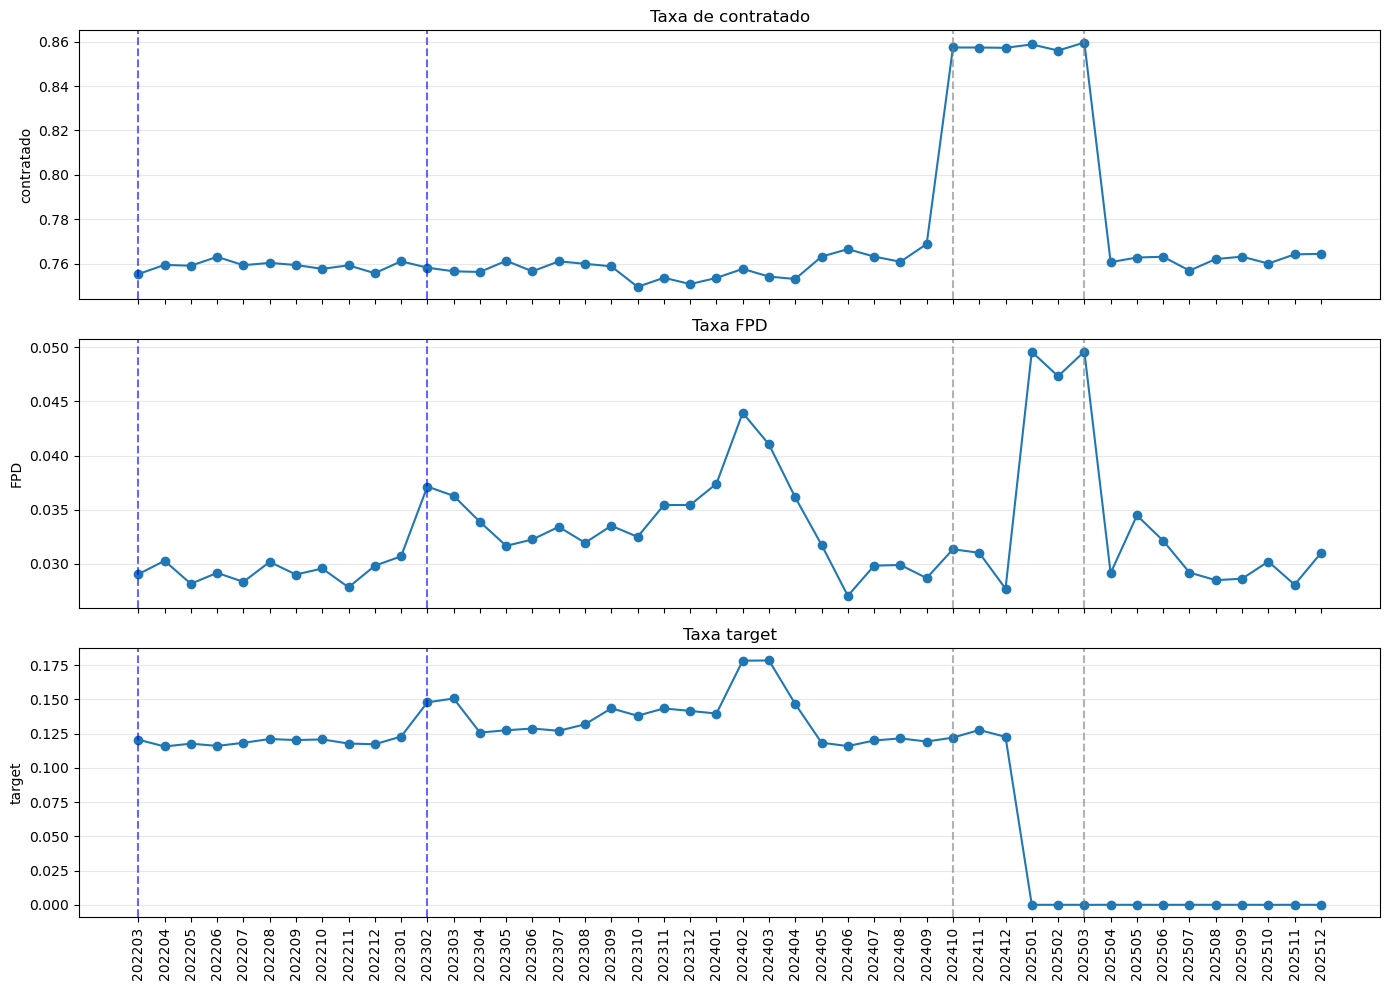

In [258]:
import matplotlib.pyplot as plt

# agregação
df_mes = df.groupby('ano_mes')[['contratado','FPD','target']].mean()

meses = df_mes.index
x = range(len(meses))

fig, ax = plt.subplots(3,1, figsize=(14,10), sharex=True)

# contratado
ax[0].plot(x, df_mes['contratado'], marker='o')
ax[0].set_title('Taxa de contratado')
ax[0].set_ylabel('contratado')

# FPD
ax[1].plot(x, df_mes['FPD'], marker='o')
ax[1].set_title('Taxa FPD')
ax[1].set_ylabel('FPD')

# target
ax[2].plot(x, df_mes['target'], marker='o')
ax[2].set_title('Taxa target')
ax[2].set_ylabel('target')

# eixo X
ax[2].set_xticks(x)
ax[2].set_xticklabels(meses, rotation=90)

# grid melhora leitura
for a in ax:
    a.grid(axis='y', alpha=0.3)

ax[0].axvline(31, color="gray", linestyle="--", alpha=0.6)
ax[0].axvline(36, color="gray", linestyle="--", alpha=0.6)

ax[0].axvline(0, color="blue", linestyle="--", alpha=0.6)
ax[0].axvline(11, color="blue", linestyle="--", alpha=0.6)

ax[1].axvline(31, color="gray", linestyle="--", alpha=0.6)
ax[1].axvline(36, color="gray", linestyle="--", alpha=0.6)

ax[1].axvline(0, color="blue", linestyle="--", alpha=0.6)
ax[1].axvline(11, color="blue", linestyle="--", alpha=0.6)

ax[2].axvline(31, color="gray", linestyle="--", alpha=0.6)
ax[2].axvline(36, color="gray", linestyle="--", alpha=0.6)

ax[2].axvline(0, color="blue", linestyle="--", alpha=0.6)
ax[2].axvline(11, color="blue", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Observa-se crescimento na taxa de FPD no início dos anos 2024 e 2025. Provável componente sazonal
Taxa contratado que aumenta em out/24 a mar/25 será avaliada posteriormente

#### PSI

In [259]:
# dataframe com os meses de estabilidade, para calcular o percentual de cada score na base do período

df_score_medio_treinamento = pd.DataFrame()
df_score_medio_treinamento['qtd_score'] = df[df['ano_mes'].isin(peri_treinamento)].groupby(['score'])['id'].count()
df_score_medio_treinamento['qtd'] = df[df['ano_mes'].isin(peri_treinamento)]['id'].count()
df_score_medio_treinamento['perc_score'] = df_score_medio_treinamento['qtd_score'] / df_score_medio_treinamento['qtd']
df_score_medio_treinamento





,qtd_score,qtd,perc_score
score,,,
1,7195,239889,0.029993
2,9525,239889,0.039706
3,16929,239889,0.070570
4,21352,239889,0.089008
5,31295,239889,0.130456
6,38184,239889,0.159174
7,50673,239889,0.211235
8,38082,239889,0.158748
9,21482,239889,0.089550


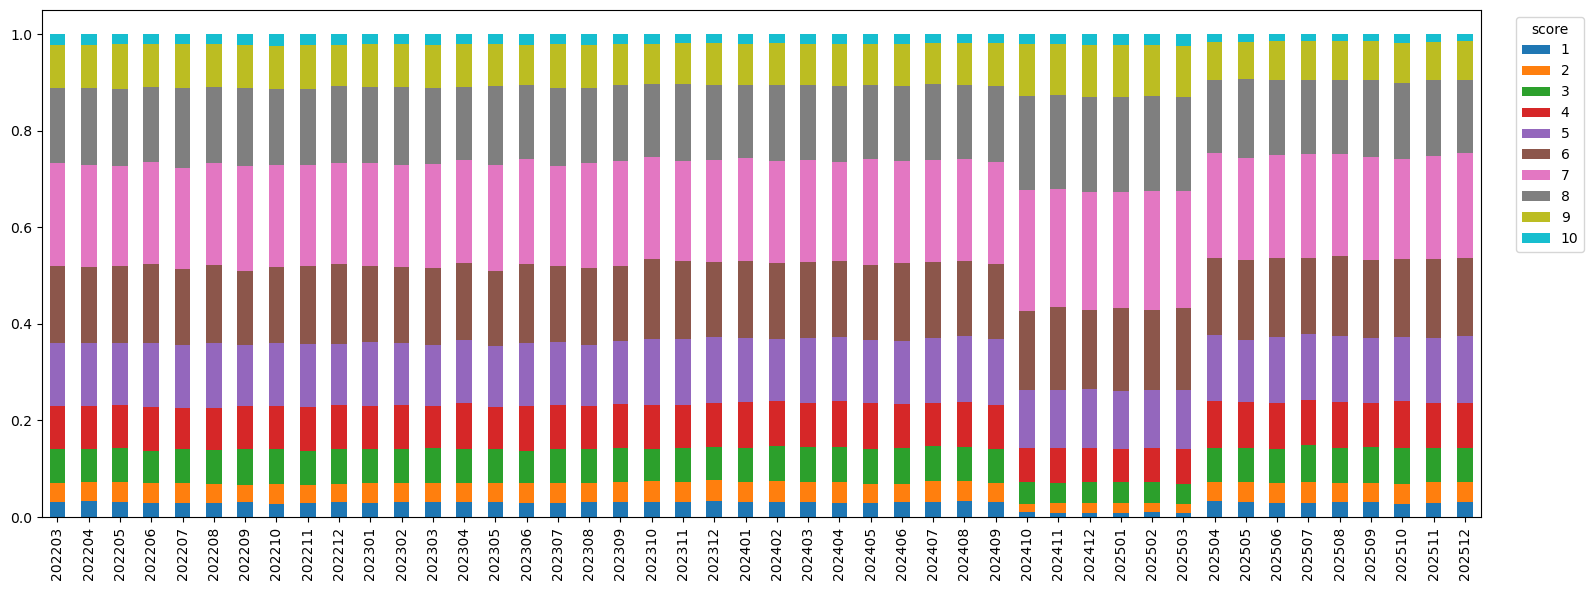

In [260]:
df_estb = pd.crosstab(
    df['ano_mes'],
    df['score'],
    normalize='index'
).reindex(columns=range(1,11), fill_value=0)
df_estb.index.name = None

# gravar a média por score, já visto anteriormente
dist_treino = df_estb.loc[peri_treinamento].mean()

# gráfico de participação por faixa

fig, ax = plt.subplots(figsize=(16,6))
df_estb.plot(kind='bar', stacked=True, ax=ax)
ax.legend(title='score', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()

Observada variação na distribuição dos scores entre out/24 a abr/25. No entanto, é necessário avaliar as métricas para saber o quanto essa mudança pode ser impactante para a continuidade do modelo

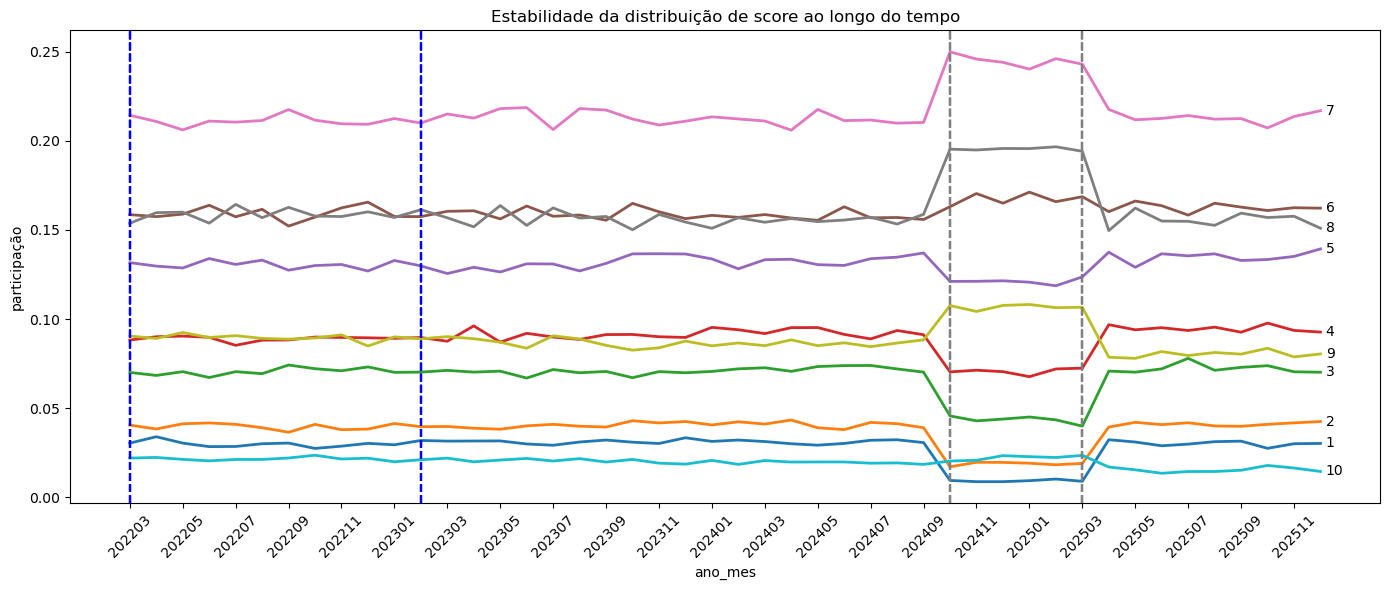

In [261]:

# gerar todos os meses do período
meses = pd.period_range("2022-03", "2025-12", freq="M").astype(str)
meses = [m.replace("-", "") for m in meses]

pos = np.arange(len(meses))

ax.set_xlim(0, len(meses)-1)

ticks = pos[::3]   # mostrar a cada 3 meses
ax.set_xticks(ticks)
ax.set_xticklabels([meses[i] for i in ticks], rotation=45)

df_plot = df_estb.copy()
df_plot.index = range(len(df_plot))

fig, ax = plt.subplots(figsize=(14,6))

df_plot.plot(ax=ax, legend=False, linewidth=2)

ax.set_title("Estabilidade da distribuição de score ao longo do tempo")
ax.set_xlabel("ano_mes")
ax.set_ylabel("participação")

ticks = range(0, len(df_plot.index), 2)

ax.set_xticks(ticks)
ax.set_xticklabels(df_estb.index[ticks], rotation=45)

# rótulos das linhas
for line, label in zip(ax.lines, df_plot.columns):

    x = line.get_xdata()[-1]
    y = line.get_ydata()[-1]

    ax.text(x + 0.2, y, str(label), va="center")

    ax.axvline(31, color="gray", linestyle="--", alpha=0.6)
    ax.axvline(36, color="gray", linestyle="--", alpha=0.6)

    ax.axvline(0, color="blue", linestyle="--", alpha=0.6)
    ax.axvline(11, color="blue", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()



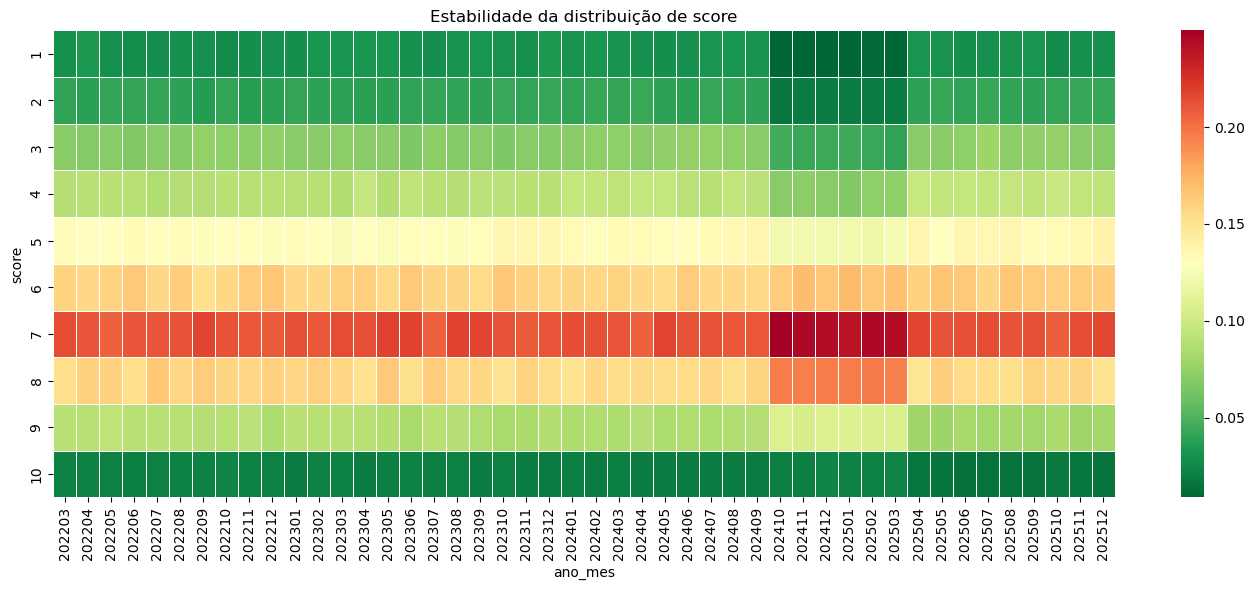

In [262]:
fig, ax = plt.subplots(figsize=(14,6))

sns.heatmap(
    df_estb.T,
    cmap="RdYlGn_r",
    linewidths=0.5,
    ax=ax
)

ax.set_title("Estabilidade da distribuição de score")
ax.set_xlabel("ano_mes")
ax.set_ylabel("score")

plt.tight_layout()
plt.show()

Pelos gráficos, percebemos quedas nas categorias de 1 a 5, e com altas nas categorias 6 a 10 por um período de tempo, voltando aos patamares próximos ao do treinamento nos meses mais recentes

Para avaliar se as variações das participações de score foram o suficiente para afetar a estabilidade do modelo, avaliaremos o PSI e carta de controle do score médio ponderado.

In [263]:
def calcular_psi(expected, actual):

    expected = np.array(expected)
    actual = np.array(actual)

    # evitar divisão por zero
    expected = np.where(expected==0, 0.00001, expected)
    actual = np.where(actual==0, 0.00001, actual)

    psi = np.sum((actual - expected) * np.log(actual/expected))

    return psi

psi_mensal = {}

for mes in df_estb.index:
    psi_mensal[mes] = calcular_psi(dist_treino, df_estb.loc[mes])

psi_df = pd.DataFrame.from_dict(psi_mensal, orient='index', columns=['psi'])
psi_df

,psi
202203,0.000271
202204,0.000690
202205,0.000341
202206,0.000795
202207,0.000509
202208,0.000156
202209,0.001151
202210,0.000529
202211,0.000260
202212,0.000787


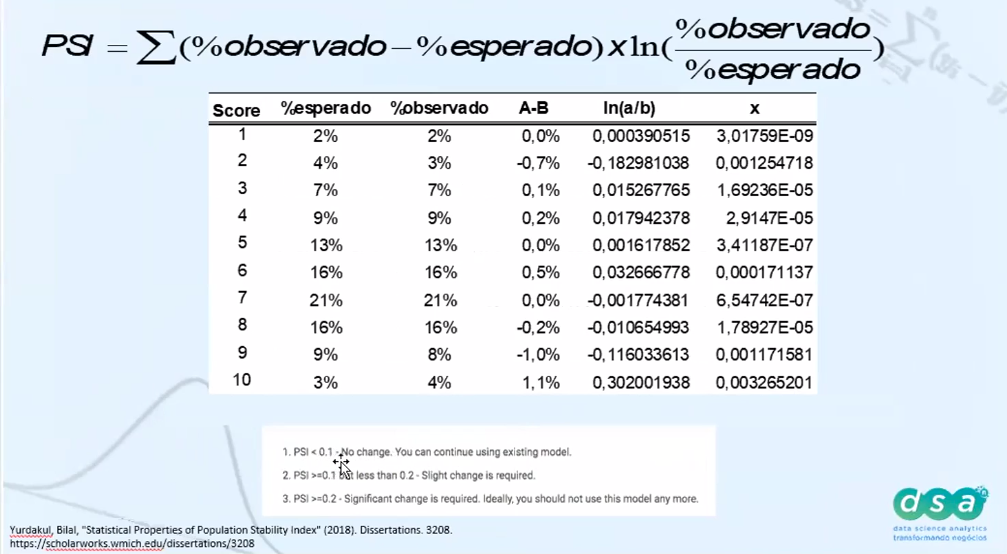

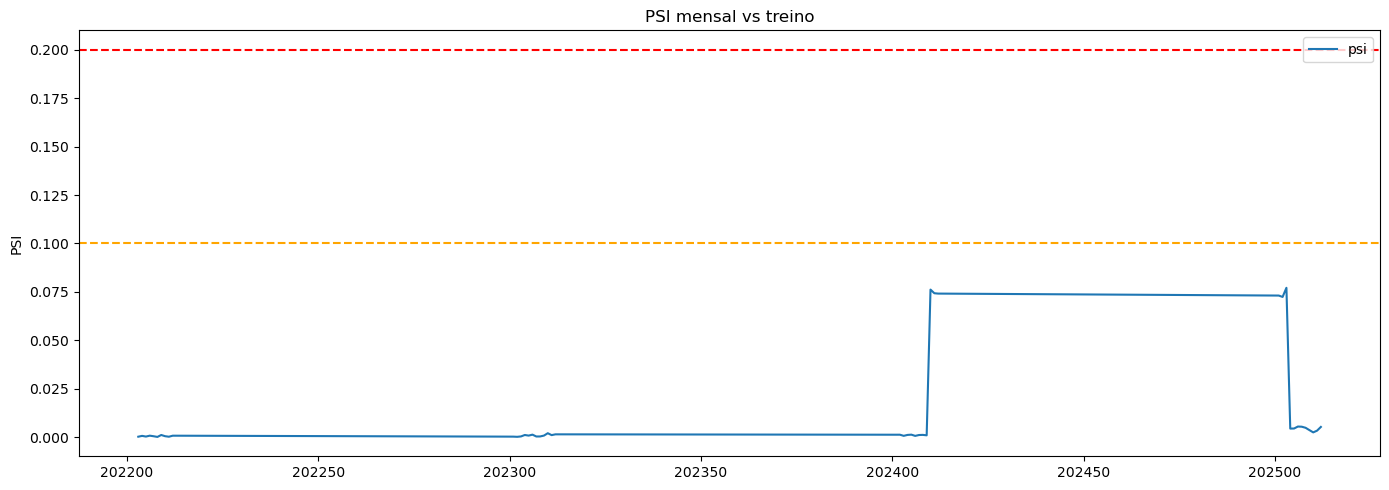

In [264]:
fig, ax = plt.subplots(figsize=(14,5))

psi_df.plot(ax=ax)

ax.axhline(0.1, color='orange', linestyle='--')
ax.axhline(0.2, color='red', linestyle='--')

ax.set_title('PSI mensal vs treino')
ax.set_ylabel('PSI')

plt.tight_layout()

Pela avaliação do PSI, em relação aos valores de referência, por não passar de 0.1, é um indício que o modelo permanece estável, apesar da flutuação observada

In [265]:
psi_df[psi_df['psi'] > 0.02]
# meses entre 

,psi
202410,0.076185
202411,0.074313
202412,0.074125
202501,0.073110
202502,0.072401
202503,0.077112


#### Score médio - carta de controle

In [266]:
df_dist_treino = dist_treino.reset_index()
df_dist_treino.columns = ['score','dist']
df_dist_treino['prod'] = df_dist_treino['score'] * df_dist_treino['dist']
media_score_treinamento = df_dist_treino['prod'].sum()

In [267]:
df_estb['score_medio'] = df_estb.mul(df_estb.columns, axis=1).sum(axis=1)
psi = []

for mes in df_estb.index:
    psi.append(calcular_psi(dist_treino, df_estb.loc[mes, df_estb.columns[:-1]]))

df_estb['psi'] = psi
df_estb

score,1,2,3,4,5,6,7,8,9,10,score_medio,psi
202203,0.030406,0.040508,0.070067,0.088231,0.131675,0.158597,0.214332,0.153720,0.090470,0.021996,6.048768,0.000271
202204,0.033987,0.038329,0.068374,0.090083,0.129710,0.157459,0.210860,0.159705,0.089135,0.022359,6.048860,0.000690
202205,0.030406,0.041251,0.070491,0.090458,0.128668,0.158871,0.206152,0.159986,0.092434,0.021284,6.050474,0.000341
202206,0.028437,0.041727,0.067205,0.089774,0.133959,0.163850,0.211094,0.153819,0.089674,0.020462,6.045388,0.000795
202207,0.028522,0.040936,0.070493,0.085271,0.130640,0.157389,0.210493,0.164335,0.090690,0.021232,6.077143,0.000509
202208,0.030056,0.039058,0.069364,0.088168,0.133077,0.161582,0.211392,0.156881,0.089168,0.021254,6.053661,0.000156
202209,0.030426,0.036501,0.074208,0.088266,0.127429,0.152182,0.217553,0.162675,0.088718,0.022041,6.072501,0.001151
202210,0.027422,0.040910,0.072151,0.089904,0.130021,0.157195,0.211594,0.157790,0.089408,0.023604,6.062779,0.000529
202211,0.028694,0.037942,0.070986,0.089682,0.130624,0.162368,0.209558,0.157518,0.091132,0.021496,6.065787,0.000260
202212,0.030262,0.038278,0.073150,0.089483,0.126960,0.165589,0.209279,0.160178,0.084874,0.021945,6.042237,0.000787


In [268]:
desvpad_score_trein = df_estb[df_estb.index.isin(peri_treinamento)]['score_medio'].std()
# limites da carta de controle
lim_sup = media_score_treinamento + 2* desvpad_score_trein
lim_inf = media_score_treinamento - 2* desvpad_score_trein

print(f'média treinamento : {media_score_treinamento}, desvio padrão: {desvpad_score_trein}')
print(f'limite superior : {lim_sup}, limite inferior: {lim_inf}')

média treinamento : 6.05460473646126, desvio padrão: 0.011999456578819265
limite superior : 6.078603649618898, limite inferior: 6.030605823303622


In [269]:
df_estb['media'] = media_score_treinamento
df_estb['desvio'] = desvpad_score_trein
df_estb['lim_sup'] = lim_sup
df_estb['lim_inf'] = lim_inf
df_estb.head()

score,1,2,3,4,5,6,7,8,9,10,score_medio,psi,media,desvio,lim_sup,lim_inf
202203,0.030406,0.040508,0.070067,0.088231,0.131675,0.158597,0.214332,0.153720,0.090470,0.021996,6.048768,0.000271,6.054605,0.011999,6.078604,6.030606
202204,0.033987,0.038329,0.068374,0.090083,0.129710,0.157459,0.210860,0.159705,0.089135,0.022359,6.048860,0.000690,6.054605,0.011999,6.078604,6.030606
202205,0.030406,0.041251,0.070491,0.090458,0.128668,0.158871,0.206152,0.159986,0.092434,0.021284,6.050474,0.000341,6.054605,0.011999,6.078604,6.030606
202206,0.028437,0.041727,0.067205,0.089774,0.133959,0.163850,0.211094,0.153819,0.089674,0.020462,6.045388,0.000795,6.054605,0.011999,6.078604,6.030606
202207,0.028522,0.040936,0.070493,0.085271,0.130640,0.157389,0.210493,0.164335,0.090690,0.021232,6.077143,0.000509,6.054605,0.011999,6.078604,6.030606


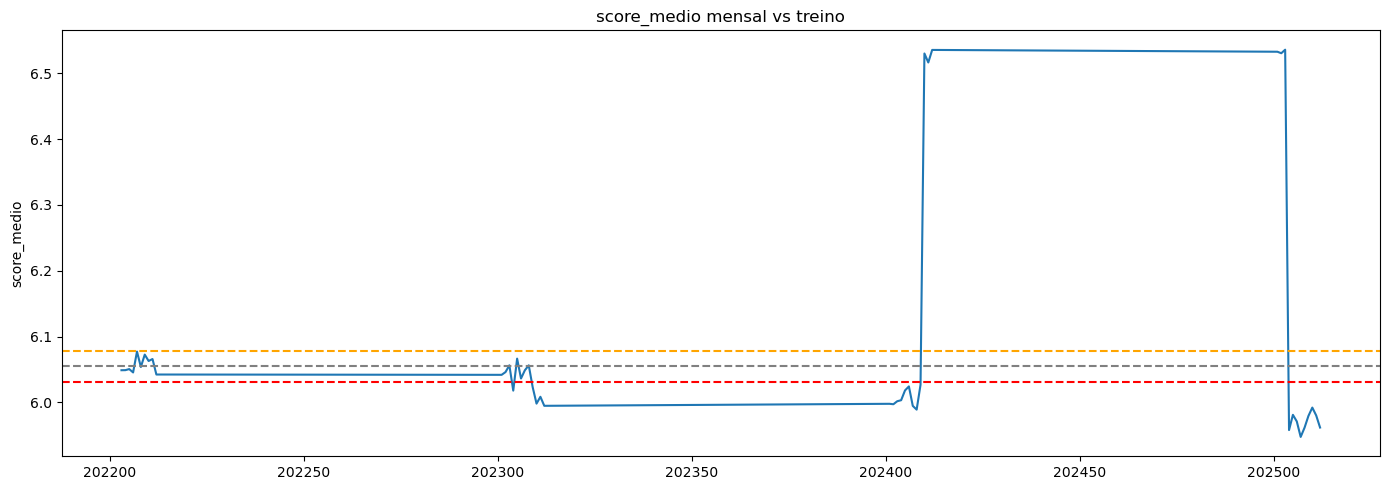

In [270]:
fig, ax = plt.subplots(figsize=(14,5))

df_estb['score_medio'].plot(ax=ax)

ax.axhline(lim_sup, color='orange', linestyle='--')
ax.axhline(lim_inf, color='red', linestyle='--')
ax.axhline(media_score_treinamento, color='gray', linestyle='--')

ax.set_title('score_medio mensal vs treino')
ax.set_ylabel('score_medio')

plt.tight_layout()

sai dos limites da carta de controle. Porém, o desvio durante o treinamento é muito baixo. Inclusive, pela regra do PSI, o modelo é considerado estável. 
Abaixo o gráfico com o eixo começando em 0 para olhar em perspectiva a variação do score

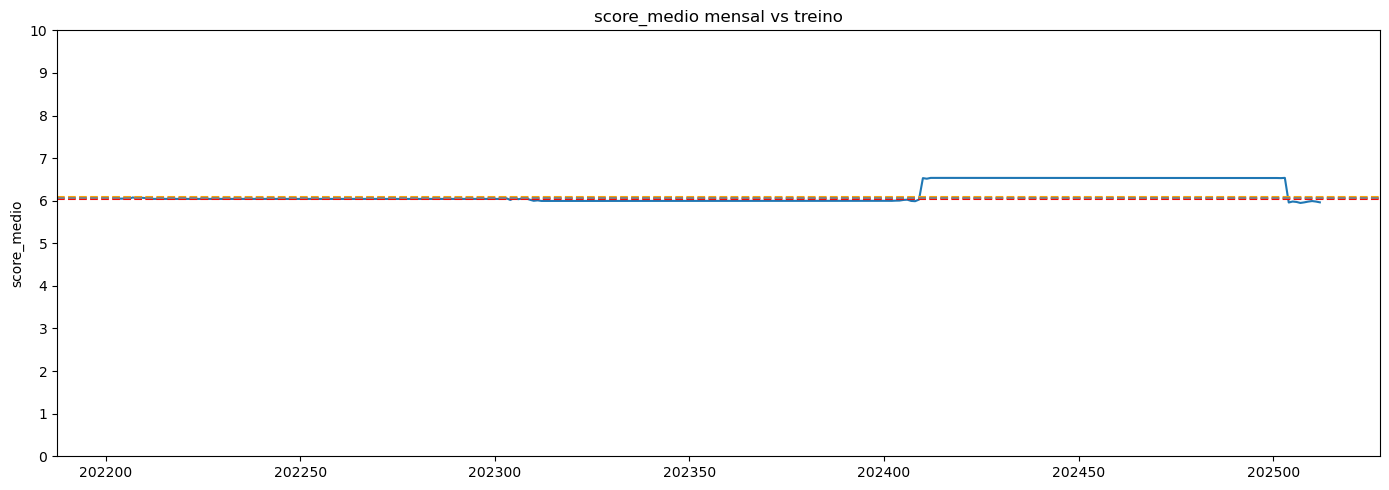

In [271]:
fig, ax = plt.subplots(figsize=(14,5))

df_estb['score_medio'].plot(ax=ax)

ax.axhline(lim_sup, color='orange', linestyle='--')
ax.axhline(lim_inf, color='red', linestyle='--')
ax.axhline(media_score_treinamento, color='gray', linestyle='--')
ax.set_ylim(0, 10)
ax.set_yticks(range(0,11))

ax.set_title('score_medio mensal vs treino')
ax.set_ylabel('score_medio')

plt.tight_layout()

#### Avaliação de estabilidade por variável
Visando encontrar se alguma variável também apresentou flutuação relevante entre os meses out/24 e mar/25

In [69]:
df.head()

,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,...,tt_financiado_com_juros,valor_min,valor_max,valor_medio_fx,idade_media_veiculo,vl_medio_por_idade_media_veiculo,vl_a_pagar_por_idade_media_veiculo,nacionalidade,id_duplicado,flg_restr
0,534521536,202301,3_5,Chevrolet,(25000;70000],43,solteiro,0,18422,SE,...,33300,25000,70000,47500.0,4.0,11875.000000,8325.0,Estados Unidos,False,0
1,894445785,202301,10,Chevrolet,(25000;70000],39,solteiro,0,11175,N,...,35232,25000,70000,47500.0,10.0,4750.000000,3523.2,Estados Unidos,False,0
2,510004819,202301,1_2,Fiat,(25000;70000],37,solteiro,>2,26031,NE,...,54360,25000,70000,47500.0,1.5,31666.666667,36240.0,Itália,False,1
3,230978528,202301,10,VW,(25000;70000],61,casado,0,3009,SE,...,57168,25000,70000,47500.0,10.0,4750.000000,5716.8,Alemanha,False,0
4,489909079,202301,3_5,Fiat,(25000;70000],48,casado,2,10253,CO,...,32544,25000,70000,47500.0,4.0,11875.000000,8136.0,Itália,False,1


In [272]:
def diag_estab(df, variavel):

    df_graf = pd.crosstab(
        df['ano_mes'],
        df[variavel],
        normalize='index'
    )

    df_graf.index.name = None

    # gráfico de participação
    fig, ax = plt.subplots(figsize=(16,6))
    df_graf.plot(kind='bar', stacked=True, ax=ax)

    ax.legend(title=variavel, bbox_to_anchor=(1.02,1), loc='upper left')
    ax.set_title(f"Distribuição de {variavel} por mês")
    ax.set_xlabel("ano_mes")
    ax.set_ylabel("participação")

    plt.tight_layout()
    plt.show()

    # heatmap de estabilidade
    fig, ax = plt.subplots(figsize=(14,6))

    sns.heatmap(
        df_graf.T,
        cmap="RdYlGn_r",
        linewidths=0.5,
        ax=ax
    )

    ax.set_title(f"Estabilidade da distribuição de {variavel}")
    ax.set_xlabel("ano_mes")
    ax.set_ylabel(variavel)

    plt.tight_layout()
    plt.show()

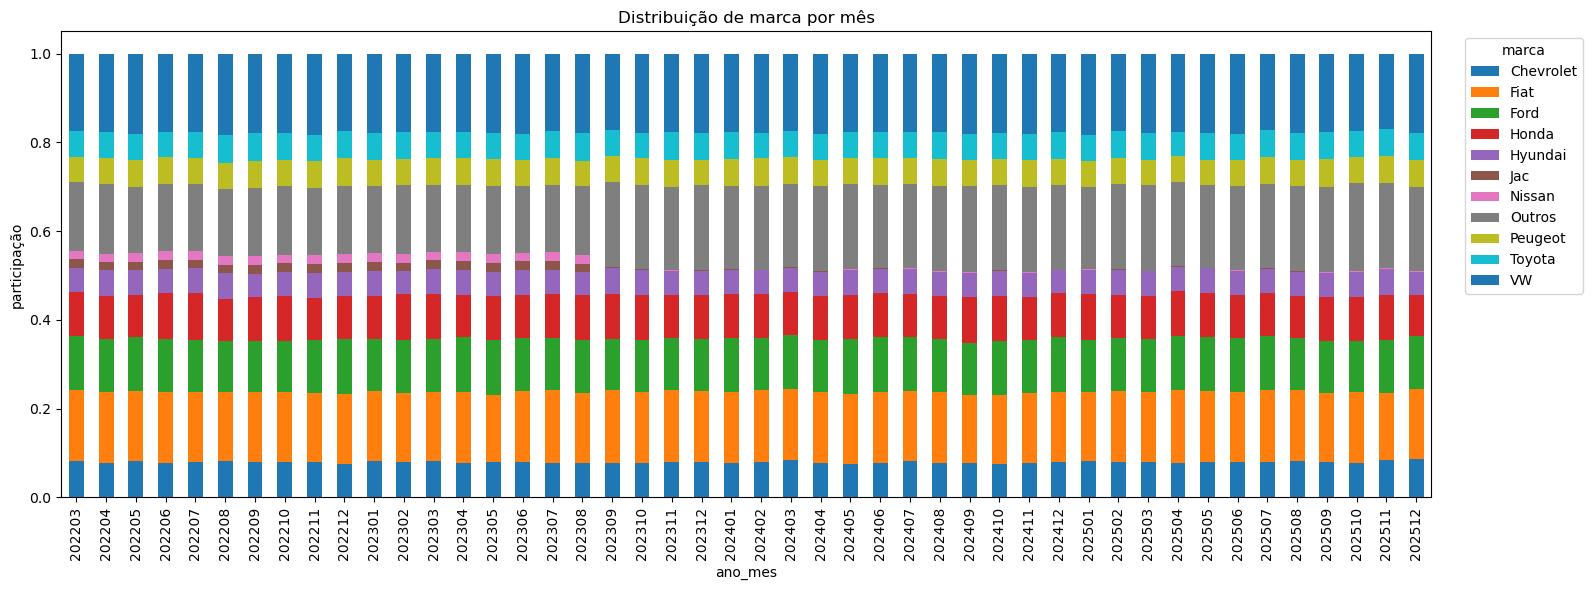

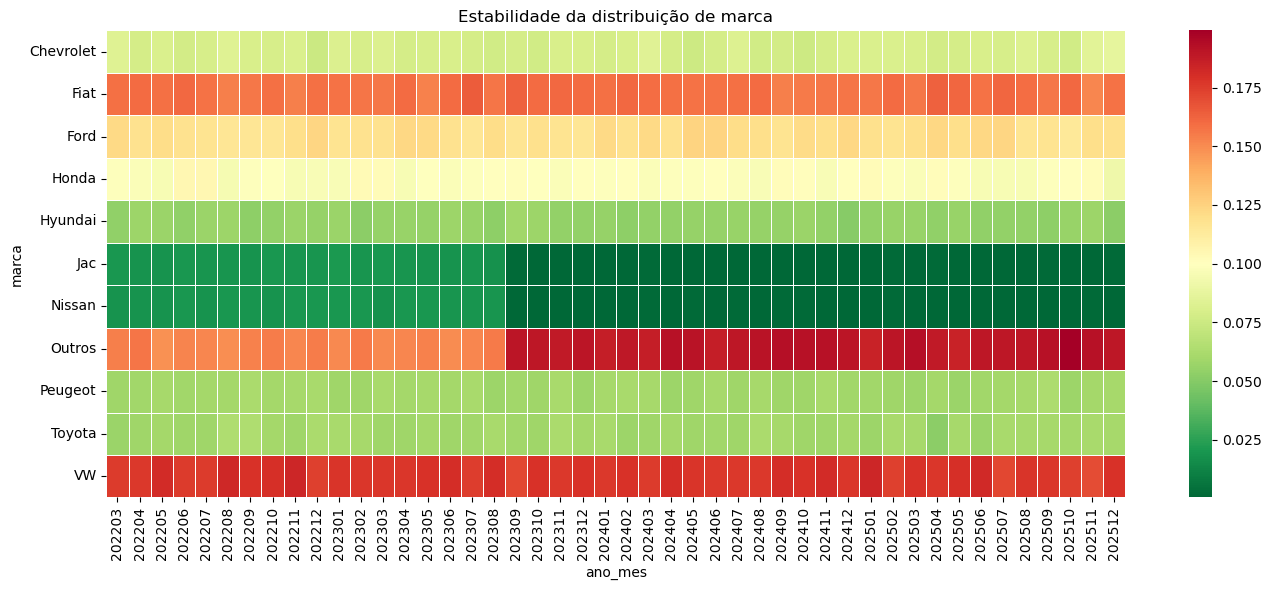

In [273]:
diag_estab(df,'marca')

Relativa estabilidade entre as marcas. Porém a participação de Jac e Nissan cessam e parece que é compensada pela categoria "Outros". Uma hipótese é delas entrarem na categoria Outros por conta da baixa representatividade

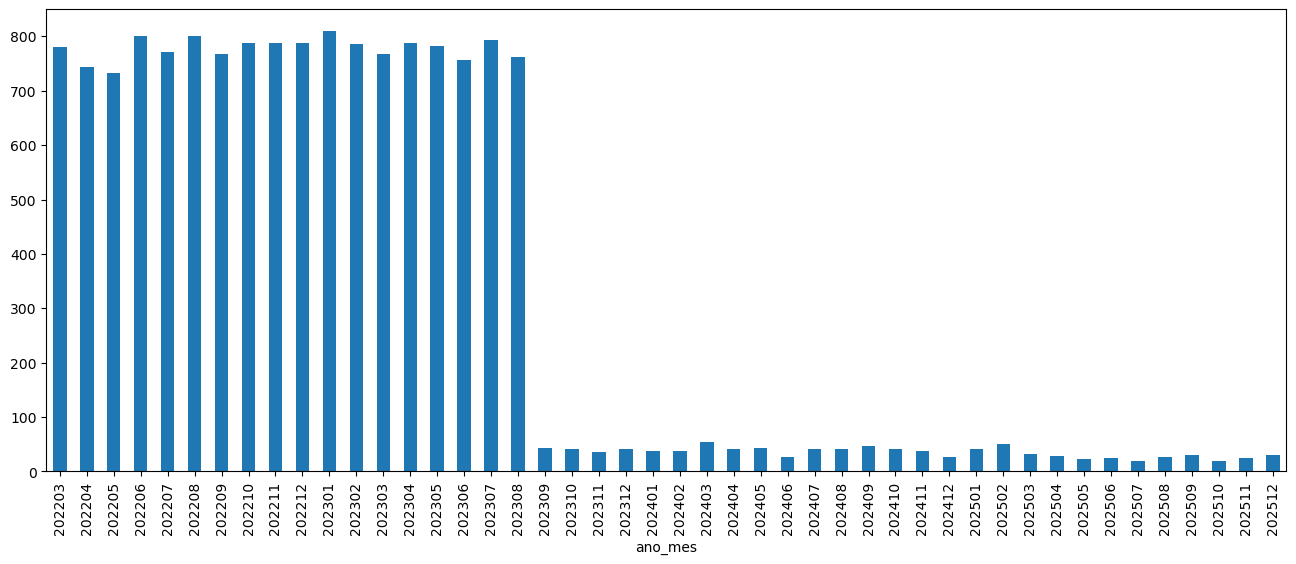

In [274]:
plt.figure(figsize=(16,6))
df[df['marca'].isin(['Jac','Nissan'])].groupby(['ano_mes'])['id'].count().plot(kind='bar')
plt.show()

Marcas continuam na base, o que provavelmente indica que elas não foram incluidas no "Outros", mas reduziram drásticamente sua participação

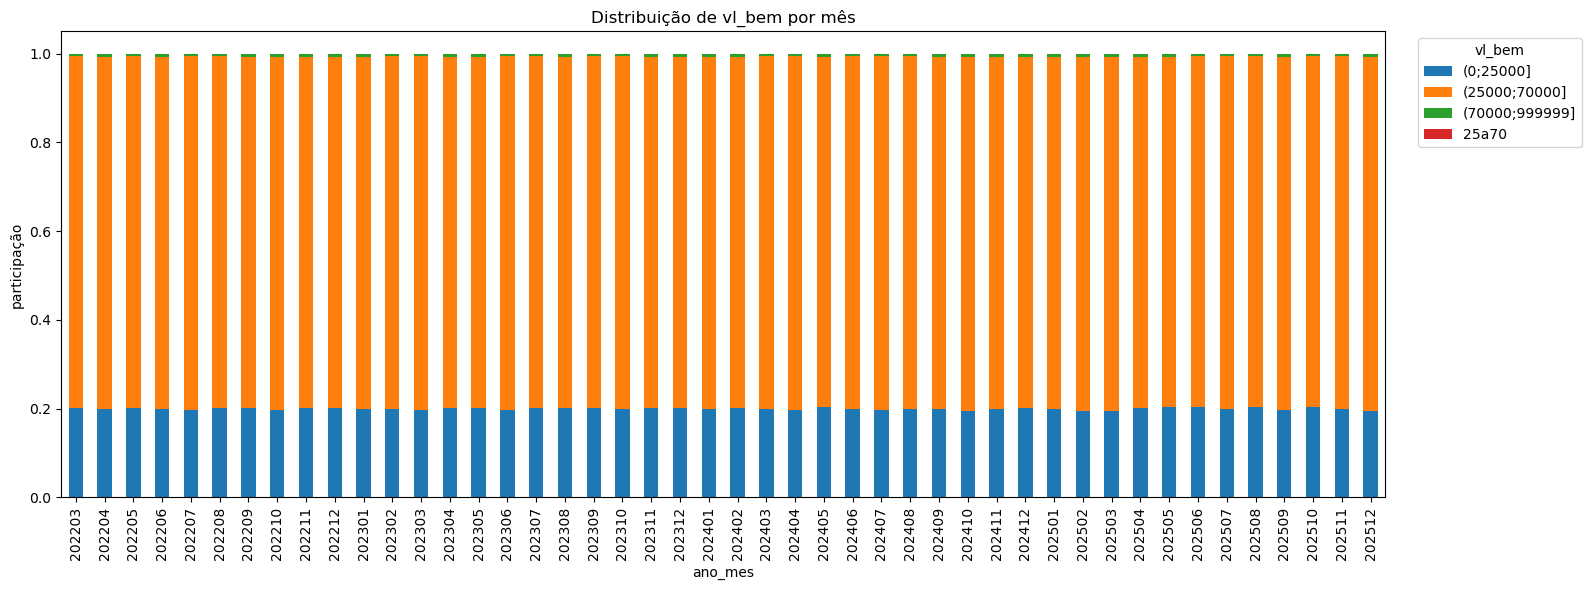

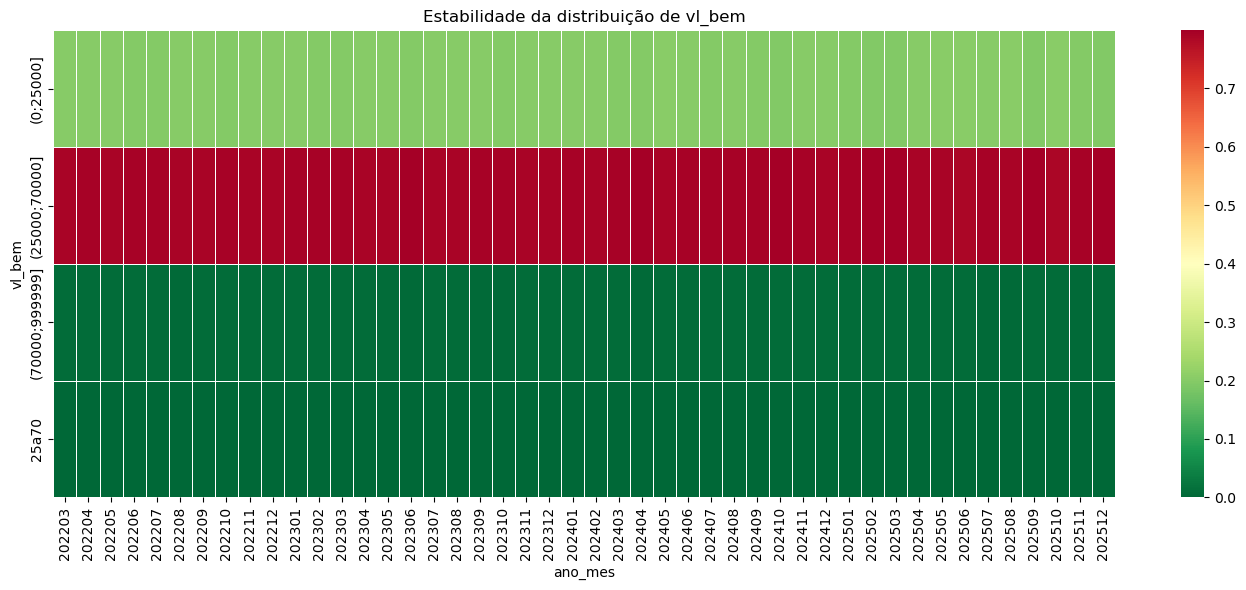

In [275]:
diag_estab(df,'vl_bem')



estabilidade entre as faixas de valores

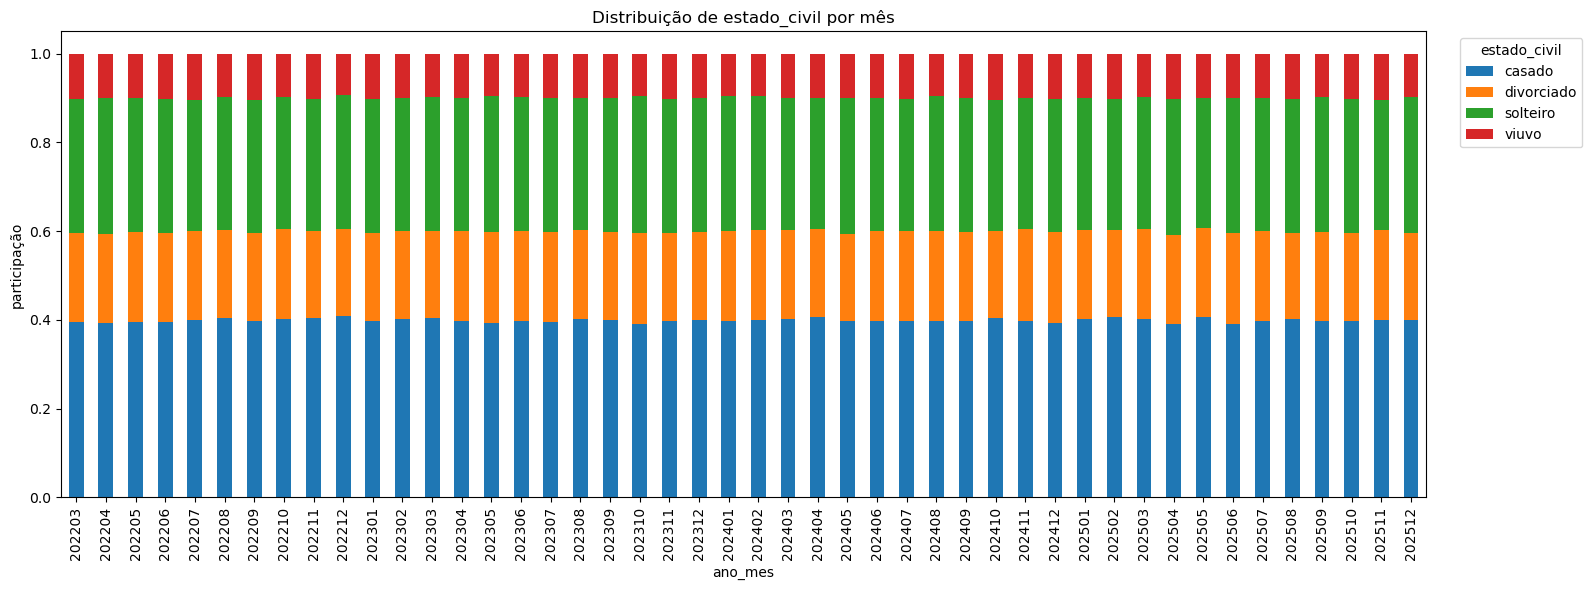

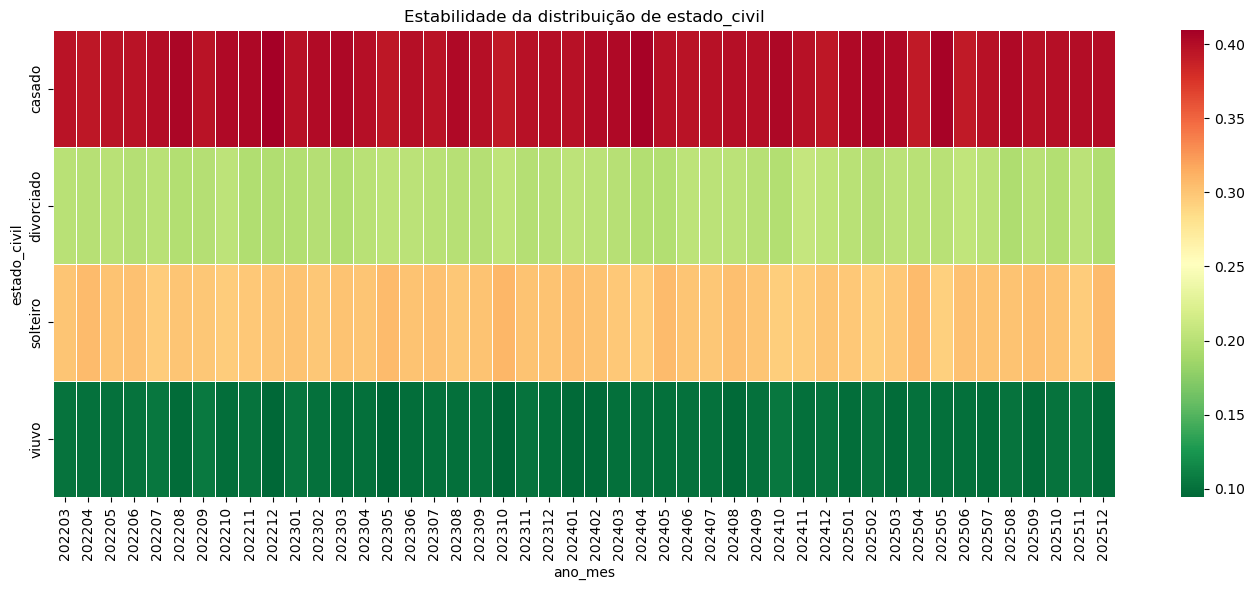

In [276]:
diag_estab(df,'estado_civil')

estabilidade entre estados civis

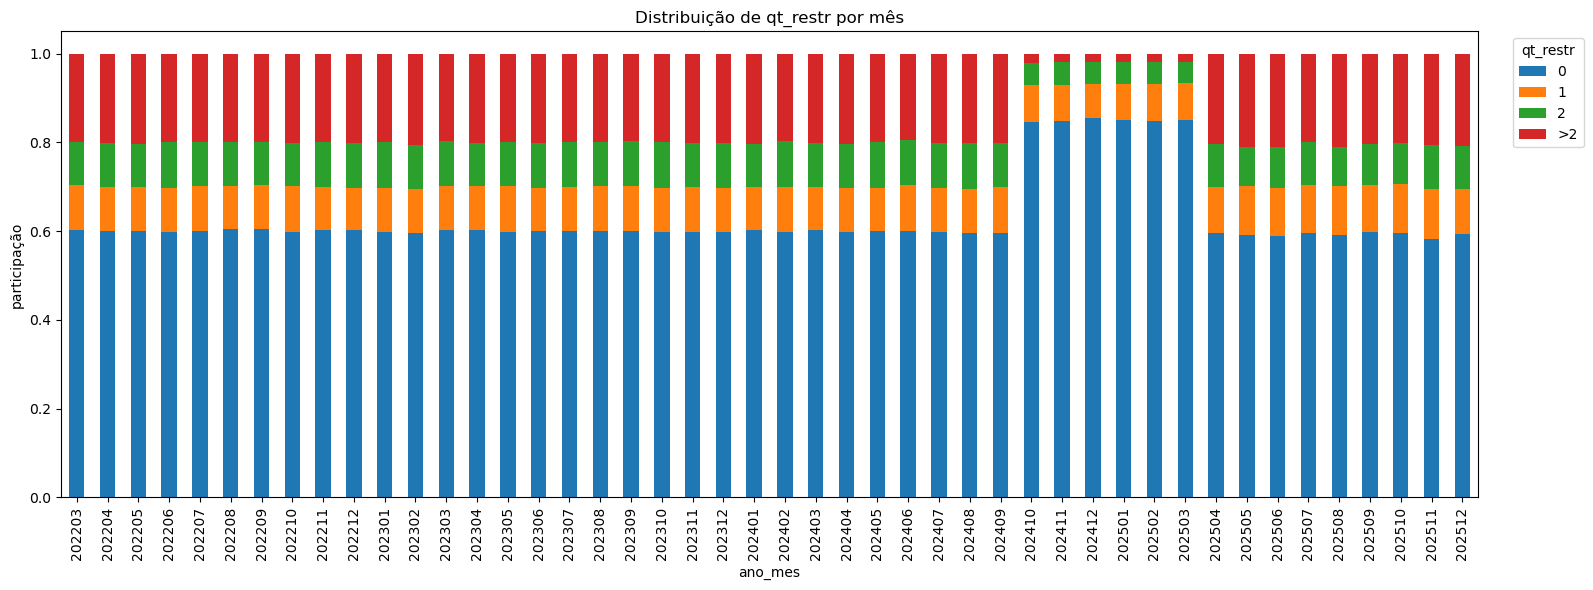

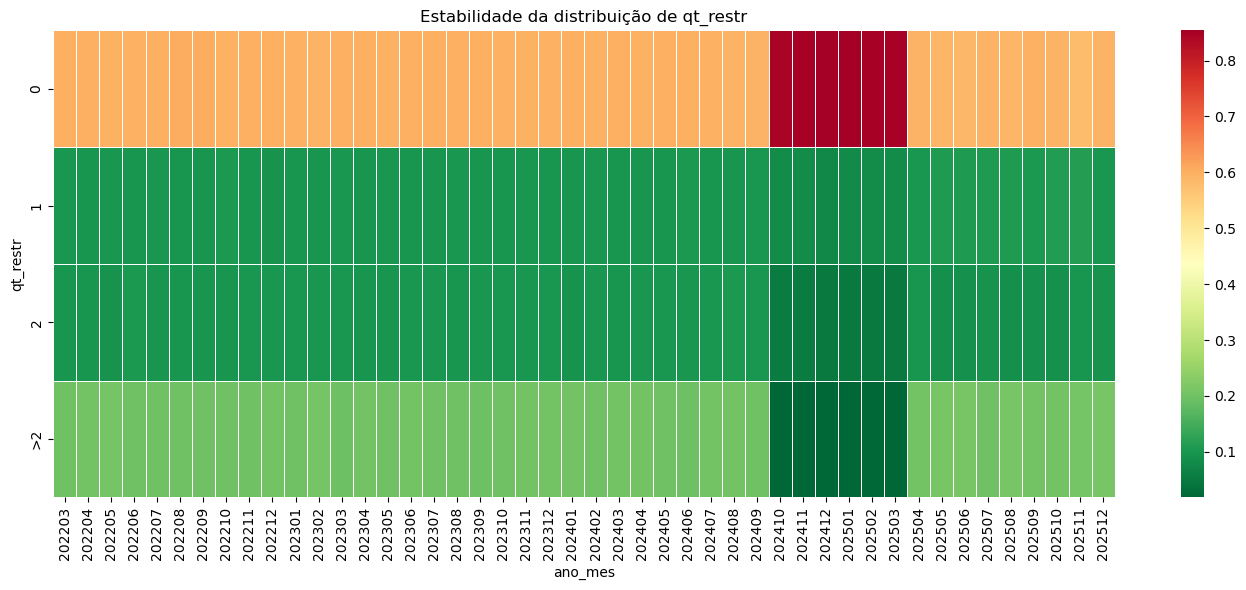

In [277]:
diag_estab(df,'qt_restr')

**easter egg 1 encontrado:** 
> Variação relevante na quantidade de restritivos em aberto no mercado no mesmo período de mudança no score. Percebe-se que aumenta a proporção de "0" (sem aberturas), o que pode indicar uma falha de base ou de recebimento dessa variável, pois não faz sentido econômico voltar ao patamar anterior depois desse período "de uma vez só"

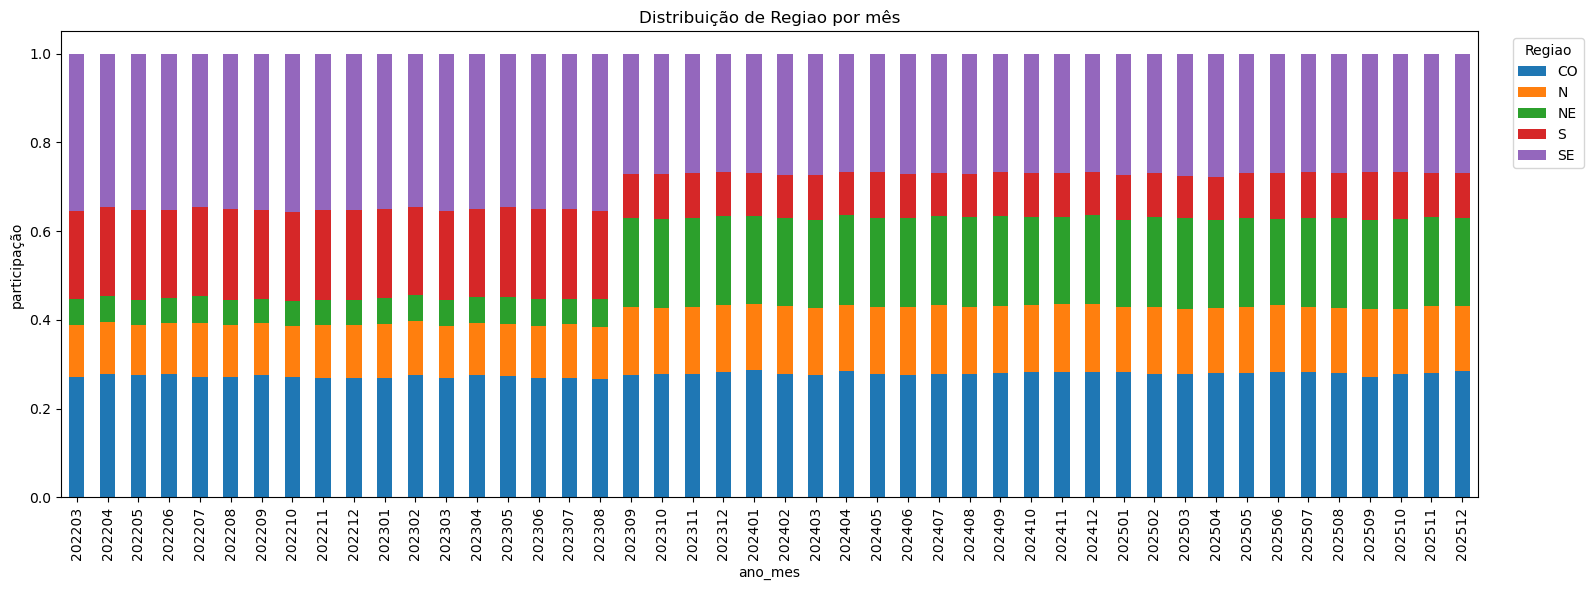

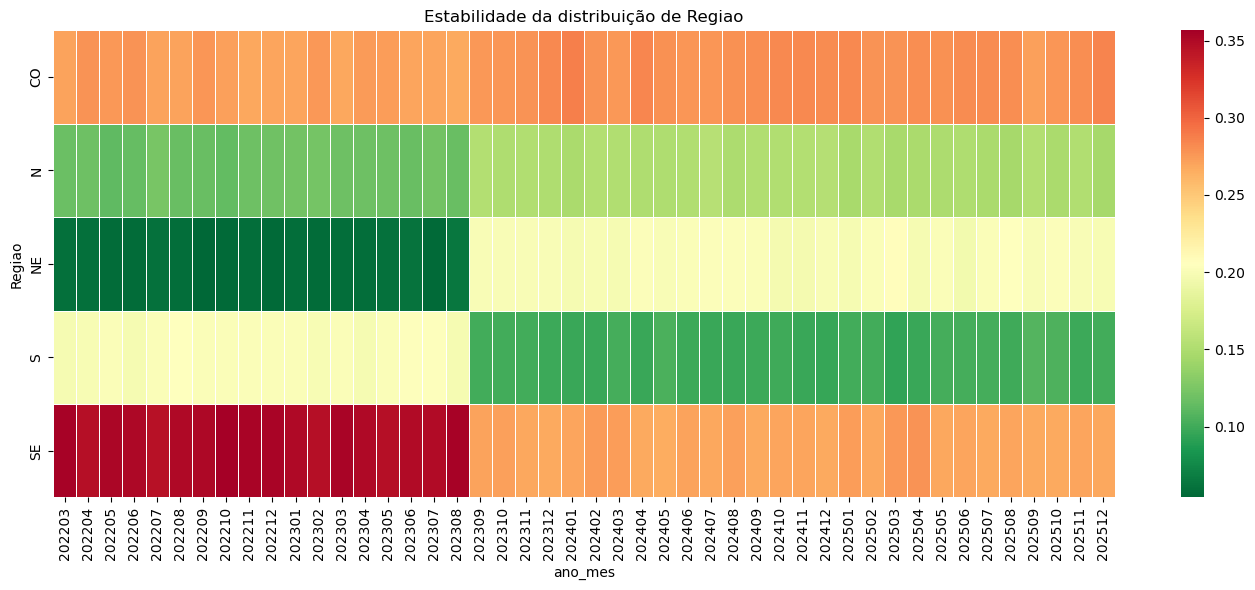

In [278]:
diag_estab(df,'Regiao')

Crescimento da região N e NE a partir de set/23, com diminuição da participação de S, SE e aparente estabilidade de CO (inclusive com alta participação entre as regiões). Mudança ocorreu exatamente no mesmo mês da queda expressiva de participação das marcas Jac e Nissan

In [279]:
pd.crosstab(df['marca'],df['Regiao'])

Regiao,CO,N,NE,S,SE
marca,,,,,
Chevrolet,18604,9412,9367,9685,20373
Fiat,37378,18241,18809,19146,40740
Ford,27902,13922,14146,14386,30821
Honda,22870,11461,11790,11978,25748
Hyundai,13058,6419,6465,6515,14286
Jac,2068,909,475,1409,2603
Nissan,2077,919,498,1402,2635
Outros,41086,20299,22064,20221,44024
Peugeot,13988,6954,7096,7063,15403


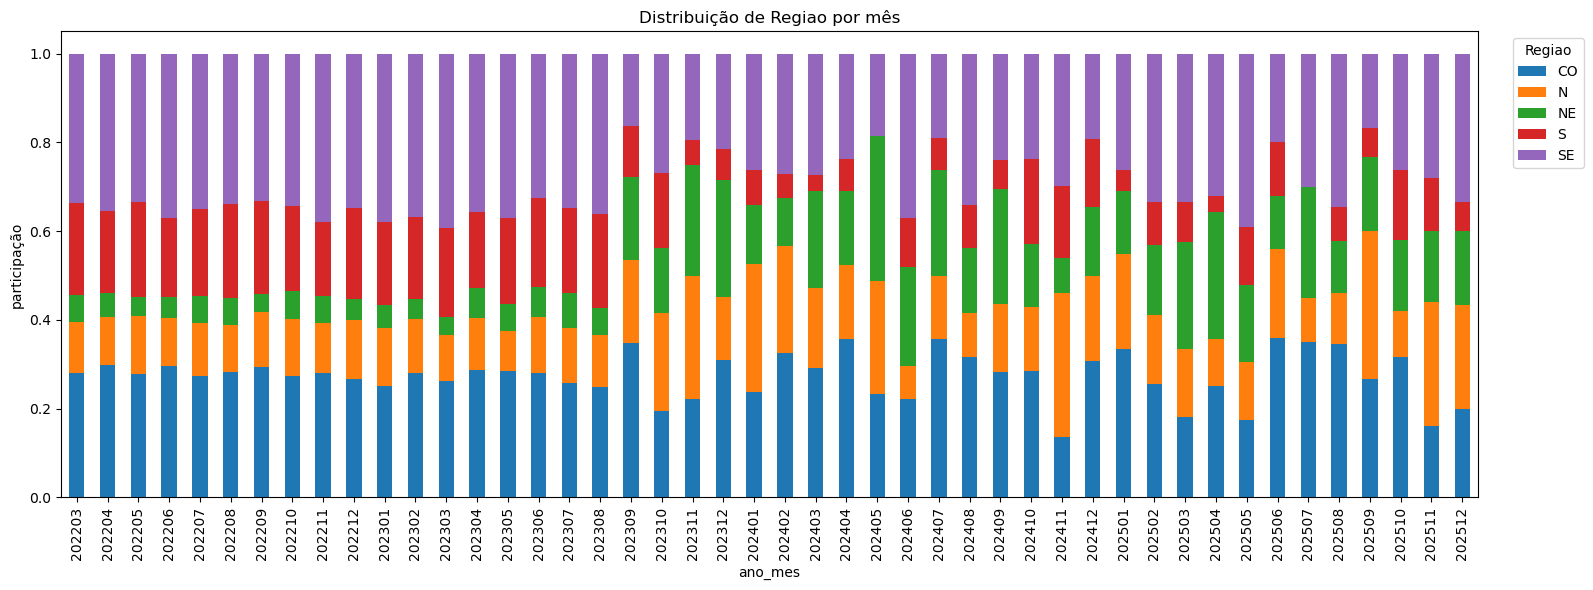

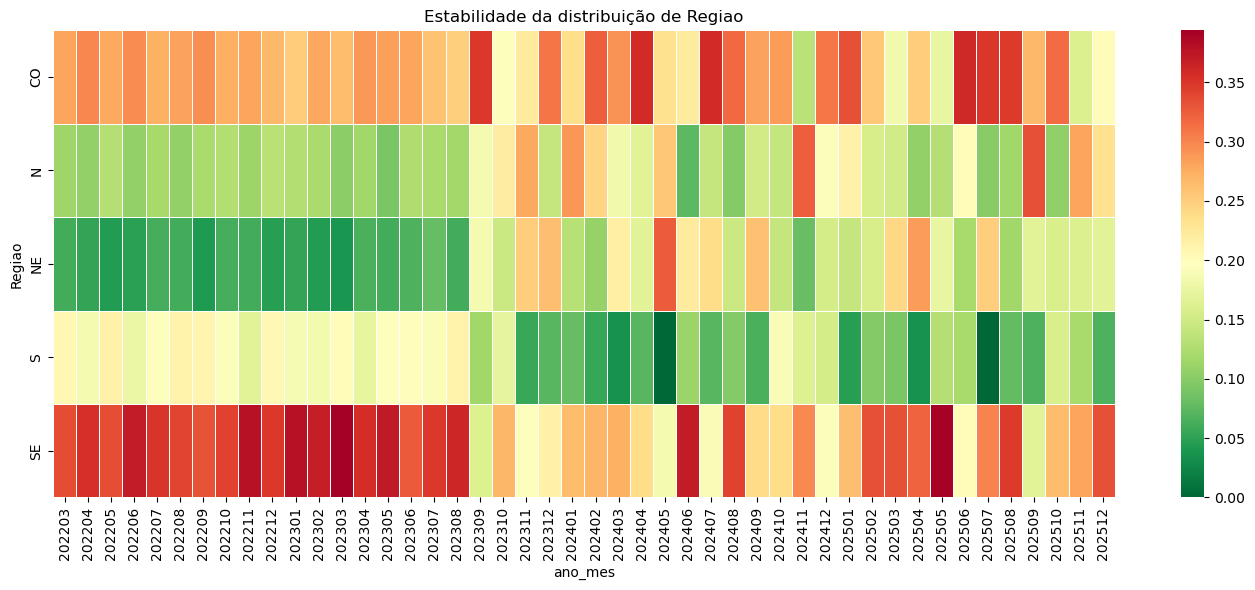

In [36]:
df_peq_marcas = df[df['marca'].isin(['Jac','Nissan'])]
diag_estab(df_peq_marcas,'Regiao')

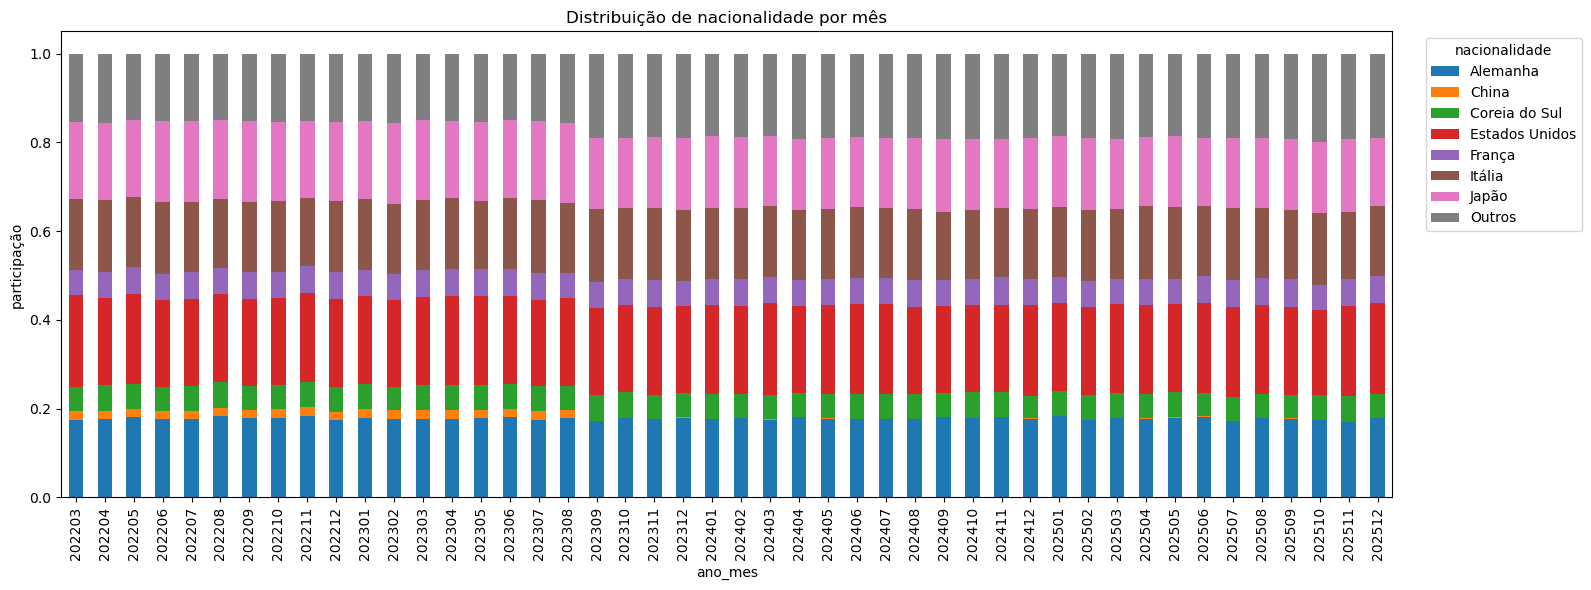

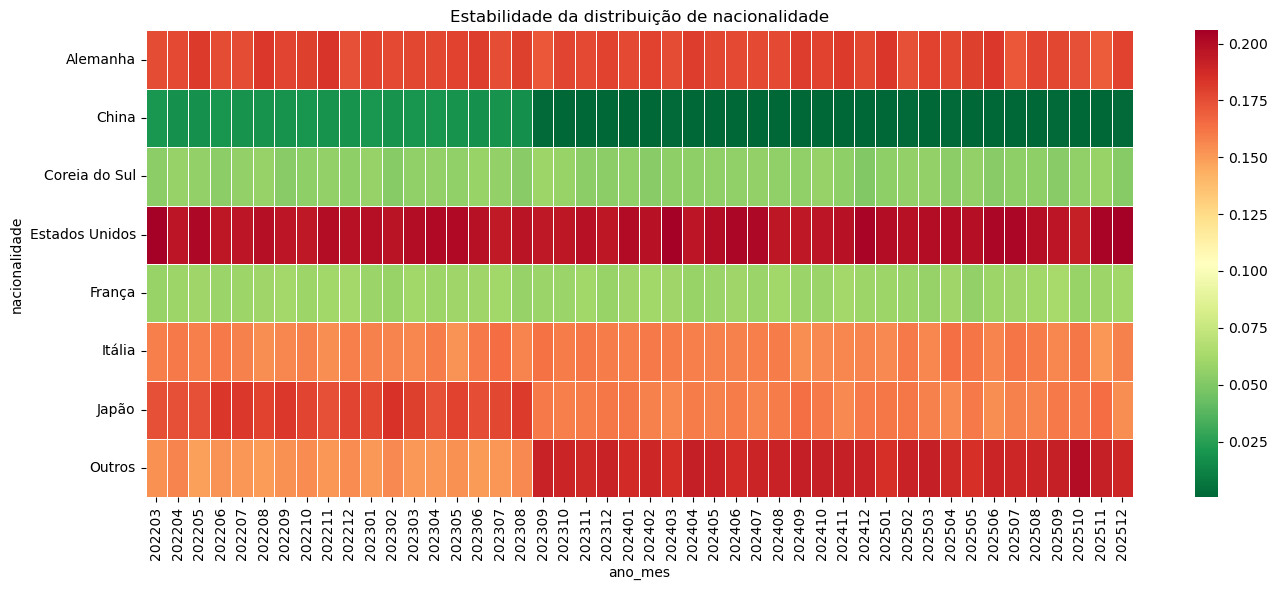

In [280]:
diag_estab(df,'nacionalidade')

Havia um distribuição entre as regiões parecida com as demais marcas. Aparentemente, só essas marcas não conseguiriam mudar a distribuição entre as regiões. Mas ficar com essa questão no radar

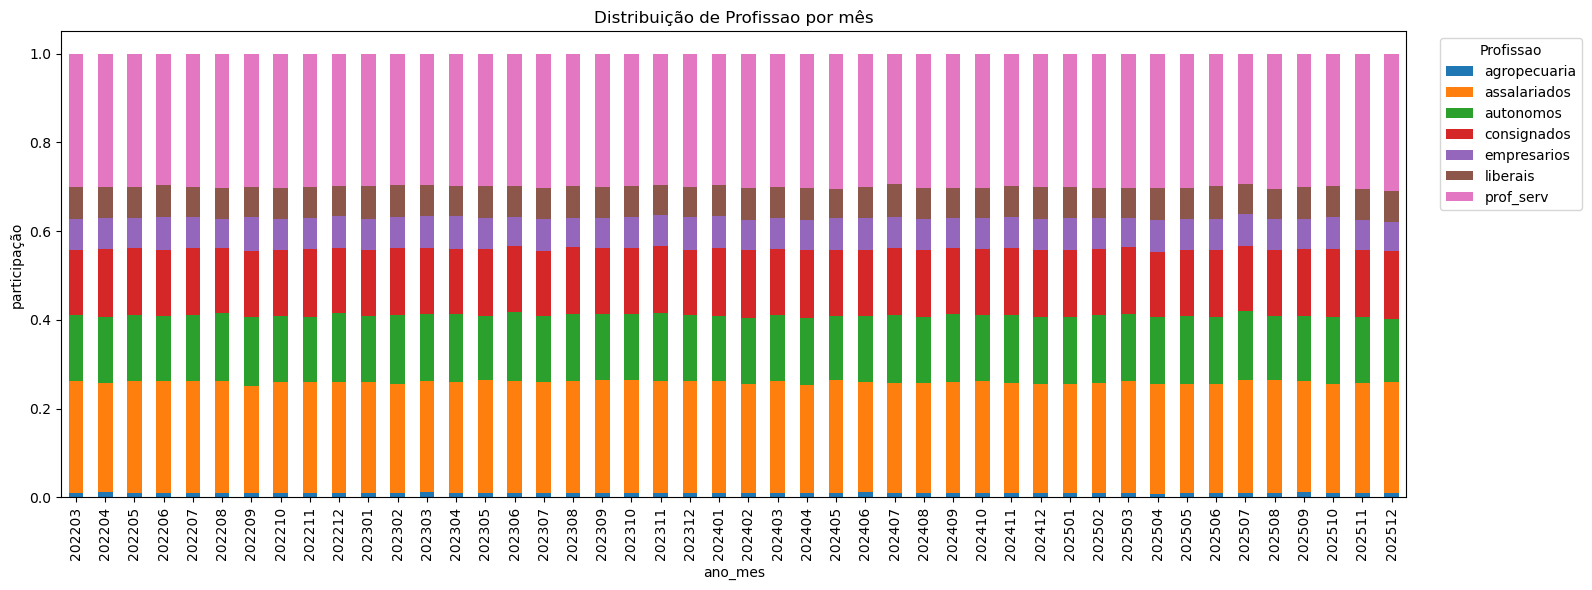

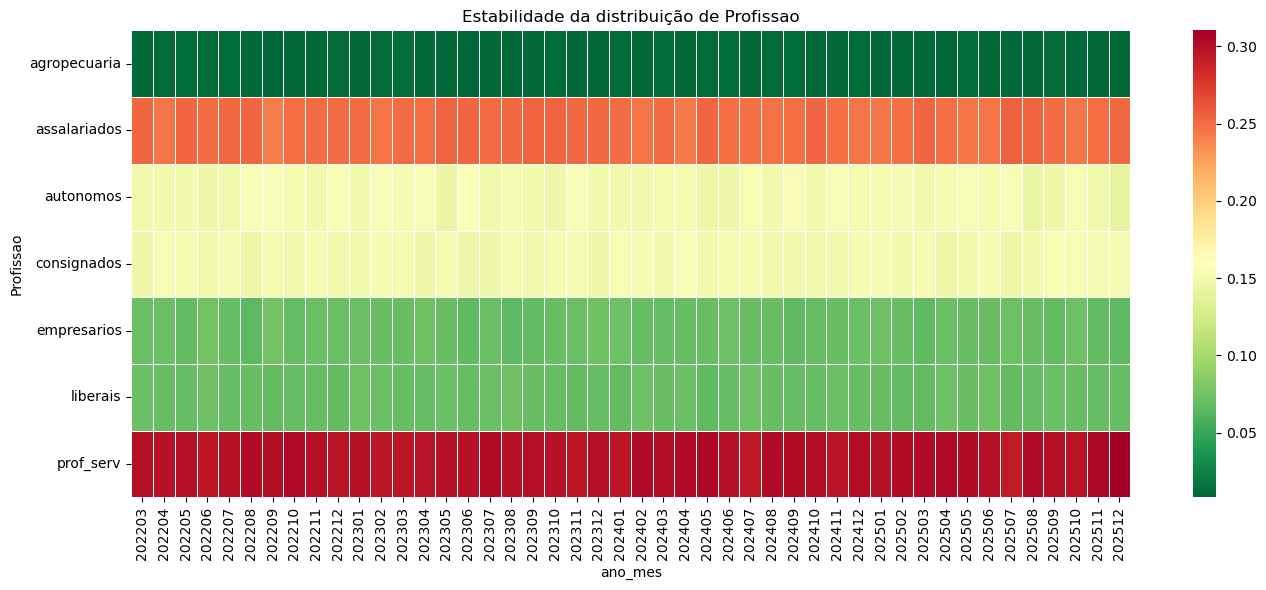

In [281]:
diag_estab(df, 'Profissao')

estabilidade entre as profissões

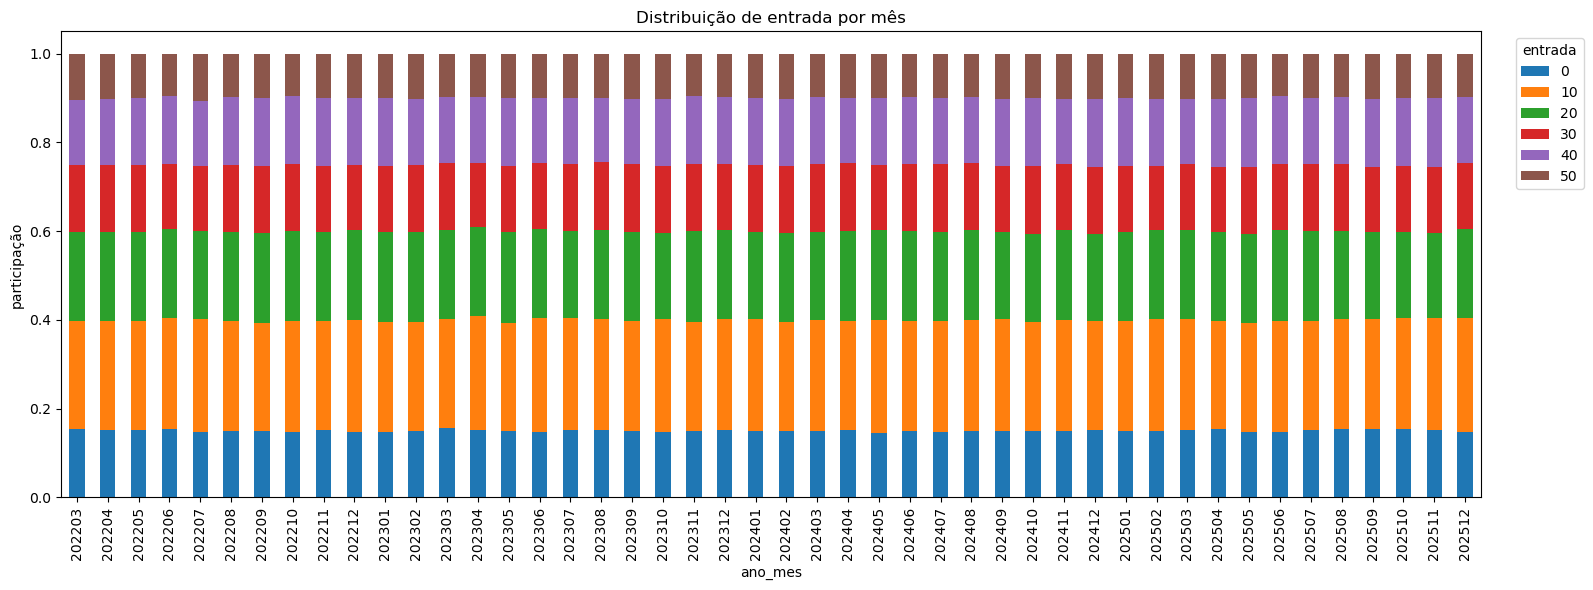

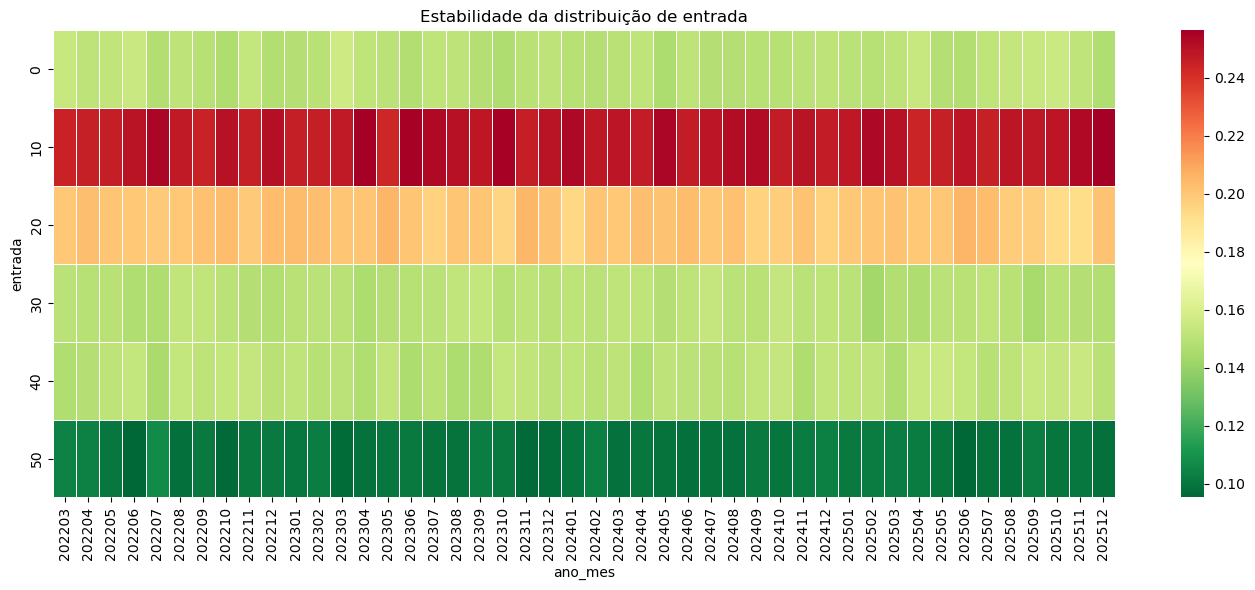

In [39]:
diag_estab(df,'entrada')

aparente estabilidade entre os percentuais de entrada

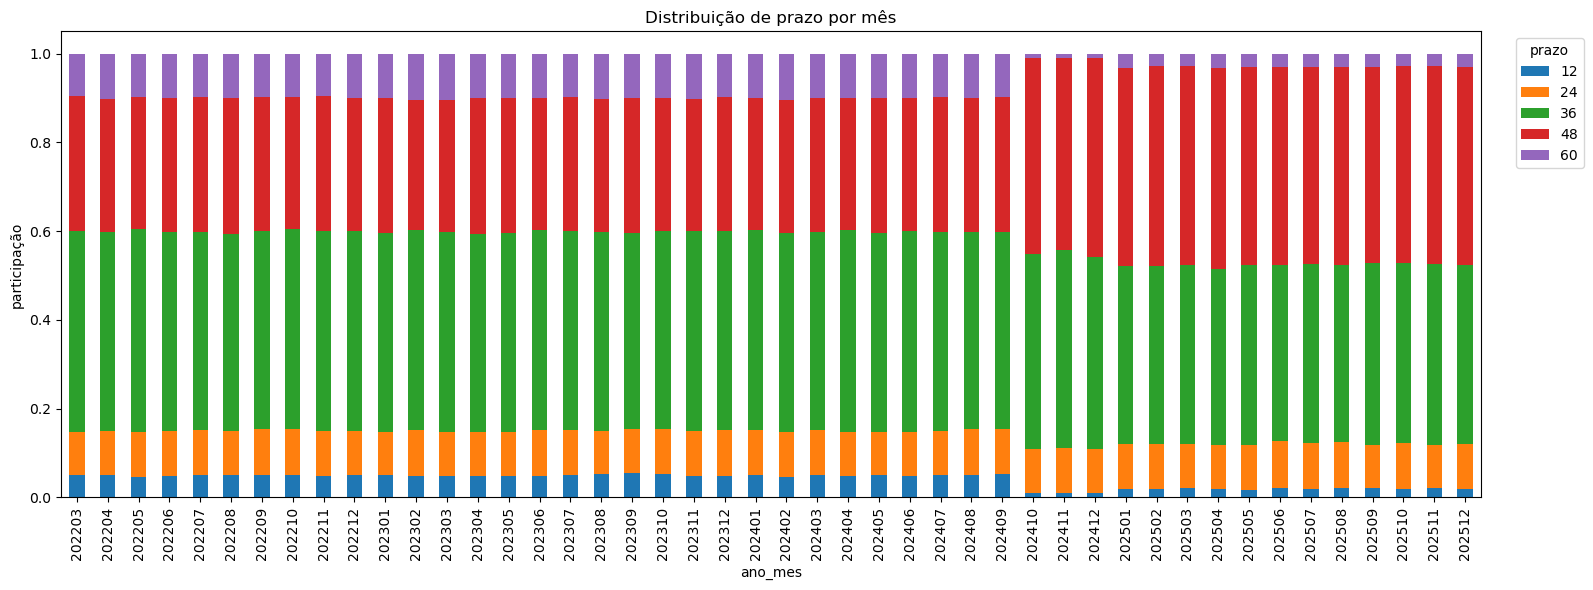

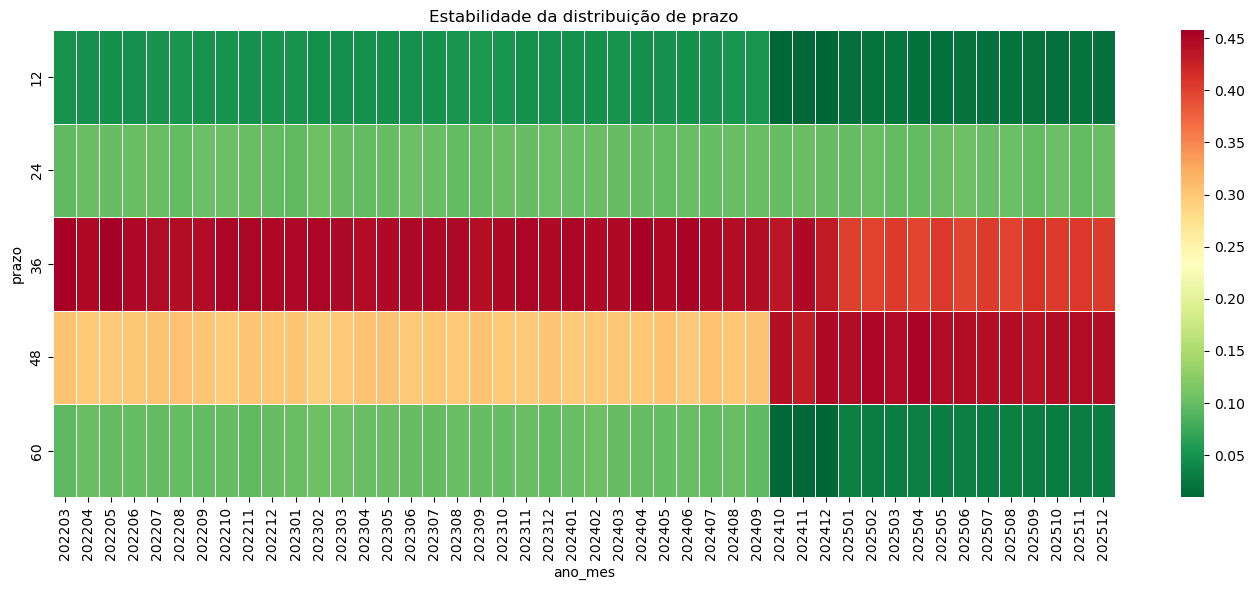

In [40]:
diag_estab(df,'prazo')

Mudança de perfil da distribuição dos prazos a partir de out/24. Queda expressiva na modalidade 12 meses e aumento considerável em 48 meses

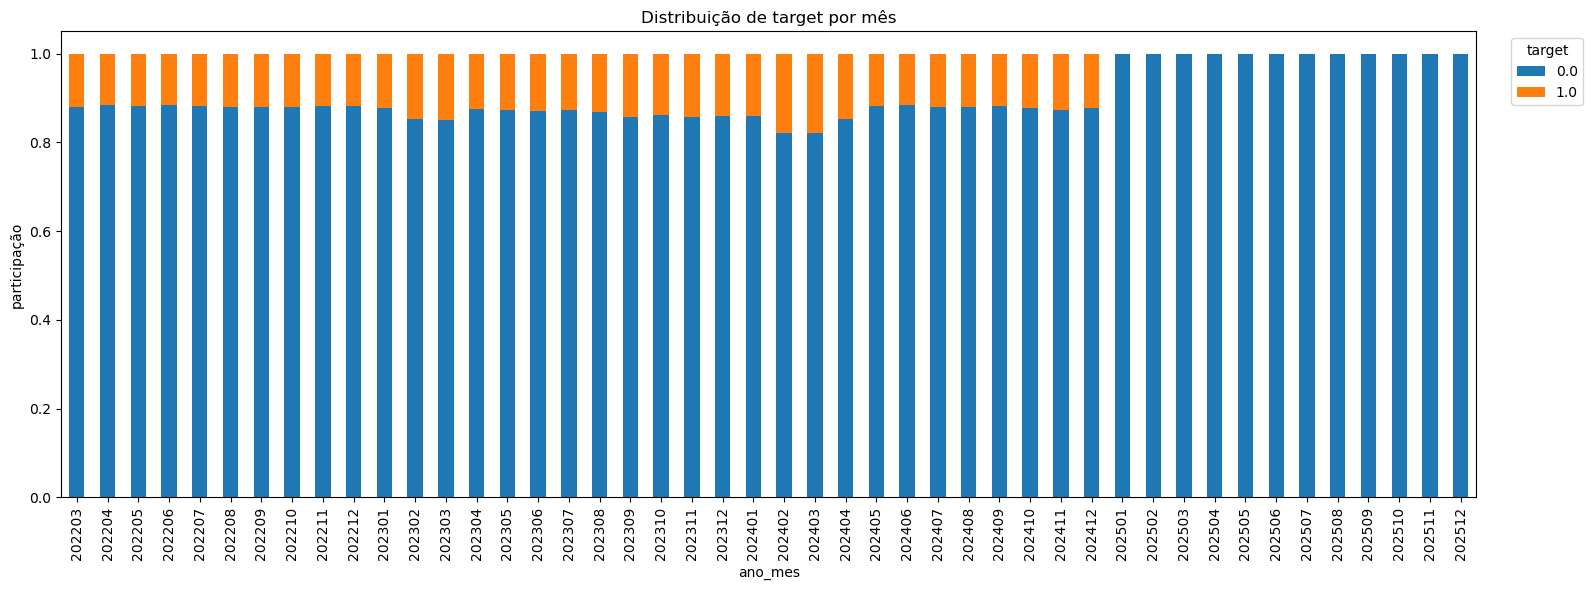

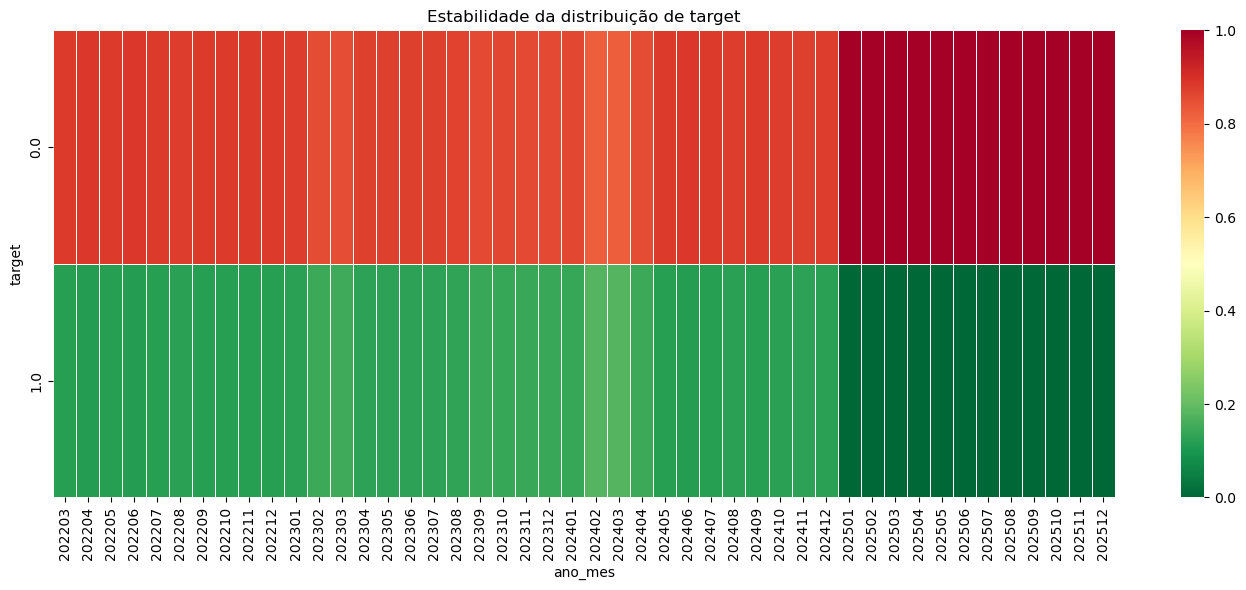

In [41]:
diag_estab(df,'target')

**Alerta Easter Egg 2**

> Não observa-se mais target = 1 a partir de jan/25. Como leva-se 12 meses para fazer a medição e dados foram disponibilizados até dez/25, não temos o comportamento de target nesse período

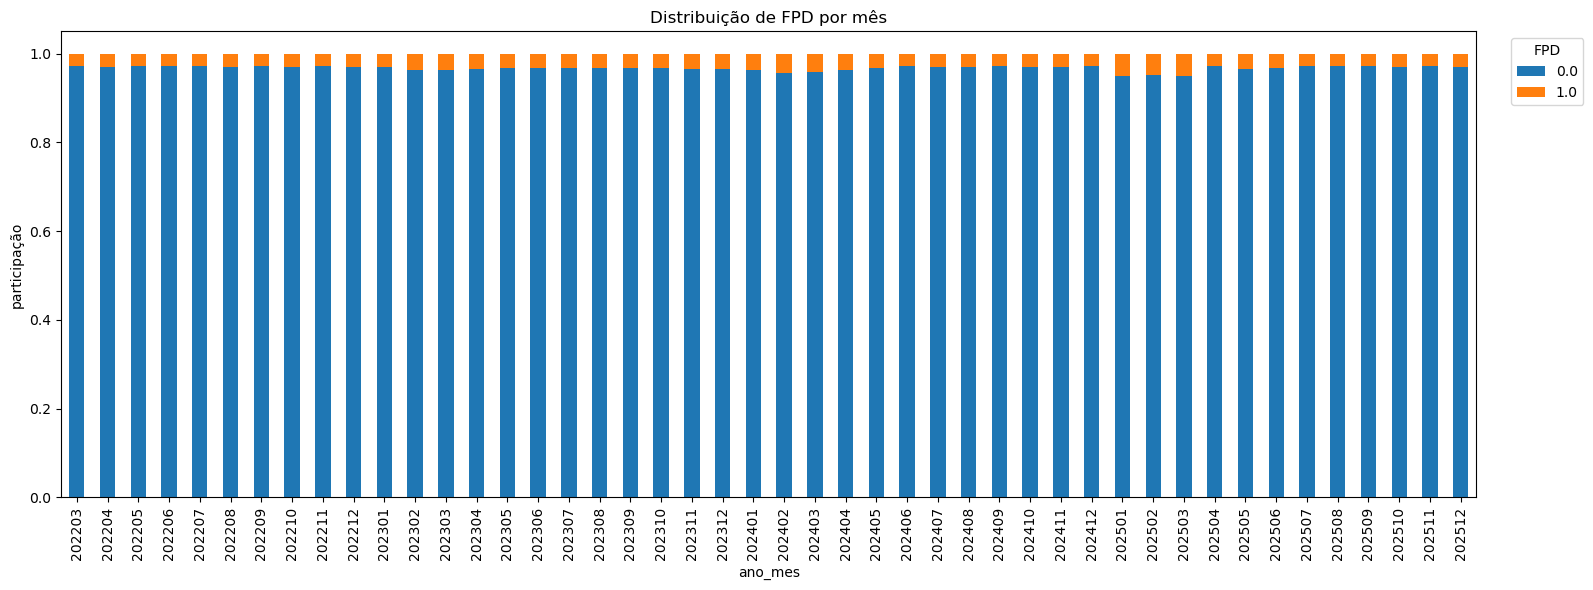

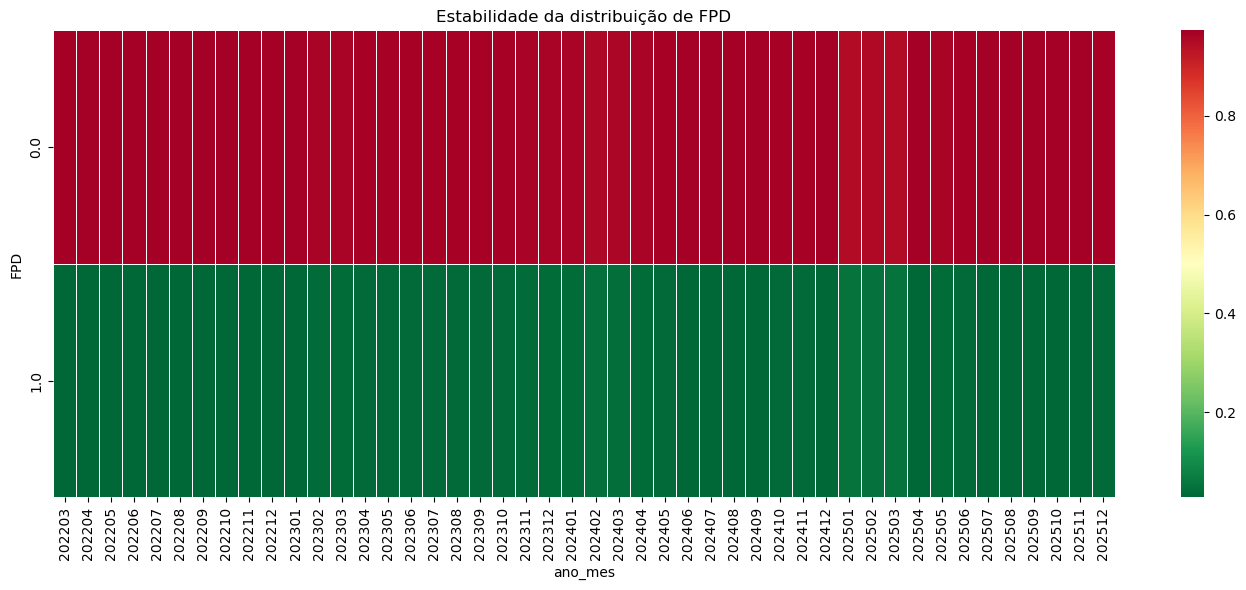

In [282]:
diag_estab(df,'FPD')

FPD praticamente estável, com leve aumento entre jan/25 a  mar/25. Avaliar em conjunto com a target

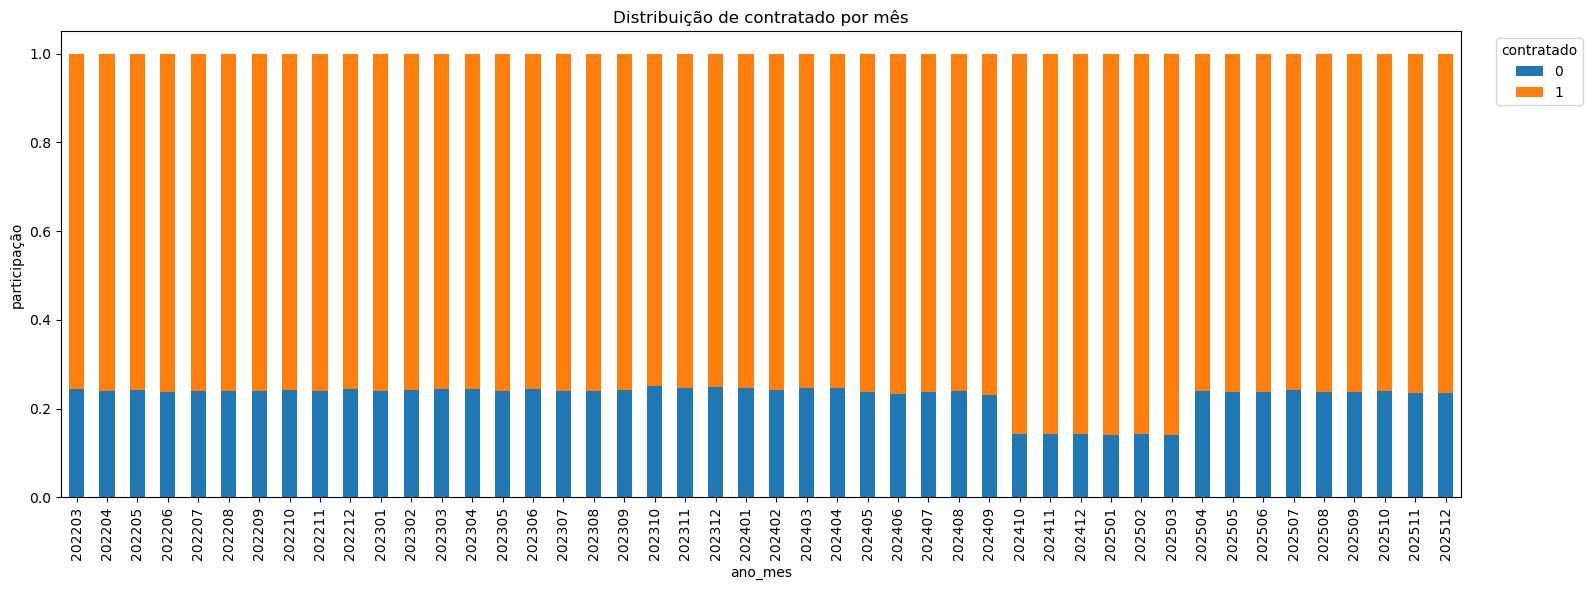

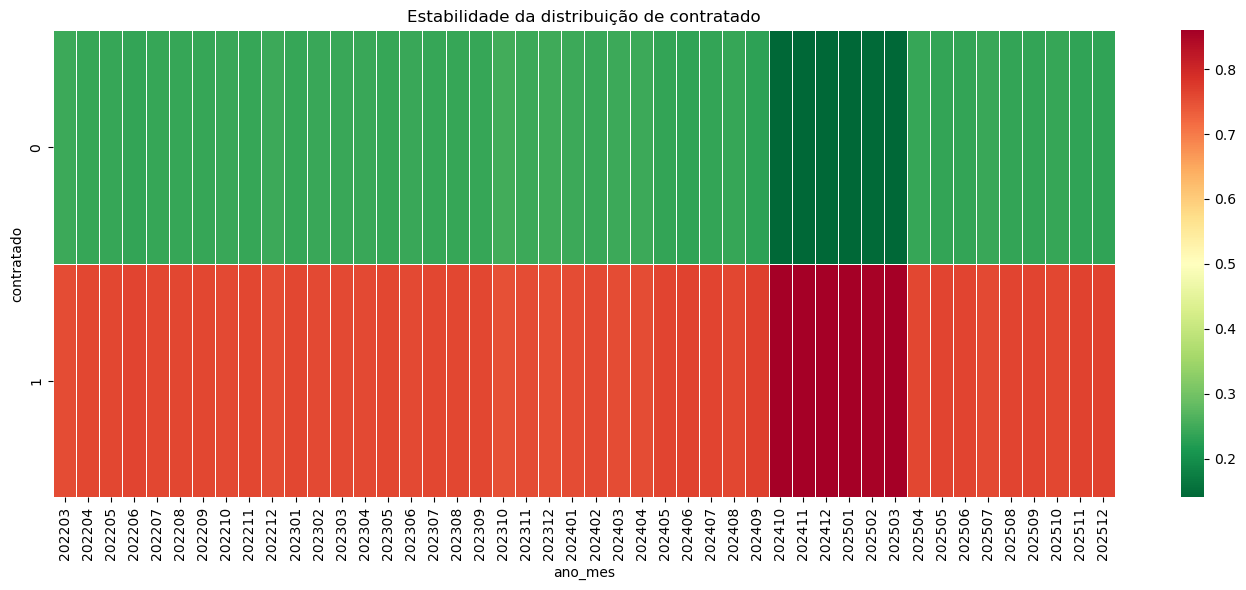

In [283]:
diag_estab(df,'contratado')

aumento das contratações a partir de out/24, provavelmente relacionada à queda na marcação das restrições nesse período. É provável que essa variável seja muito relevante no modelo

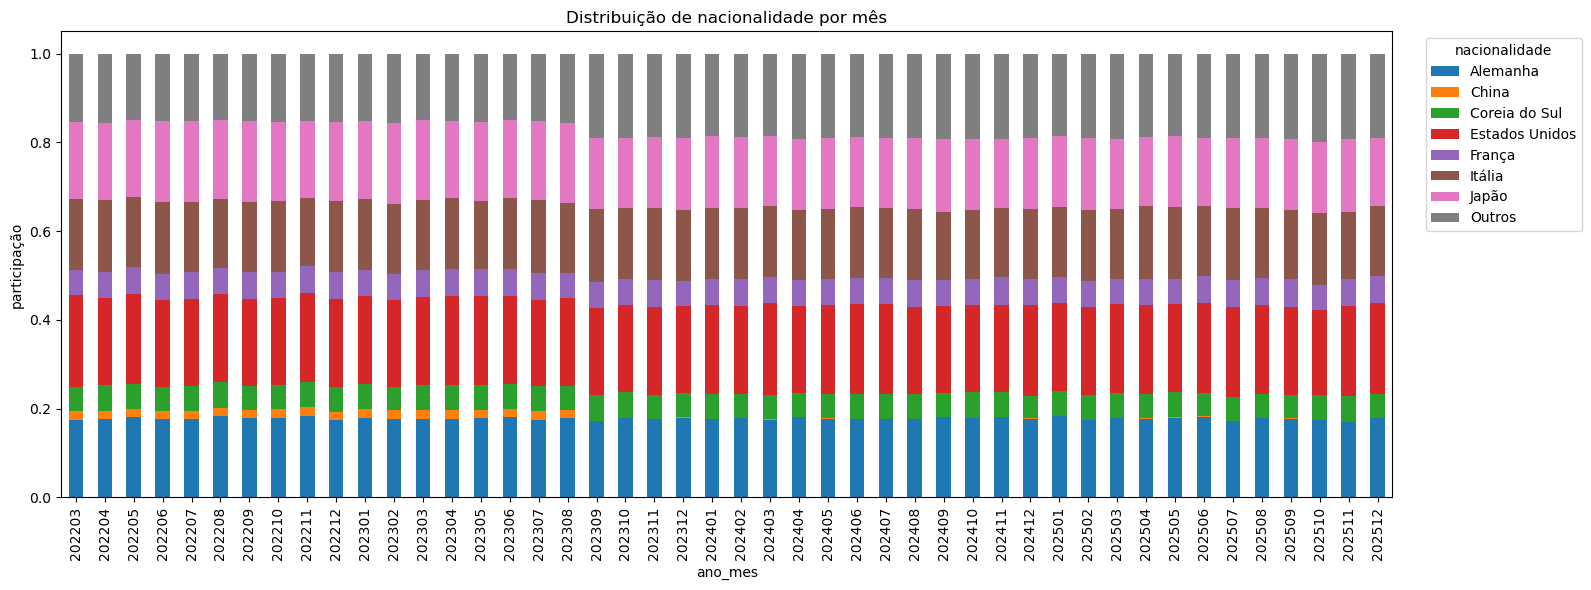

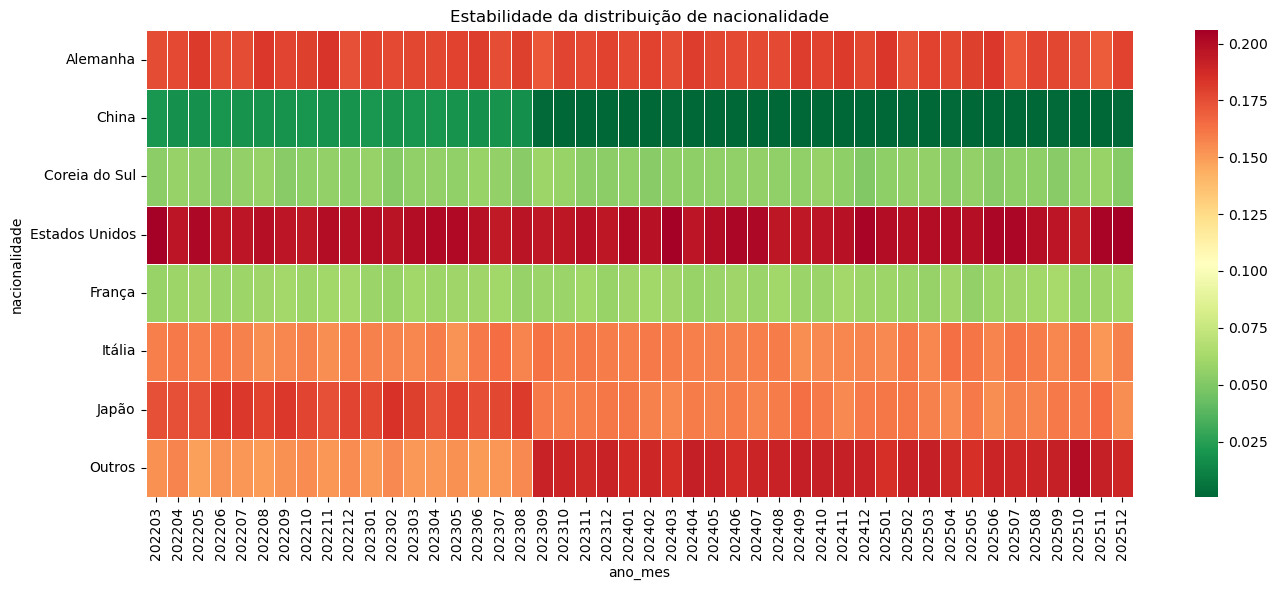

nacionalidade dos veículos aparentemente estável

#### Avaliar estabilidade das variáveis numéricas

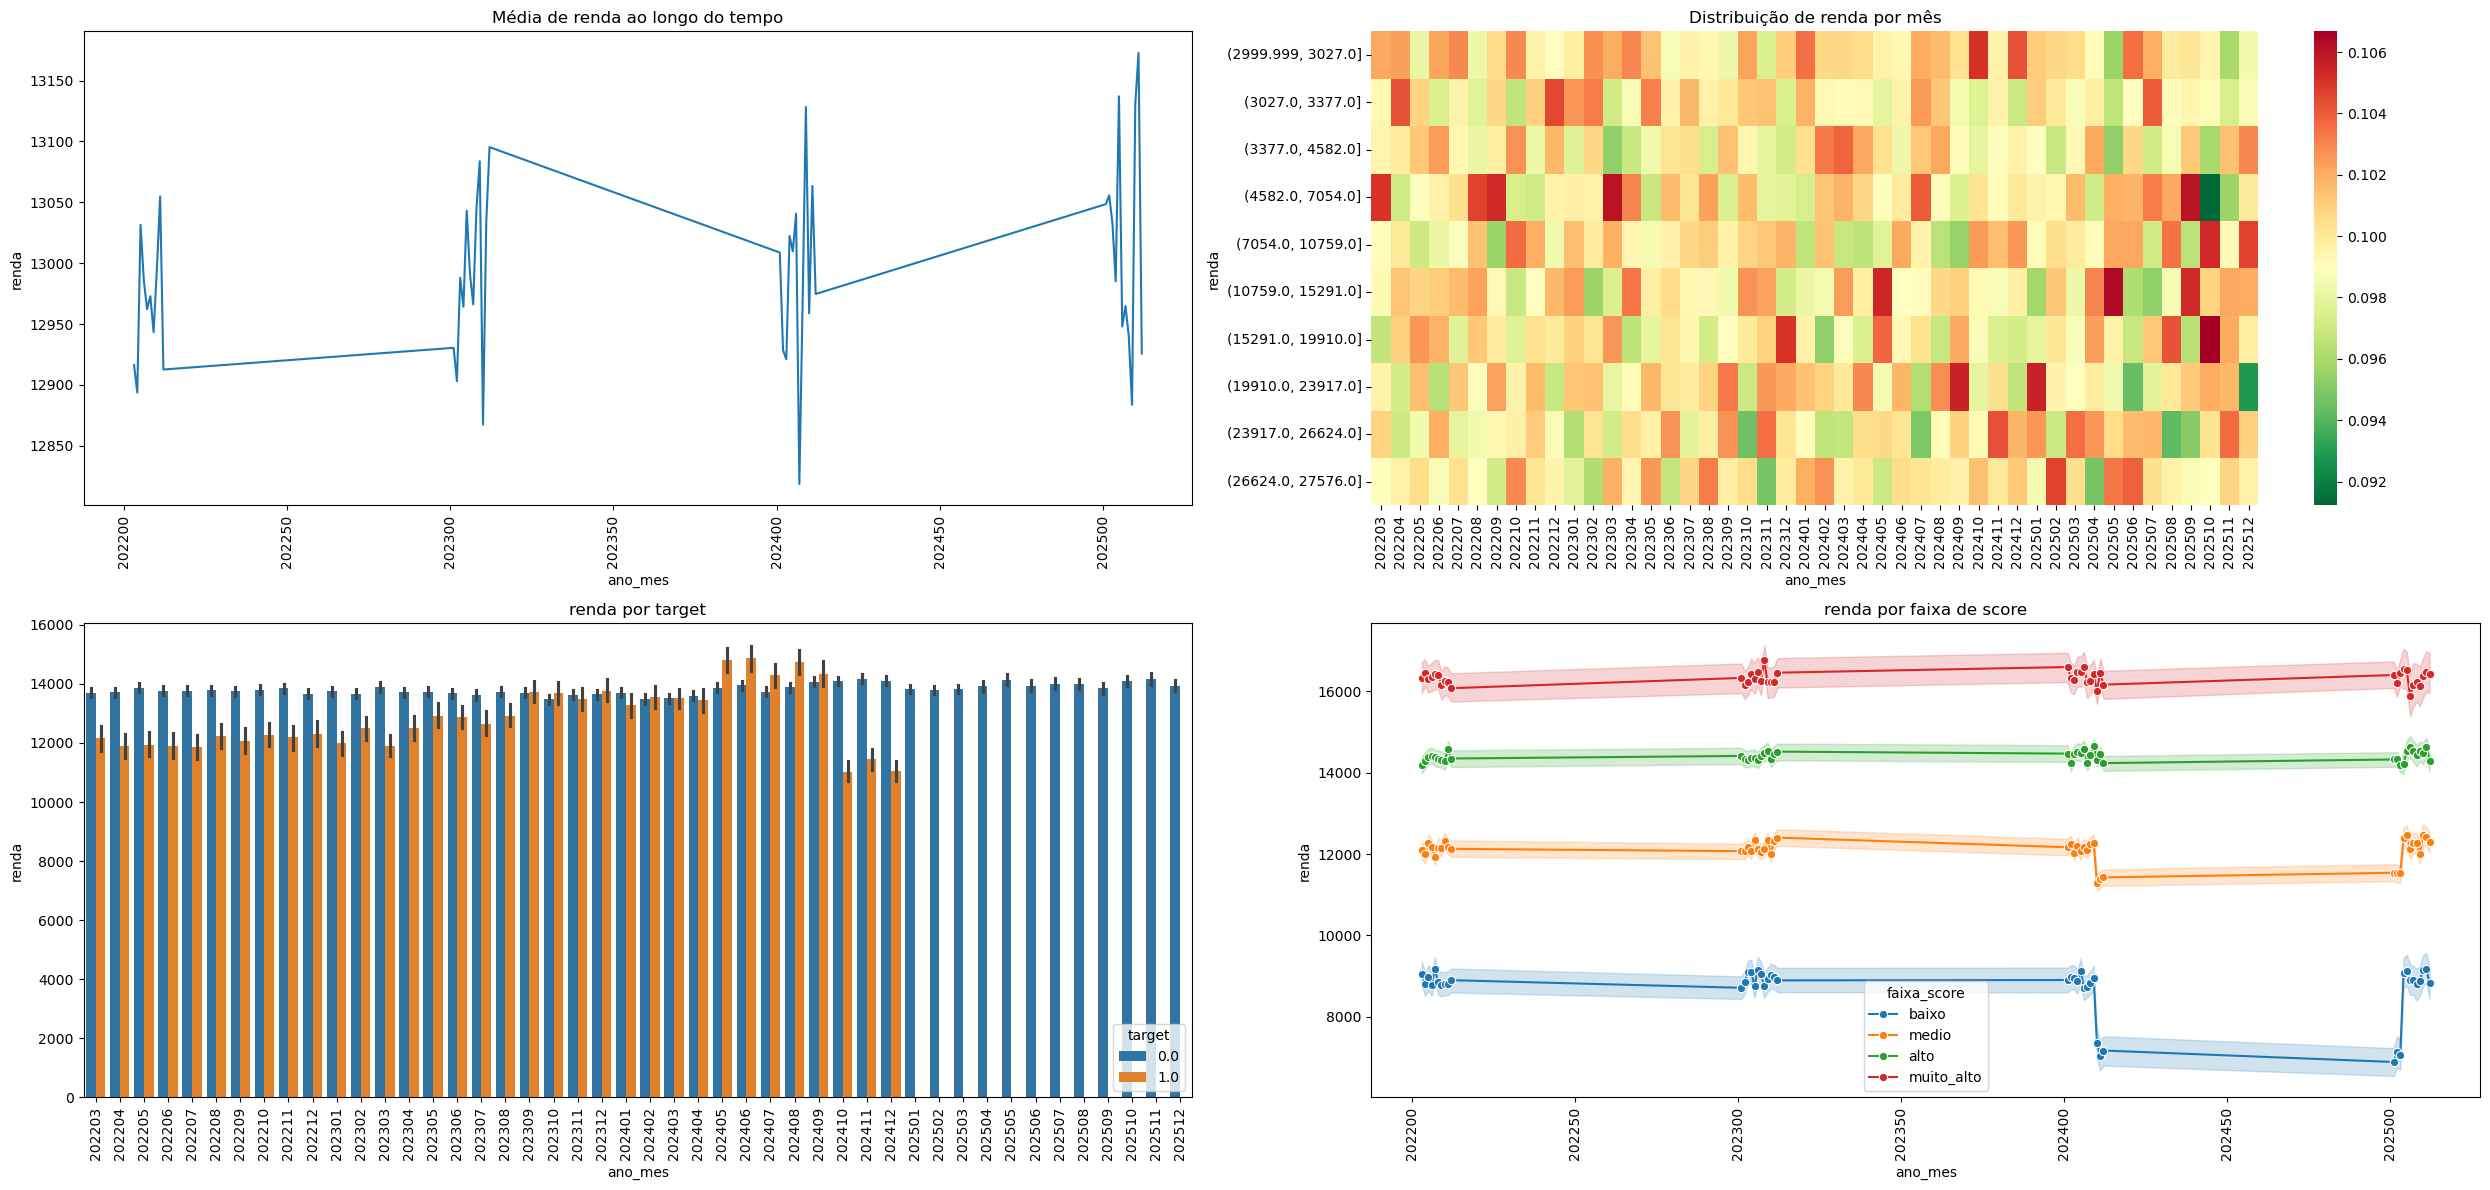

In [55]:
def diag_variavel(var, score='score', target='target'):

    df_plot = df.copy()

    # faixas de score
    df_plot['faixa_score'] = pd.cut(
        df_plot[score],
        bins=[0,3,6,8,10],
        labels=['baixo','medio','alto','muito_alto']
    )

    fig = plt.figure(figsize=(25,12))

    # --------------------------------------------------
    # 1. média da variável ao longo do tempo
    # --------------------------------------------------

    ax1 = plt.subplot(221)

    df_plot.groupby('ano_mes')[var].mean().plot(ax=ax1)

    ax1.set_title(f"Média de {var} ao longo do tempo")
    ax1.set_ylabel(var)

    # --------------------------------------------------
    # 2. distribuição da variável por mês (heatmap)
    # --------------------------------------------------

    ax2 = plt.subplot(222)

    df_heat = pd.crosstab(
        df_plot['ano_mes'],
        pd.qcut(df_plot[var], 10, duplicates='drop'),
        normalize='index'
    )

    sns.heatmap(df_heat.T, cmap="RdYlGn_r", ax=ax2)

    ax2.set_title(f"Distribuição de {var} por mês")
    ax2.set_ylabel(var)

    # --------------------------------------------------
    # 3. média da variável por target
    # --------------------------------------------------

    ax3 = plt.subplot(223)

    sns.barplot(
        data=df_plot,
        x='ano_mes',
        y=var,
        hue=target,
        estimator='mean',
        #marker='o',
        ax=ax3
    )

    ax3.set_title(f"{var} por target")

    # --------------------------------------------------
    # 4. média da variável por score
    # --------------------------------------------------

    ax4 = plt.subplot(224)

    sns.lineplot(
        data=df_plot,
        x='ano_mes',
        y=var,
        hue='faixa_score',
        estimator='mean',
        marker='o',
        ax=ax4
    )

    ax4.set_title(f"{var} por faixa de score")

    for ax in [ax1, ax3, ax4]:
        ax.tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()

diag_variavel('renda')

Pelo gráfico 3, observa-se um fenômeno curioso. No período de treinamento (e até um pouco depois dele em 2023), a renda era menor para os clientes target. Ou seja, na média, a renda era maior em clientes não inadimplentes. A partir do final de 2023 e até set/24, as rendas médias se equiparam e chegam a inverter o comportamento, a partir de out/24 até dez/24.

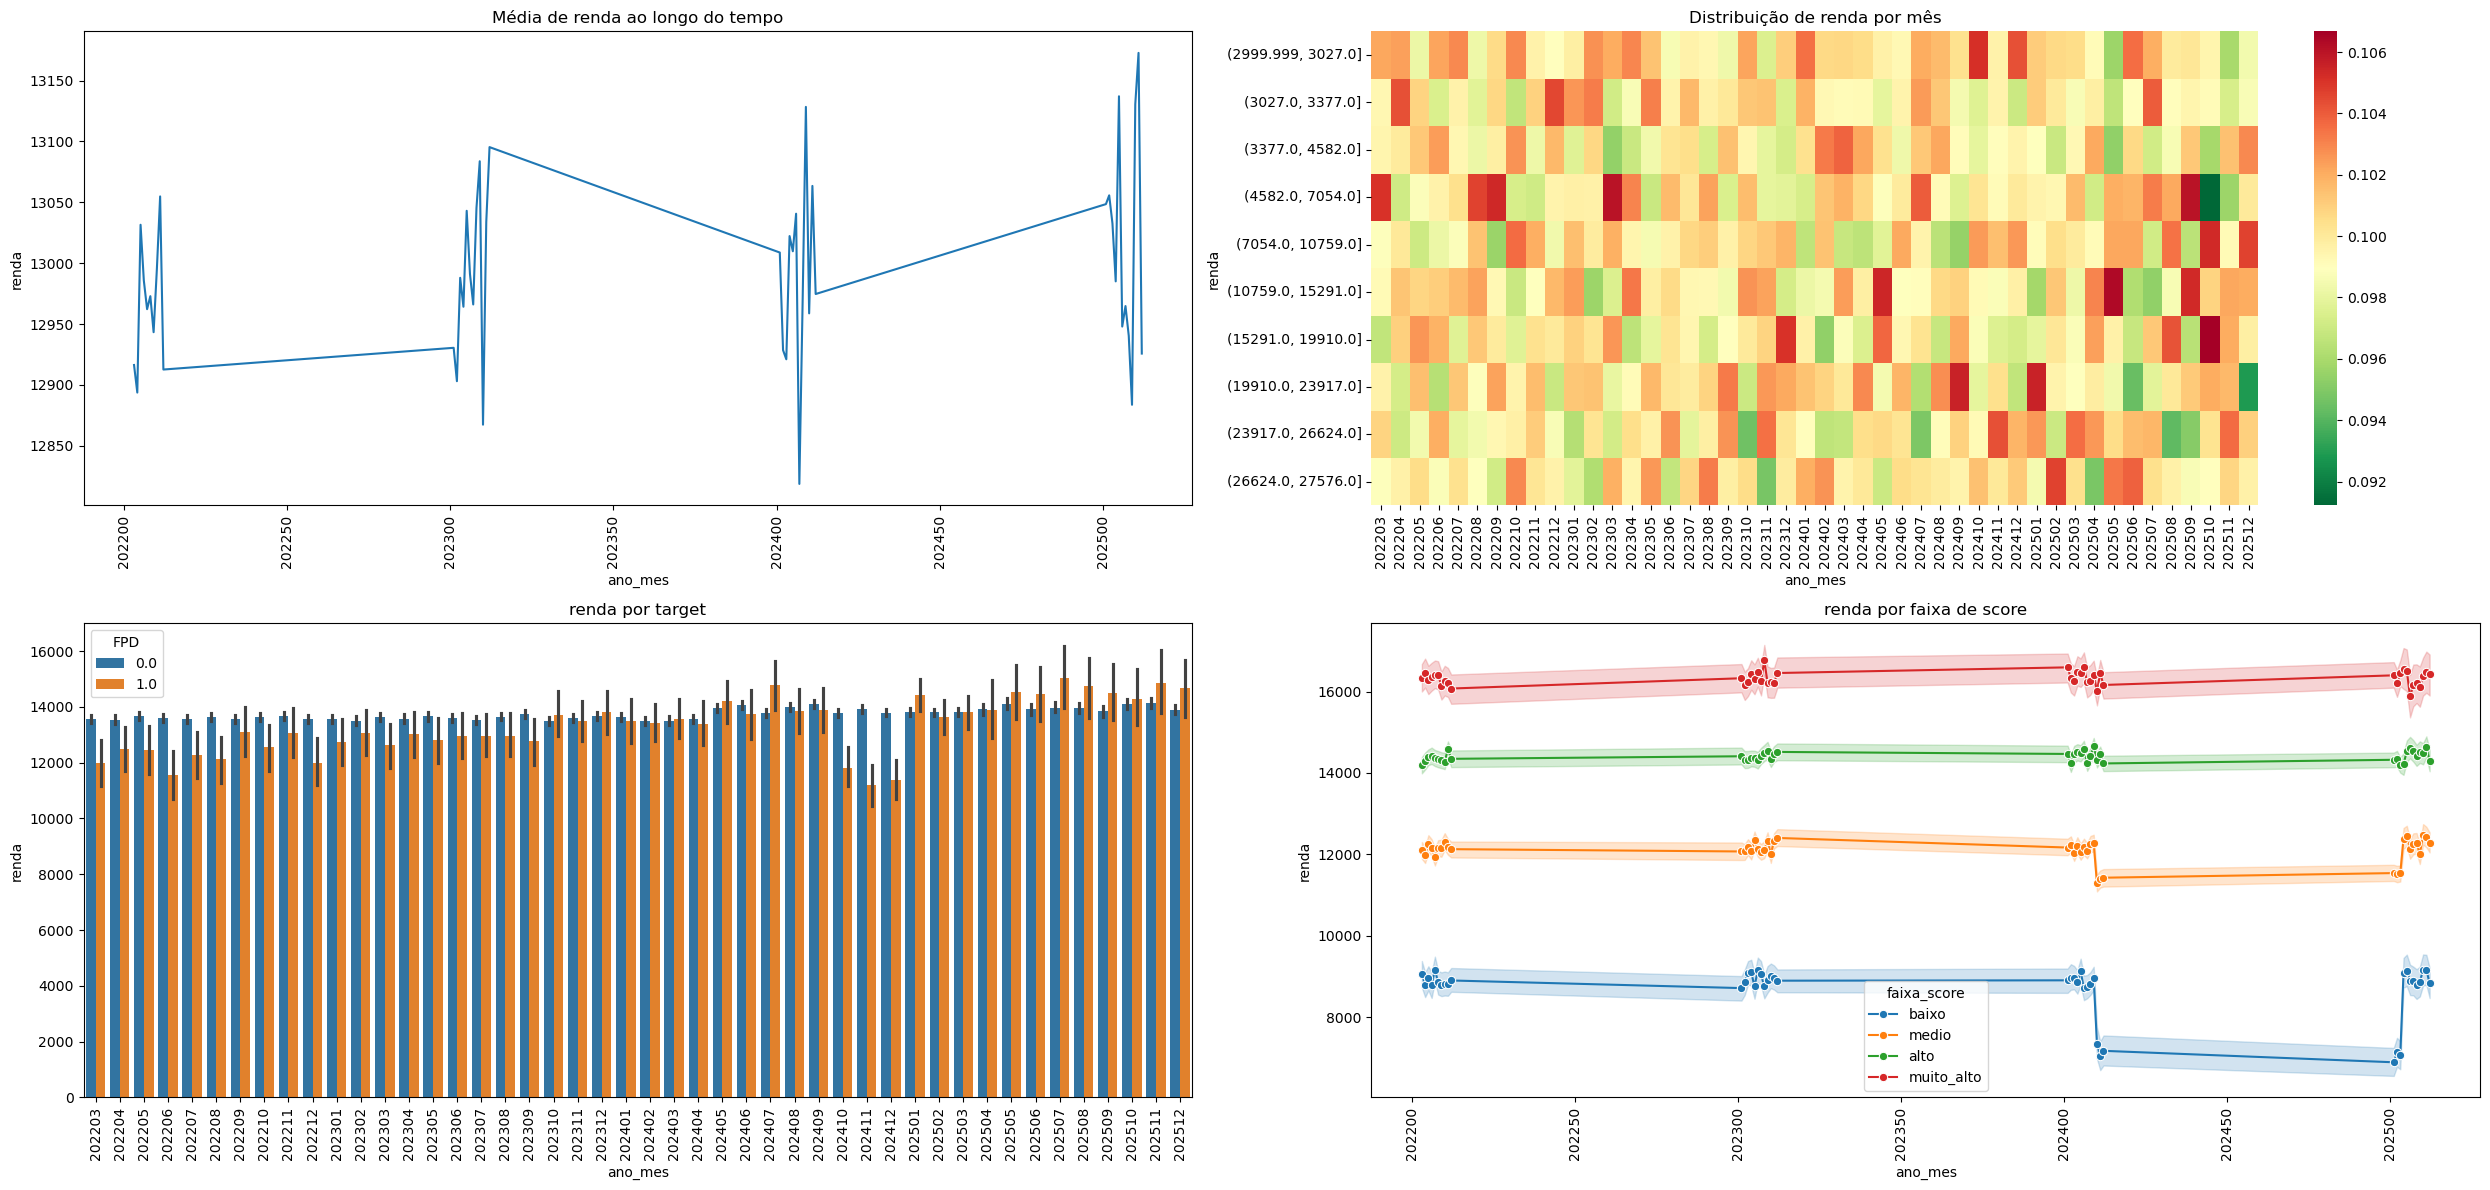

In [58]:
diag_variavel('renda', score = 'score', target = 'FPD')

Observando por FPD, que permite avaliar 2025 também, essa tendÊncia também é observada. E em 2025, em muitos meses, a renda média dos clientes que deixam de pagar a primeira parcela (FPD = 1) é levemente maior que a renda dos clientes que pagaram

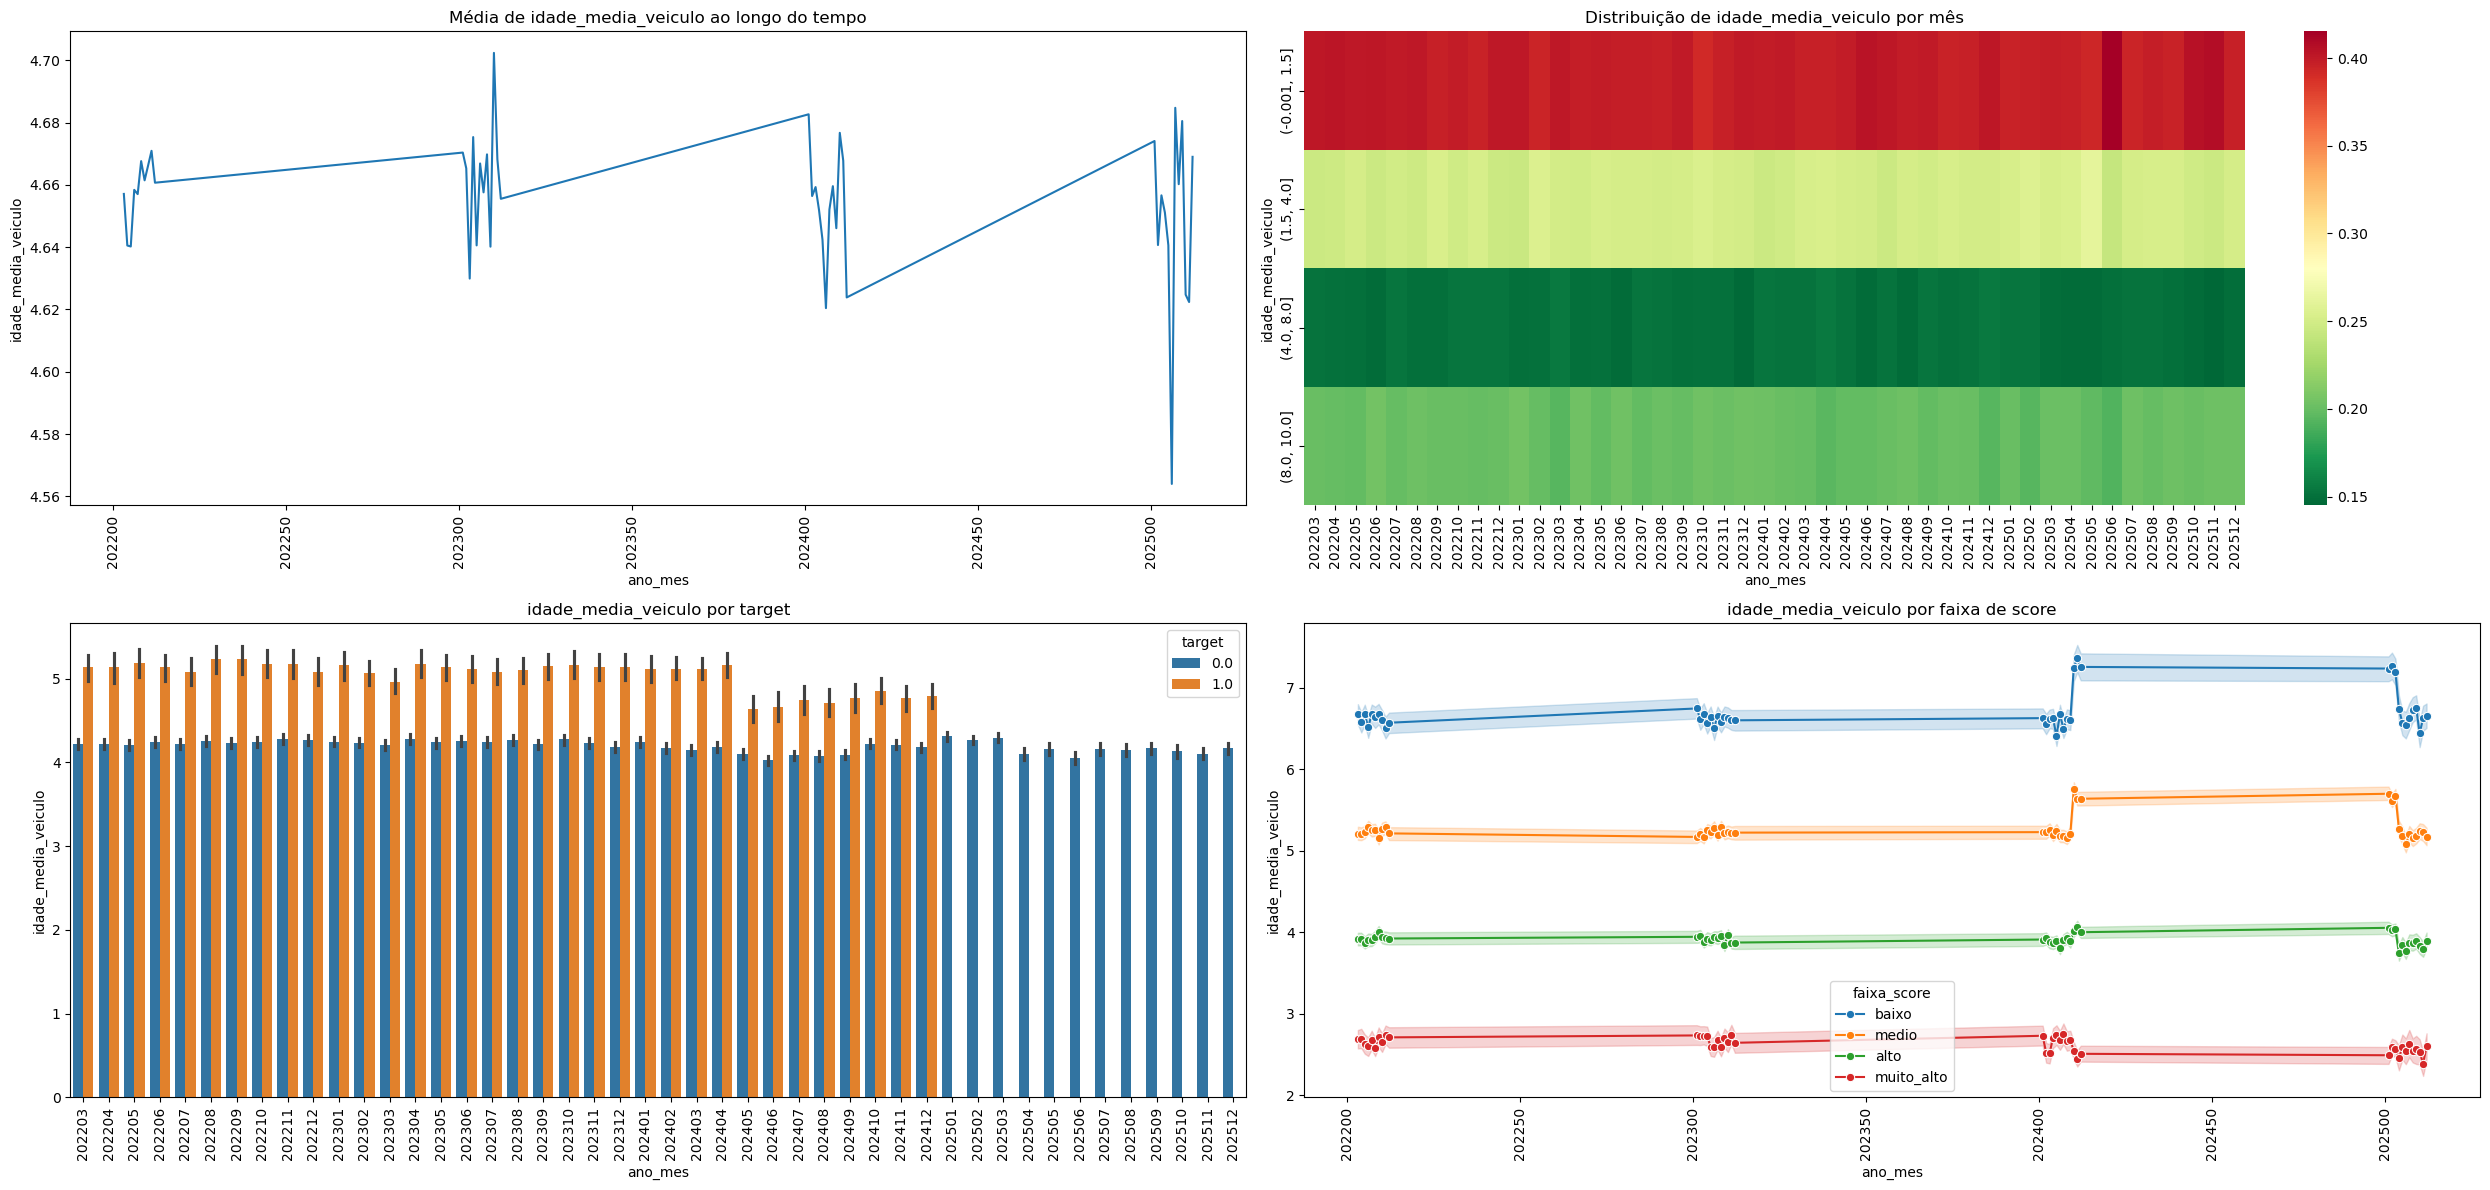

In [256]:
diag_variavel('idade_media_veiculo')

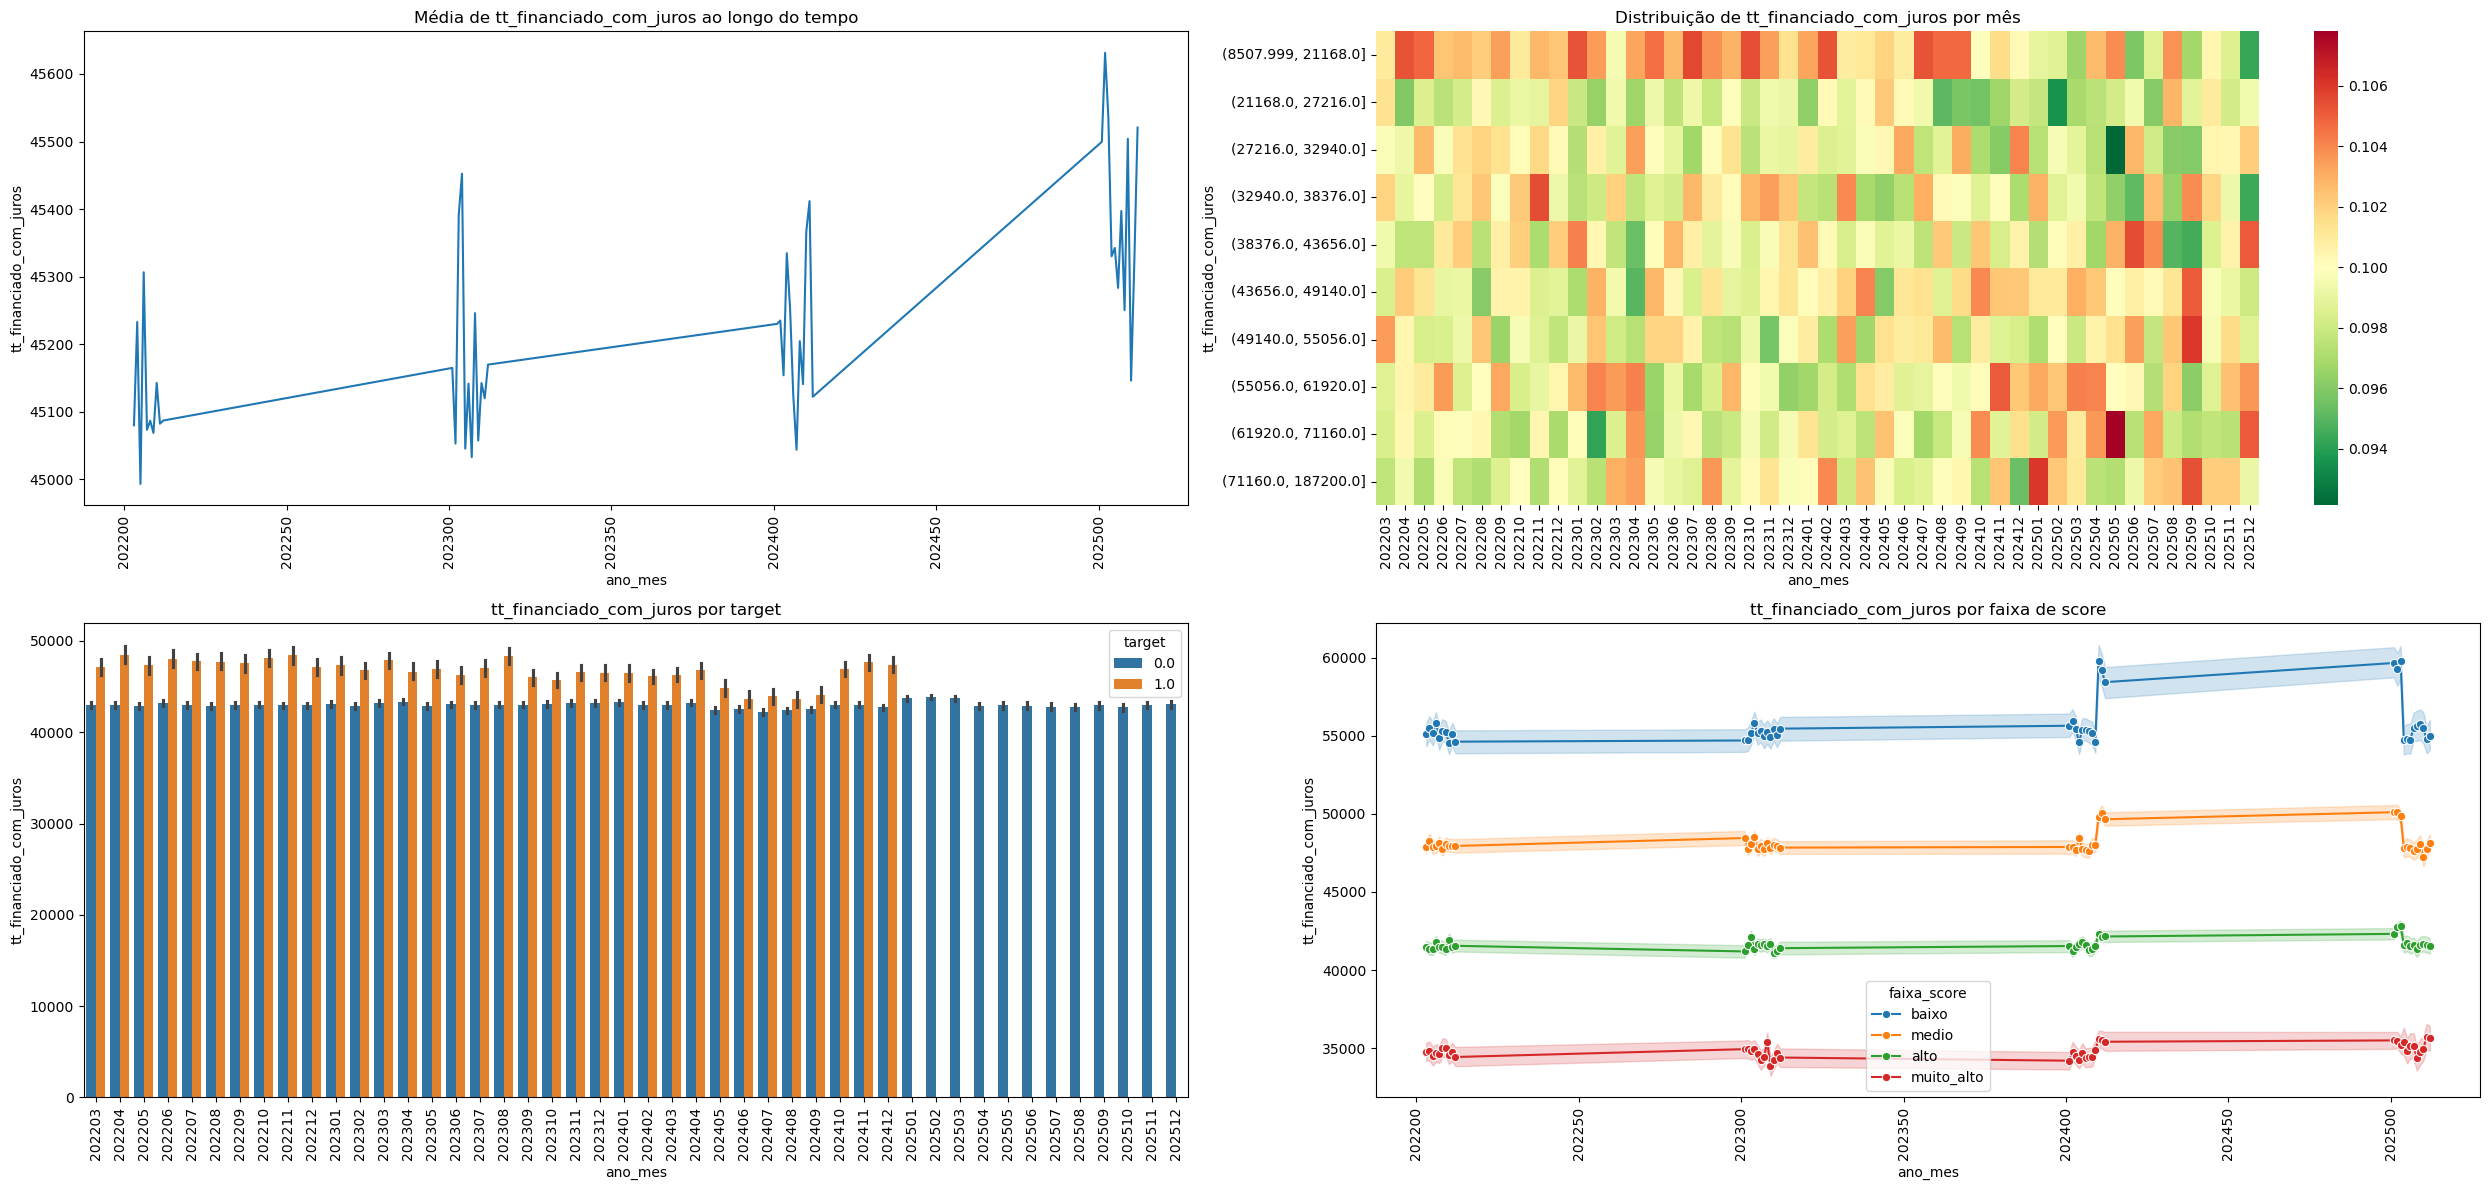

In [255]:
diag_variavel('tt_financiado_com_juros')

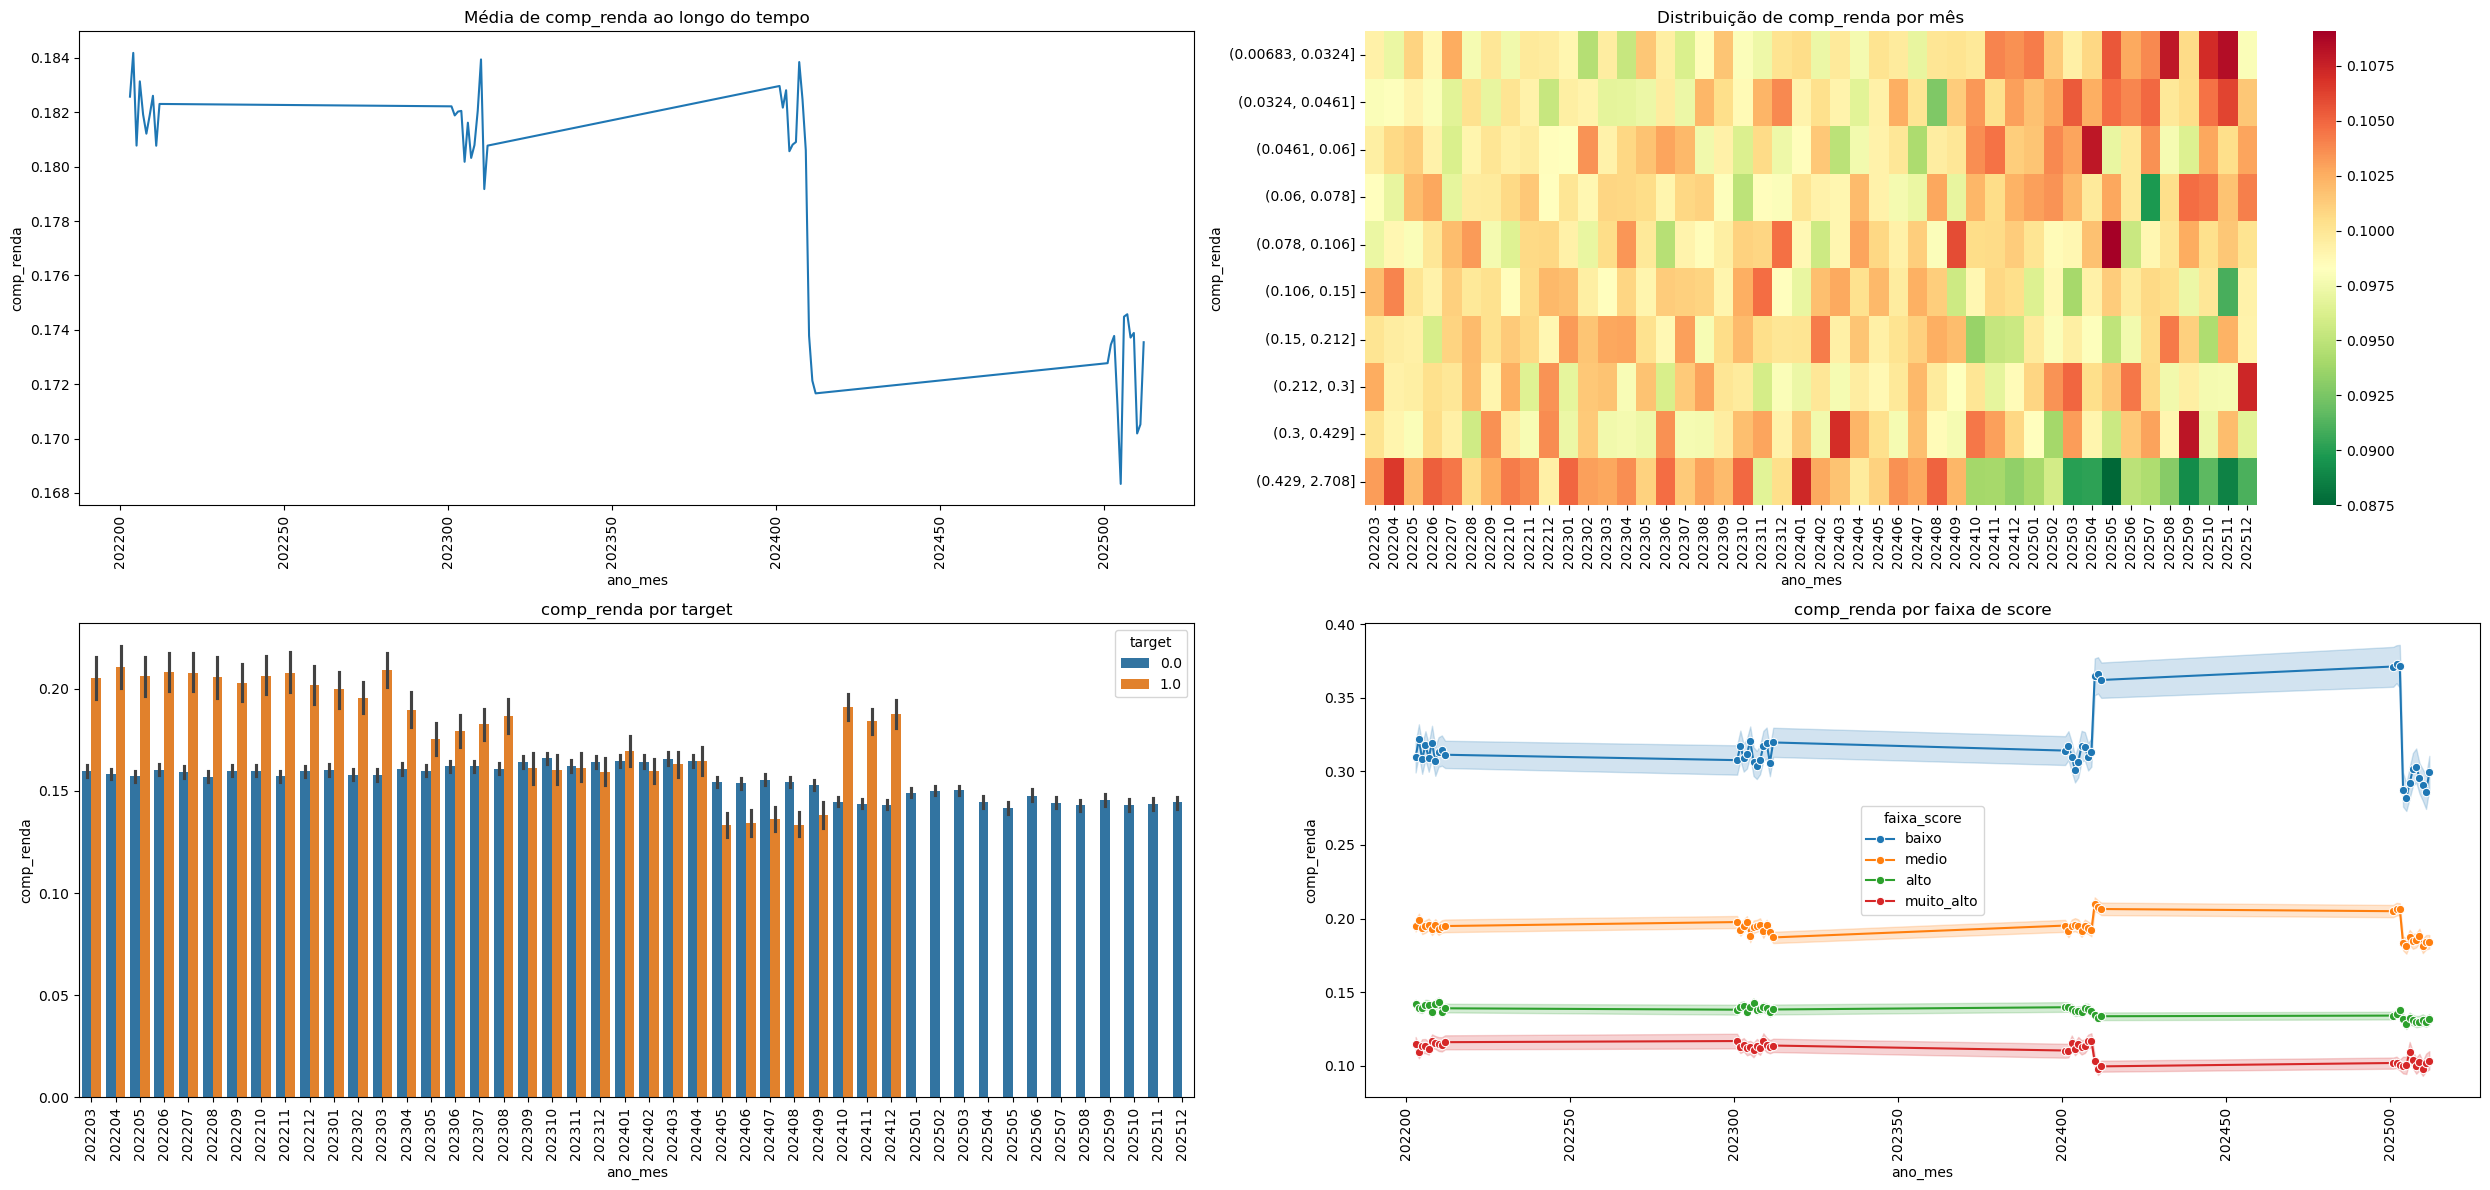

In [234]:
diag_variavel('comp_renda')

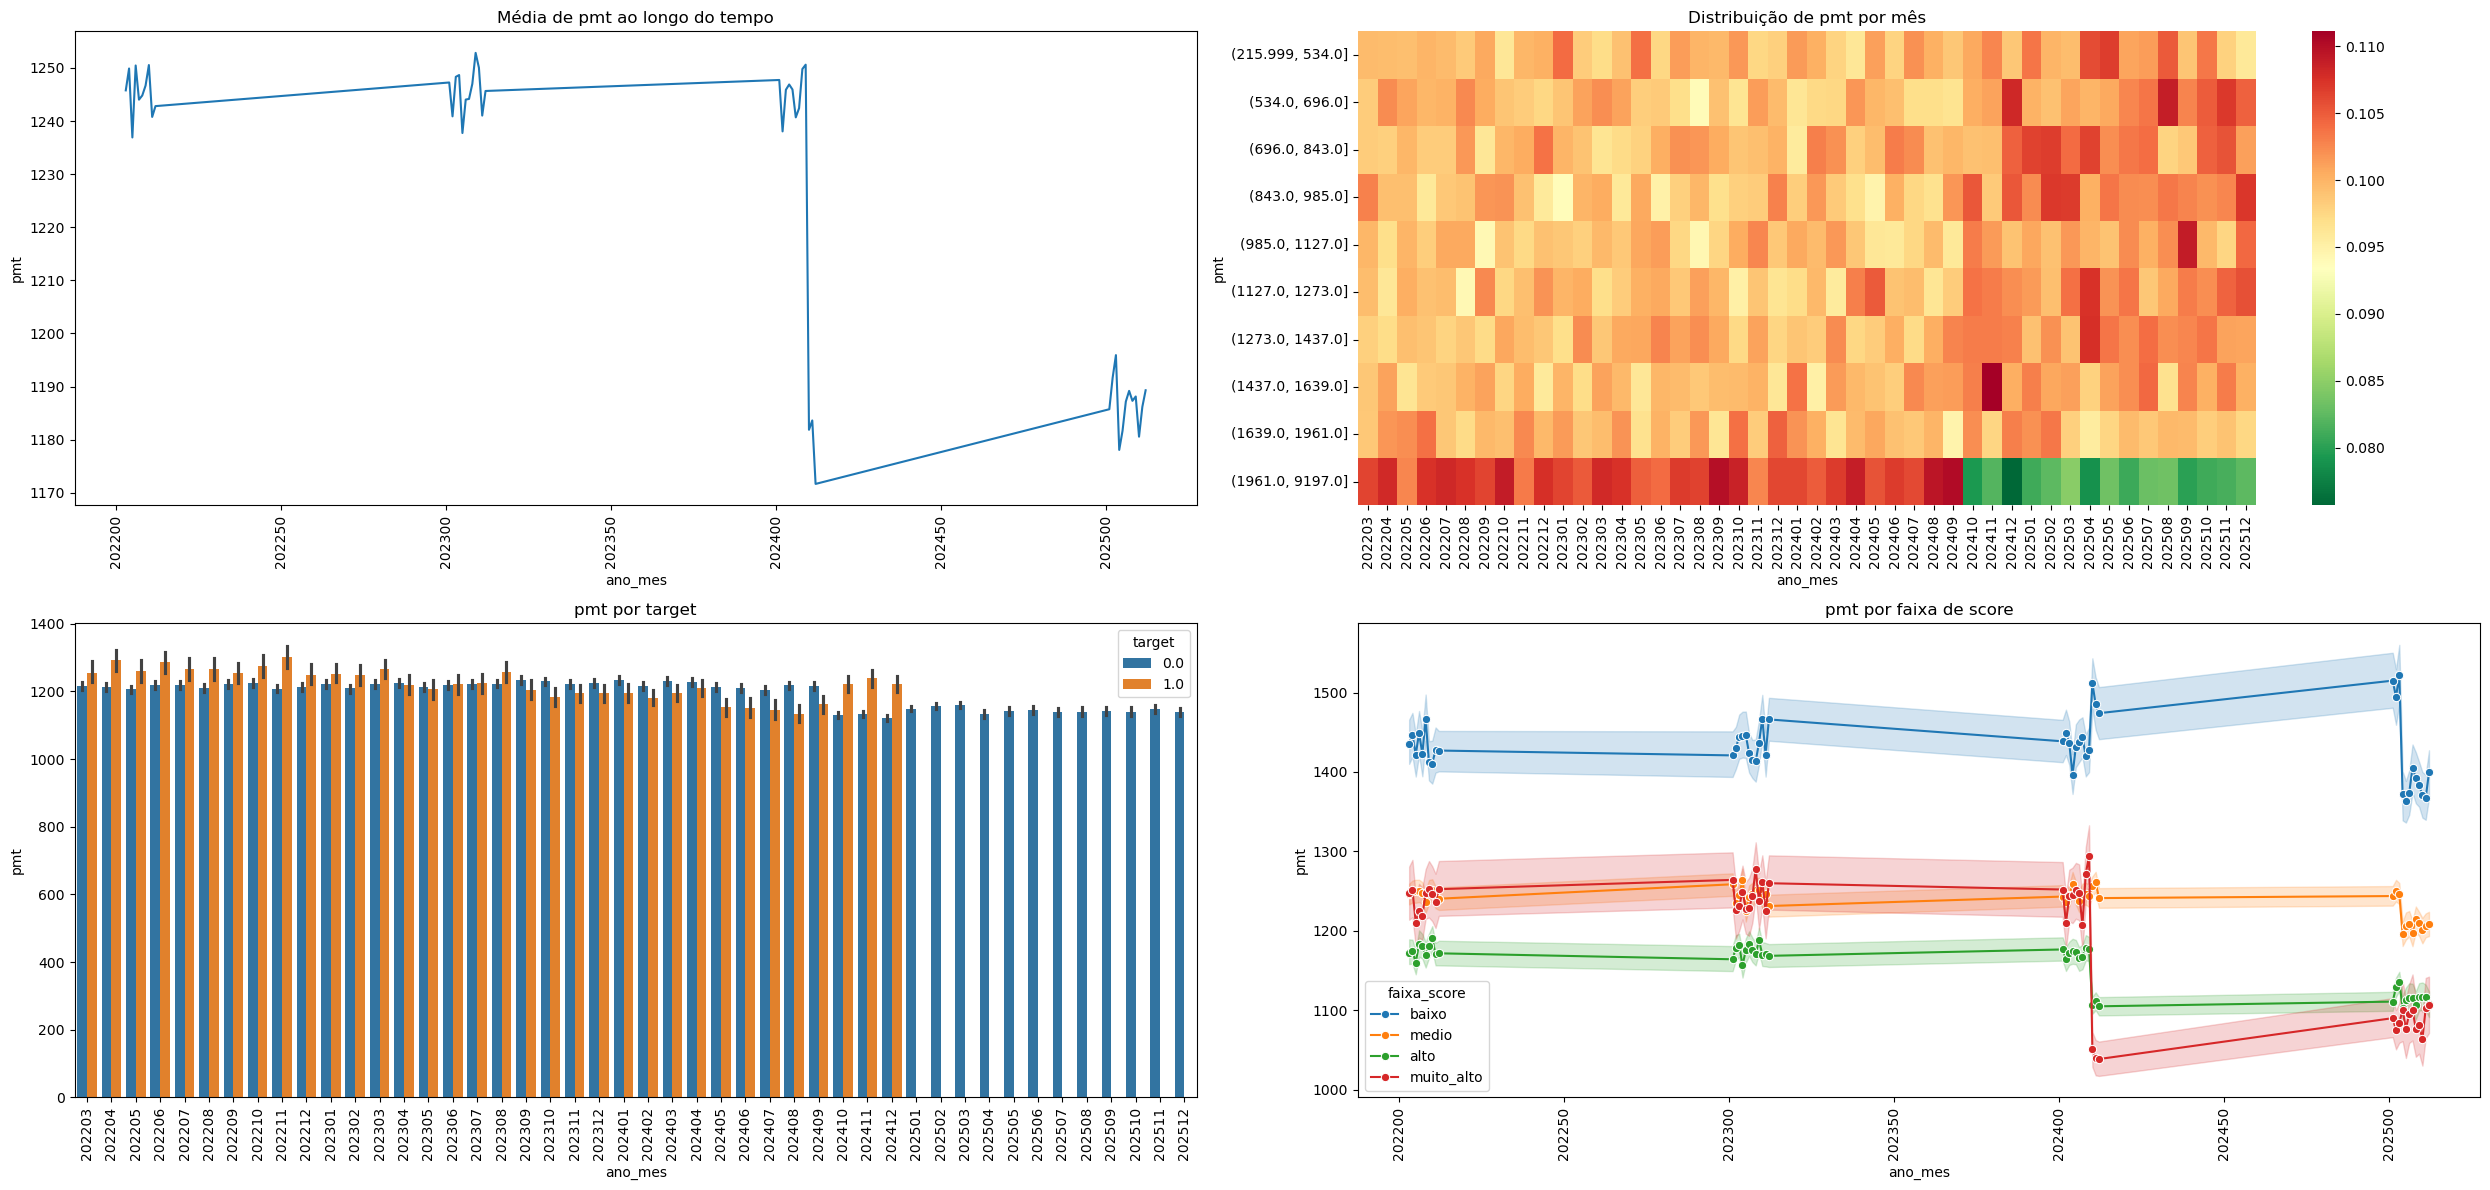

In [253]:
diag_variavel('pmt')

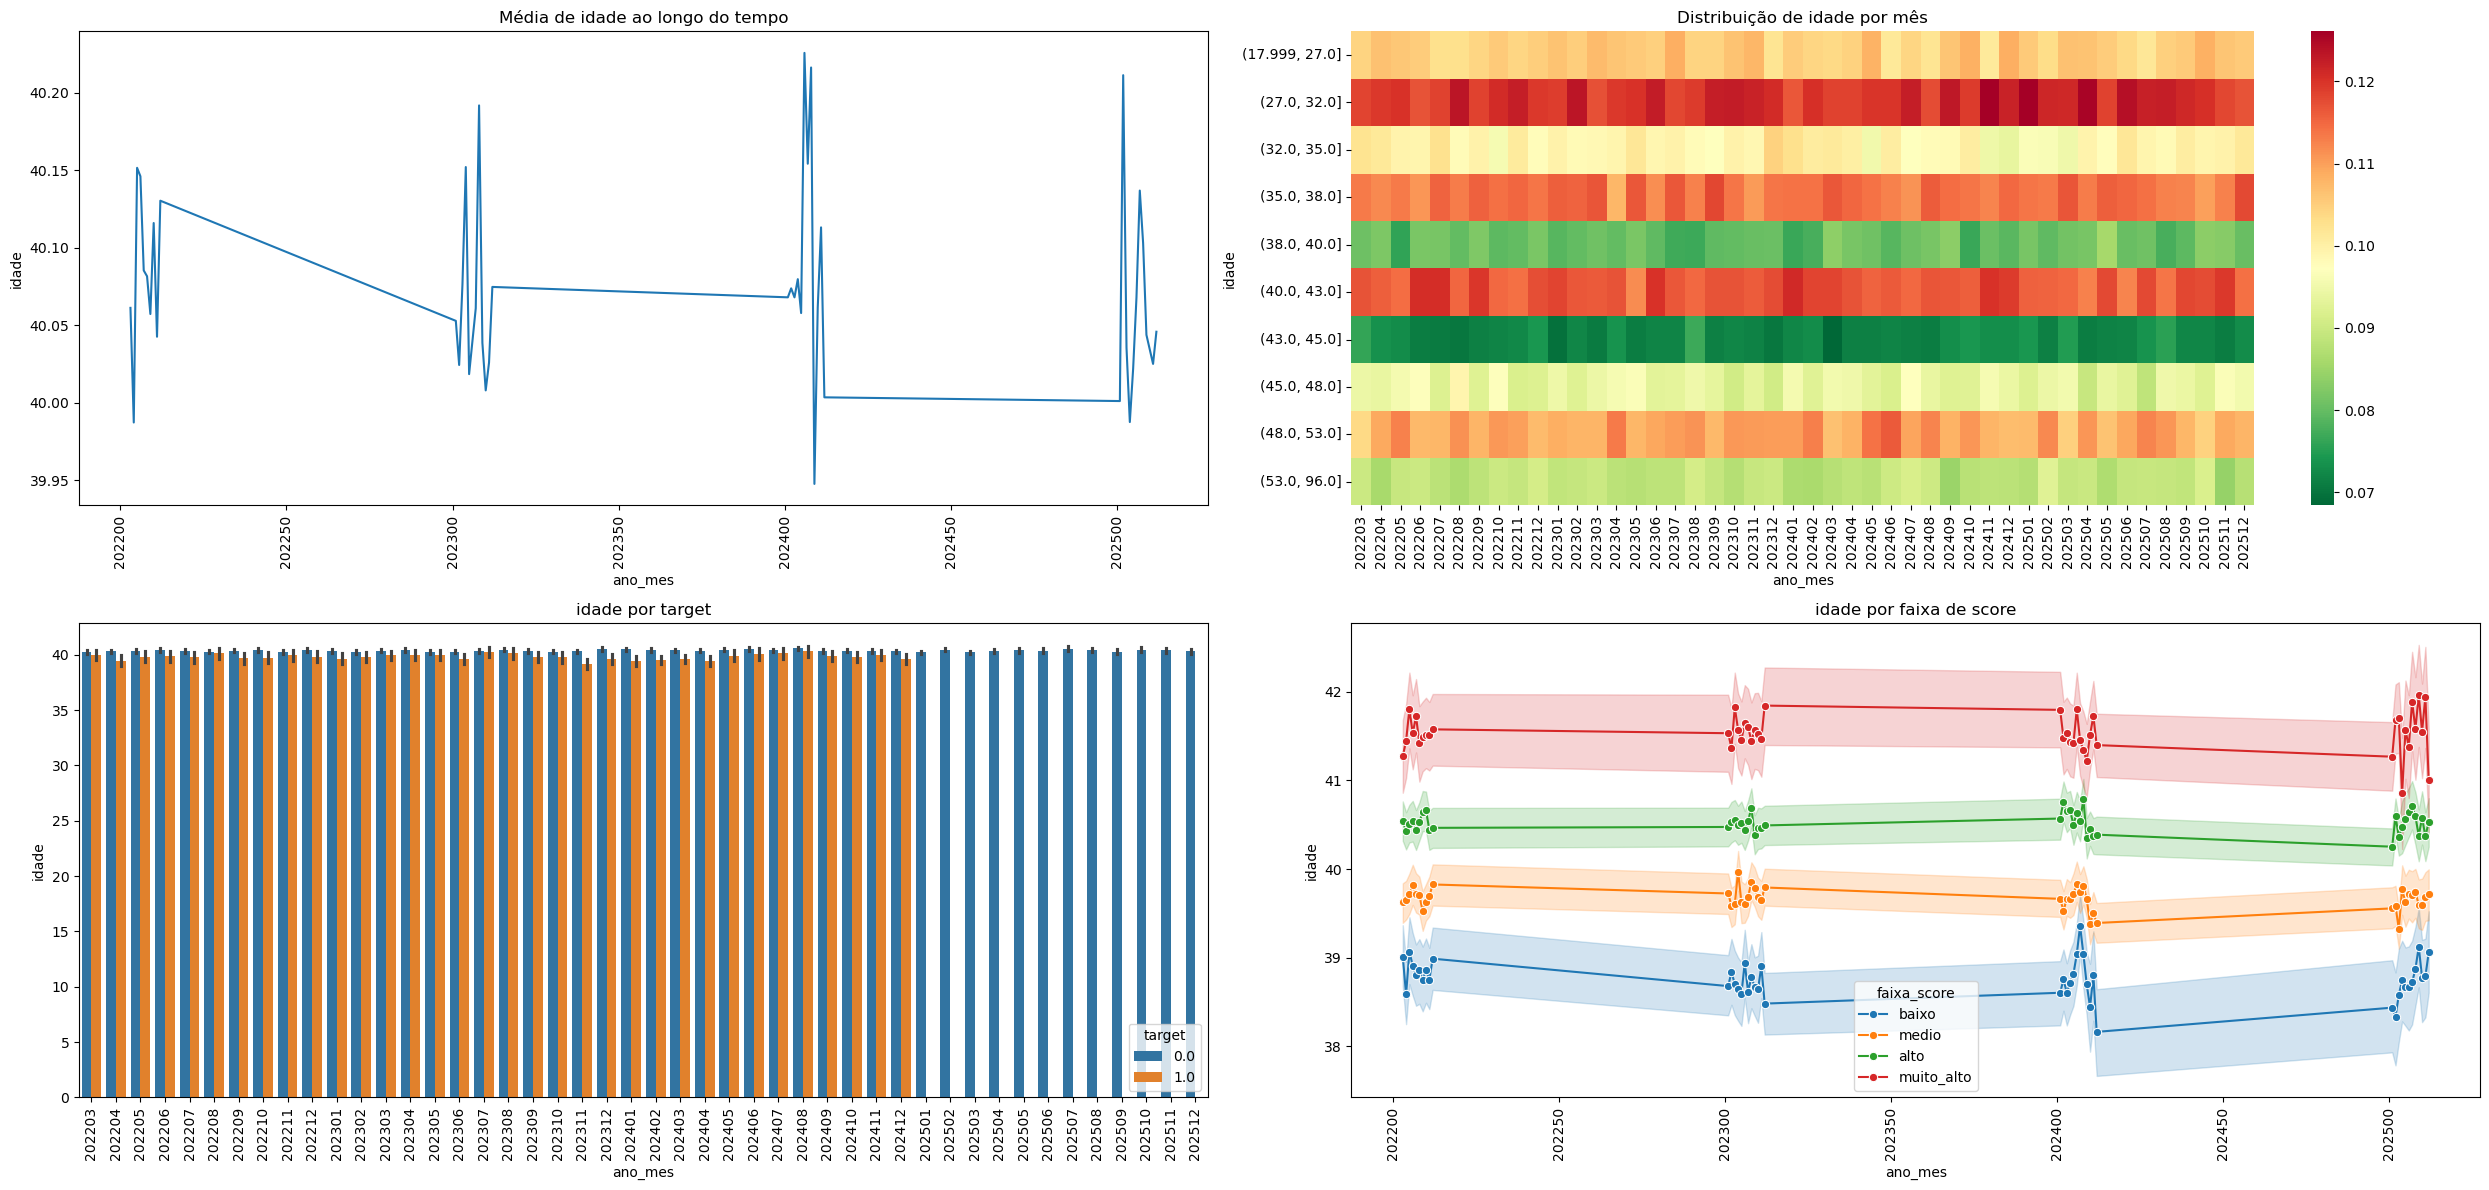

In [252]:
diag_variavel('idade')

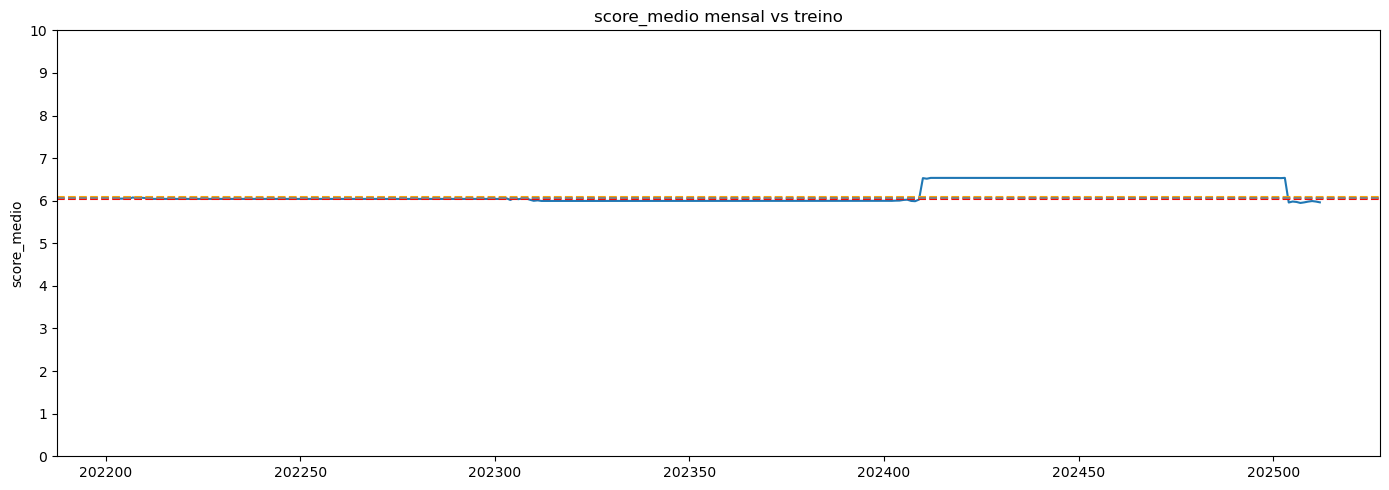

In [284]:
fig, ax = plt.subplots(figsize=(14,5))

df_estb['score_medio'].plot(ax=ax)

ax.axhline(lim_sup, color='orange', linestyle='--')
ax.axhline(lim_inf, color='red', linestyle='--')
ax.axhline(media_score_treinamento, color='gray', linestyle='--')
ax.set_ylim(0, 10)
ax.set_yticks(range(0,11))

ax.set_title('score_medio mensal vs treino')
ax.set_ylabel('score_medio')

plt.tight_layout()

In [285]:

def psi(expected, actual):

    eps = 1e-6
    expected = np.where(expected == 0, eps, expected)
    actual = np.where(actual == 0, eps, actual)

    return np.sum((actual - expected) * np.log(actual / expected))


def monitor_variaveis(df, target='target', score='score', base_treino=None):

    num_vars = df.select_dtypes(include=np.number).columns
    num_vars = [v for v in num_vars if v not in ['ano_mes', target]]

    psi_resumo = []

    for var in num_vars:

        print(f"\n===== {var} =====")

        df_plot = df.copy()

        # bins da variável
        df_plot['bin'] = pd.qcut(df_plot[var], 5, duplicates='drop')

        dist = pd.crosstab(
            df_plot['ano_mes'],
            df_plot['bin'],
            normalize='index'
        )

        # distribuição média da base de treino
        base = dist.loc[base_treino].mean()

        psi_mes = dist.apply(lambda x: psi(base, x), axis=1)

        psi_resumo.append({
            'variavel': var,
            'psi_medio': psi_mes.mean(),
            'psi_max': psi_mes.max()
        })

        # gráfico
        fig, ax = plt.subplots(1,2, figsize=(14,4))

        sns.heatmap(dist.T, cmap="RdYlGn_r", ax=ax[0])
        ax[0].set_title(f"Distribuição {var}")

        psi_mes.plot(ax=ax[1])
        ax[1].axhline(0.1, color='orange', linestyle='--')
        ax[1].axhline(0.2, color='red', linestyle='--')
        ax[1].set_title("PSI ao longo do tempo")

        plt.tight_layout()
        plt.show()

    psi_resumo = pd.DataFrame(psi_resumo).sort_values('psi_max', ascending=False)

    return psi_resumo

In [288]:

df_teste = df[['ano_mes', 'idade_veiculo','marca', 'vl_bem','idade','estado_civil', 'qt_restr', 'renda','Regiao', 'Profissao', 'entrada',
       'prazo', 'pmt', 'target', 'FPD', 'score', 'contratado', 'comp_renda','vl_medio_por_idade_media_veiculo',
       'vl_a_pagar_por_idade_media_veiculo', 'nacionalidade','flg_restr']]

In [289]:
df_teste['vl_medio_por_idade_media_veiculo']

0         11875.000000
1          4750.000000
2         31666.666667
3          4750.000000
4         11875.000000
              ...     
847996        0.000000
847997    11875.000000
847998    31666.666667
847999    31666.666667
848000        0.000000
Name: vl_medio_por_idade_media_veiculo, Length: 848001, dtype: float64


===== idade =====


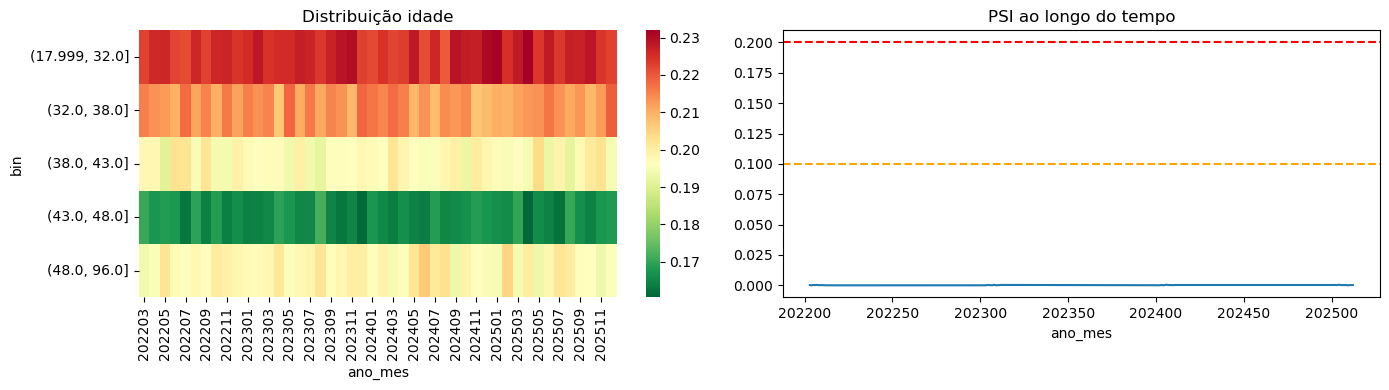


===== renda =====


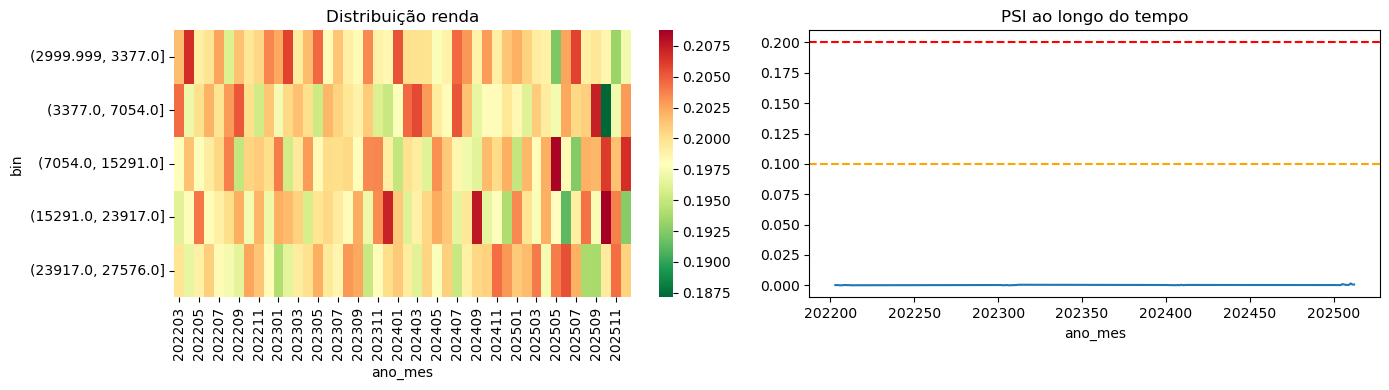


===== entrada =====


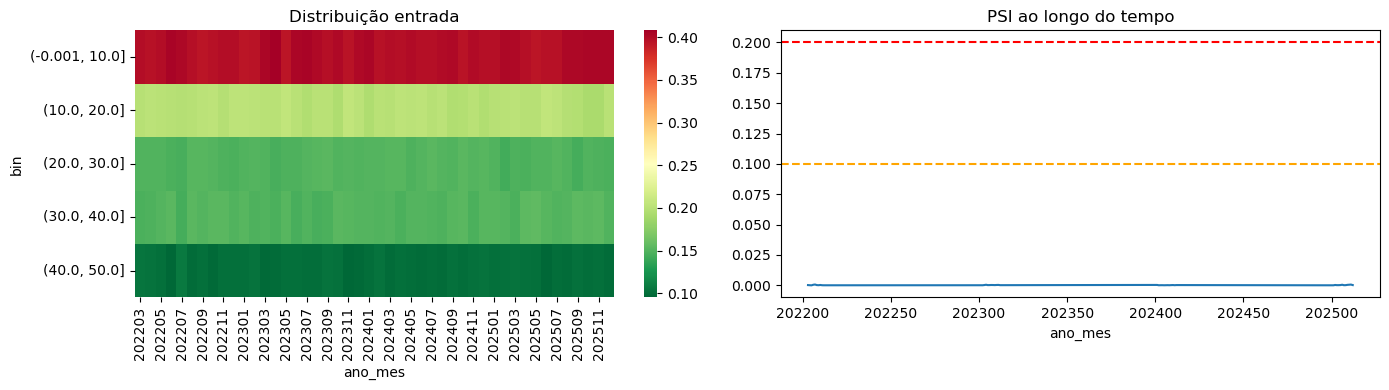


===== prazo =====


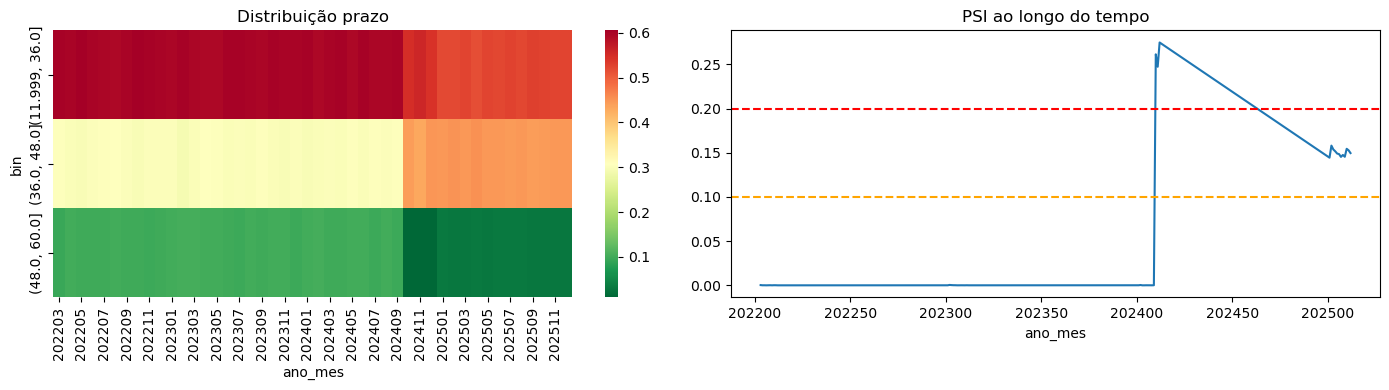


===== pmt =====


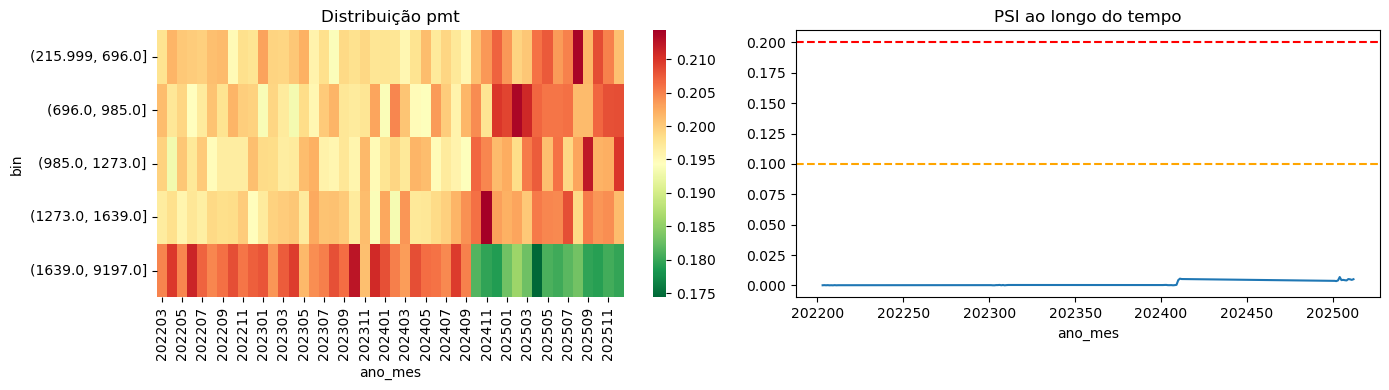


===== FPD =====


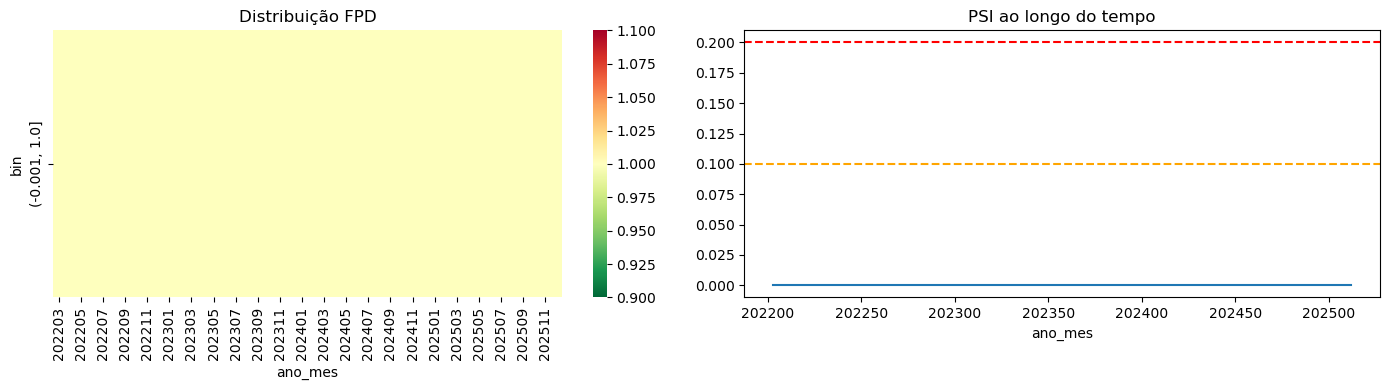


===== score =====


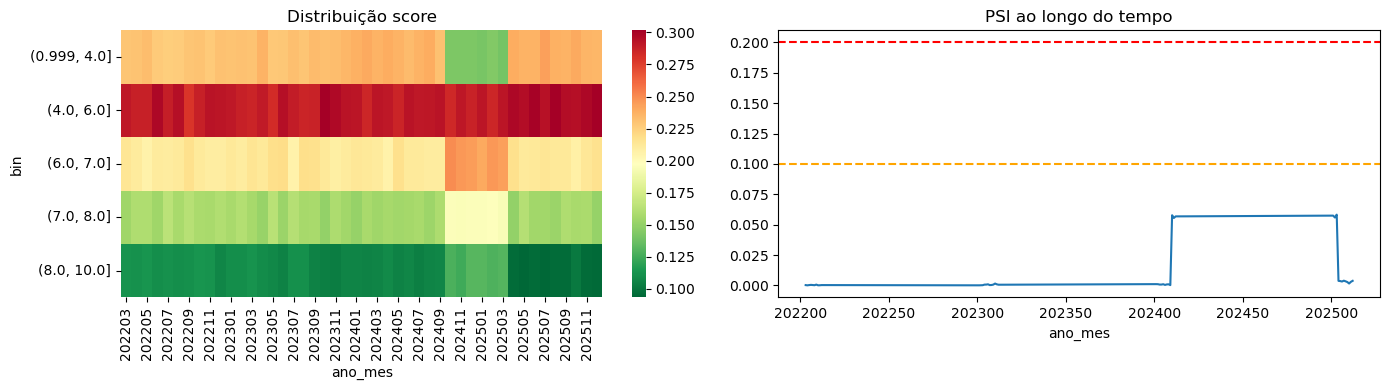


===== contratado =====


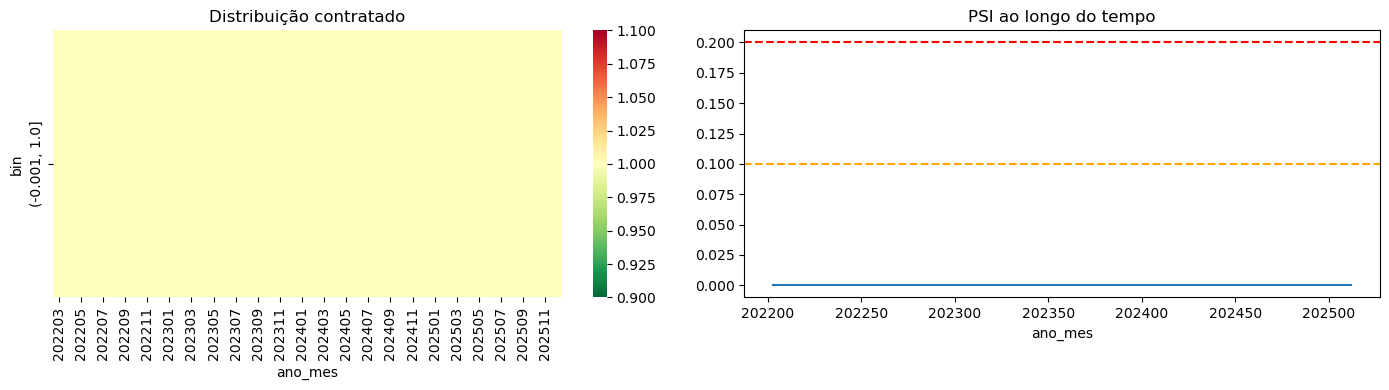


===== comp_renda =====


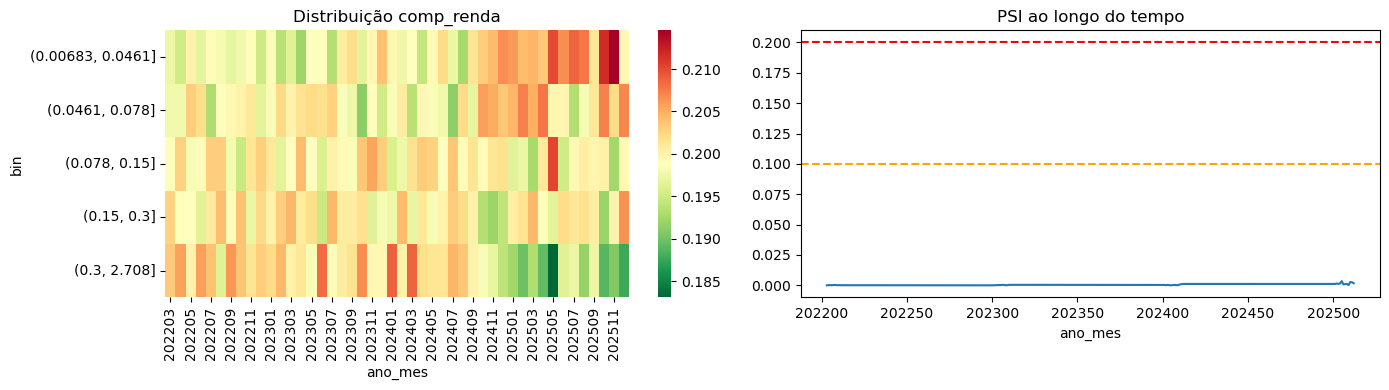


===== vl_medio_por_idade_media_veiculo =====


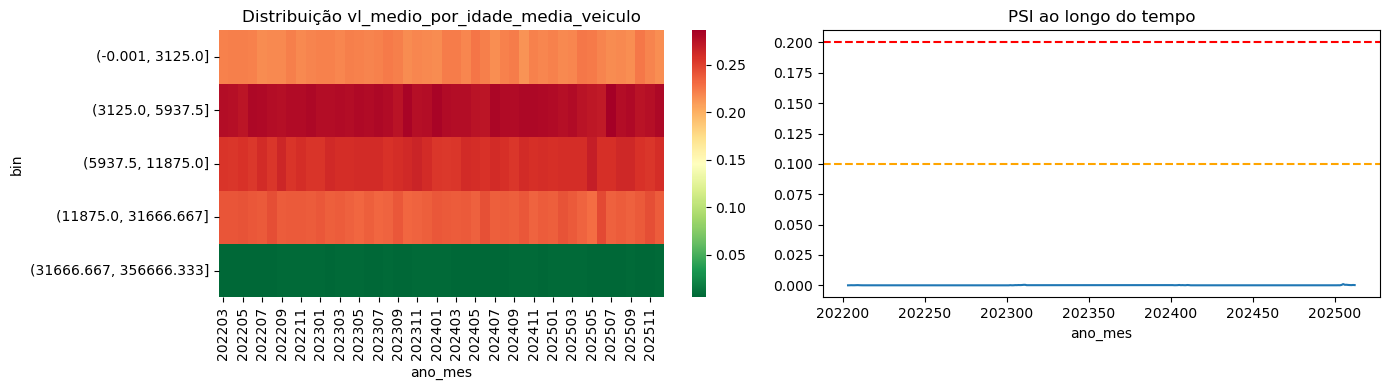


===== vl_a_pagar_por_idade_media_veiculo =====


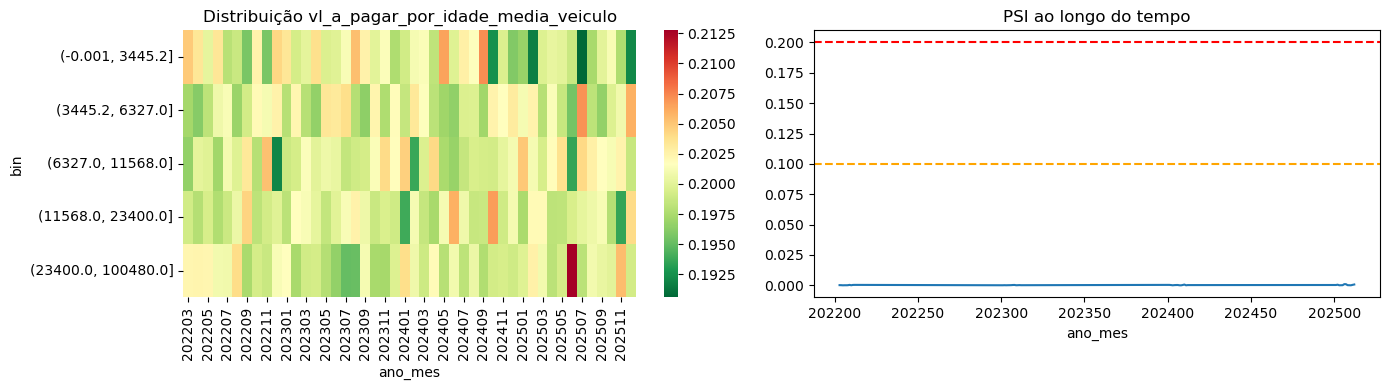


===== flg_restr =====


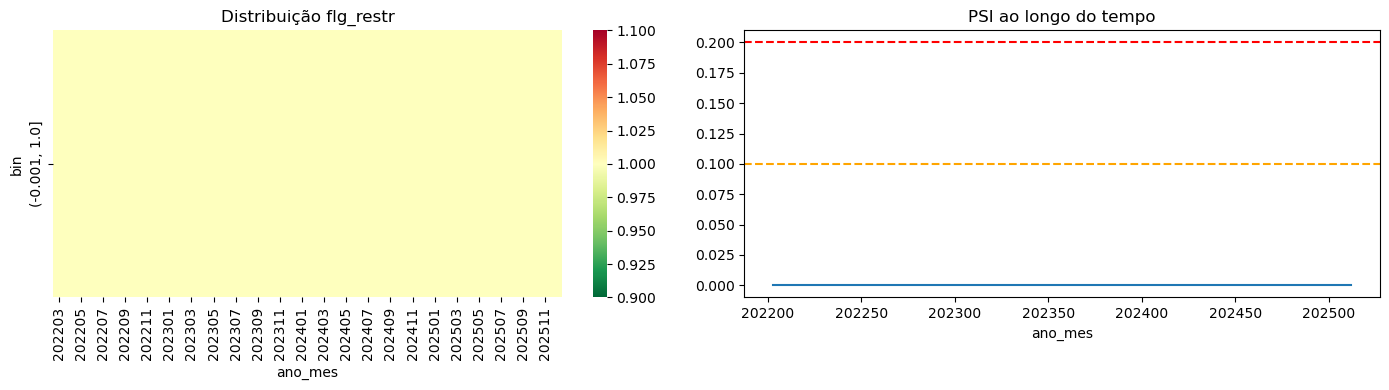

,variavel,psi_medio,psi_max
3,prazo,0.056230,0.274719
6,score,0.008382,0.058243
4,pmt,0.001645,0.006857
8,comp_renda,0.000622,0.003467
1,renda,0.000279,0.001561
9,vl_medio_por_idade_media_veiculo,0.000204,0.001071
10,vl_a_pagar_por_idade_media_veiculo,0.000227,0.000973
2,entrada,0.000220,0.000671
0,idade,0.000222,0.000543
5,FPD,0.000000,0.000000


In [290]:
psi_resumo = monitor_variaveis(
    df_teste,
    target='target',
    score='score',
    base_treino=peri_treinamento
)

psi_resumo

In [291]:

def calc_psi(expected, actual):
    eps = 1e-6
    expected = np.where(expected == 0, eps, expected)
    actual = np.where(actual == 0, eps, actual)
    return np.sum((actual - expected) * np.log(actual / expected))


def variable_stability_dashboard(df, var, target='target', base_treino=None):

    df_plot = df.copy()

    # bins da variável
    df_plot['bin'] = pd.qcut(df_plot[var], 10, duplicates='drop')

    # distribuição por mês
    dist = pd.crosstab(
        df_plot['ano_mes'],
        df_plot['bin'],
        normalize='index'
    )

    # média por mês
    media = df_plot.groupby('ano_mes')[var].mean()

    # PSI
    base = dist.loc[base_treino].mean()
    psi_mes = dist.apply(lambda x: calc_psi(base, x), axis=1)

    # média por target
    target_mean = (
        df_plot
        .groupby(['ano_mes', target])[var]
        .mean()
        .reset_index()
    )

    fig = plt.figure(figsize=(16,10))

    # -------------------------------------------------
    # distribuição
    # -------------------------------------------------

    ax1 = plt.subplot(221)

    sns.heatmap(
        dist.T,
        cmap="RdYlGn_r",
        ax=ax1
    )

    ax1.set_title(f"Distribuição de {var}")
    ax1.set_ylabel(var)

    # -------------------------------------------------
    # média
    # -------------------------------------------------

    ax2 = plt.subplot(222)

    media.plot(ax=ax2)

    ax2.set_title(f"Média de {var}")

    # -------------------------------------------------
    # PSI
    # -------------------------------------------------

    ax3 = plt.subplot(223)

    psi_mes.plot(ax=ax3)

    ax3.axhline(0.1, color='orange', linestyle='--')
    ax3.axhline(0.2, color='red', linestyle='--')

    ax3.set_title("PSI mensal")

    # -------------------------------------------------
    # target
    # -------------------------------------------------

    ax4 = plt.subplot(224)

    sns.lineplot(
        data=target_mean,
        x='ano_mes',
        y=var,
        hue=target,
        marker='o',
        ax=ax4
    )

    ax4.set_title(f"{var} por target")

    for ax in [ax2, ax3, ax4]:
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle(f"Variable Stability Dashboard — {var}", fontsize=16)

    plt.tight_layout()
    plt.show()


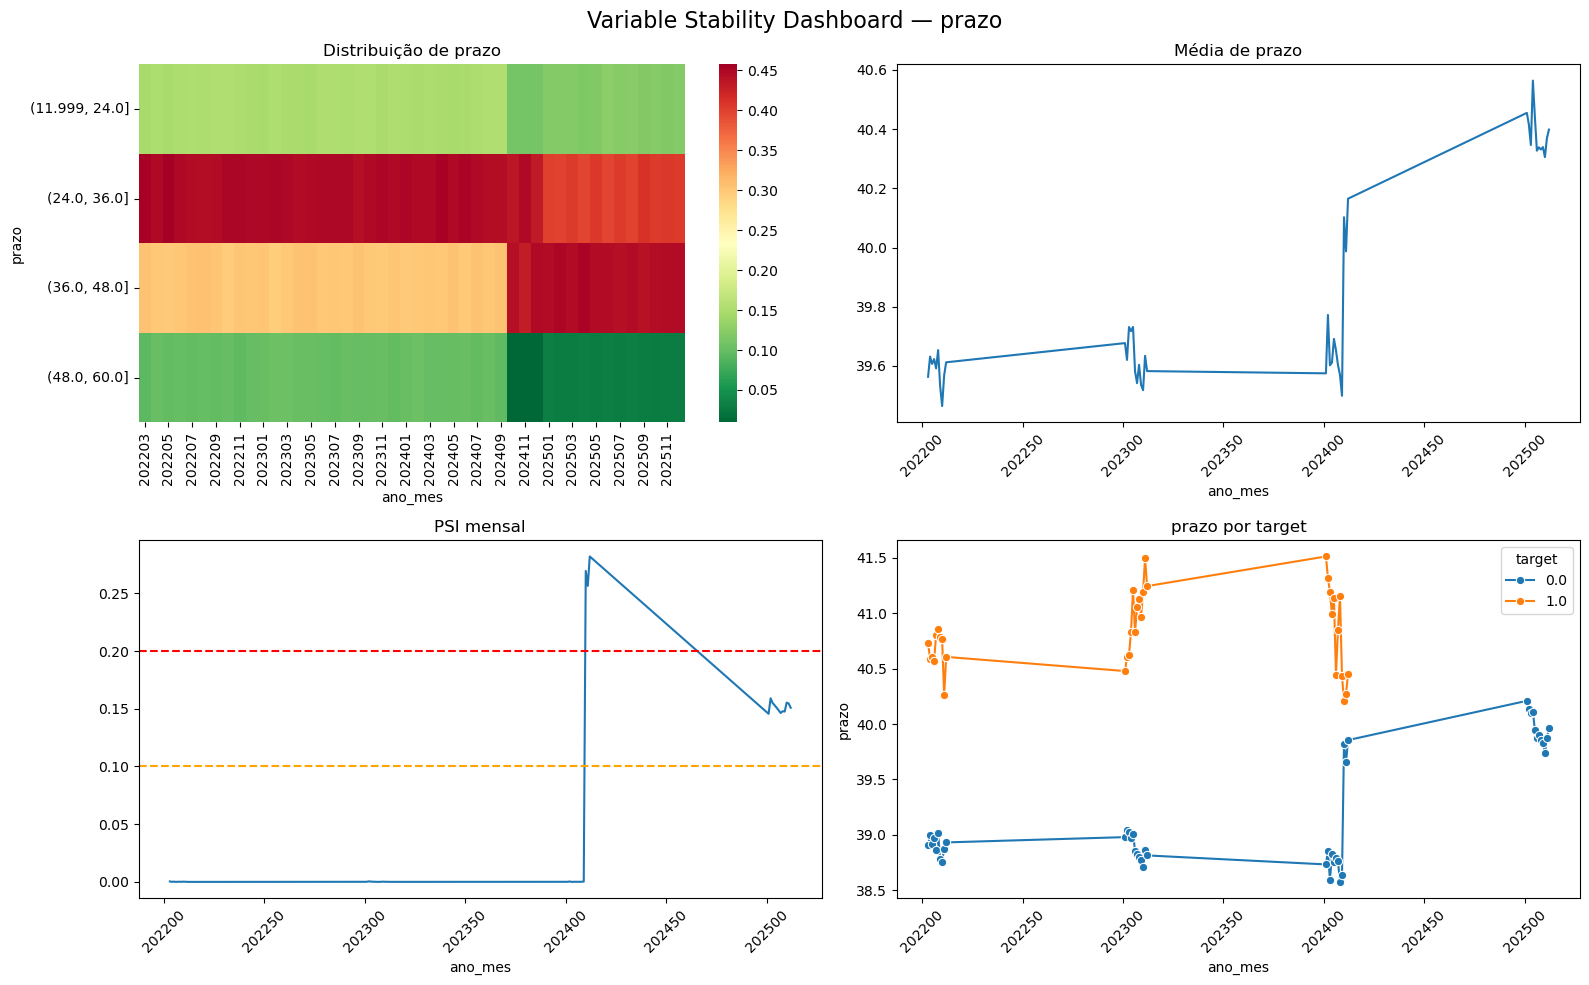

In [292]:

variable_stability_dashboard(
    df_teste,
    var='prazo',
    target='target',
    base_treino=peri_treinamento
)

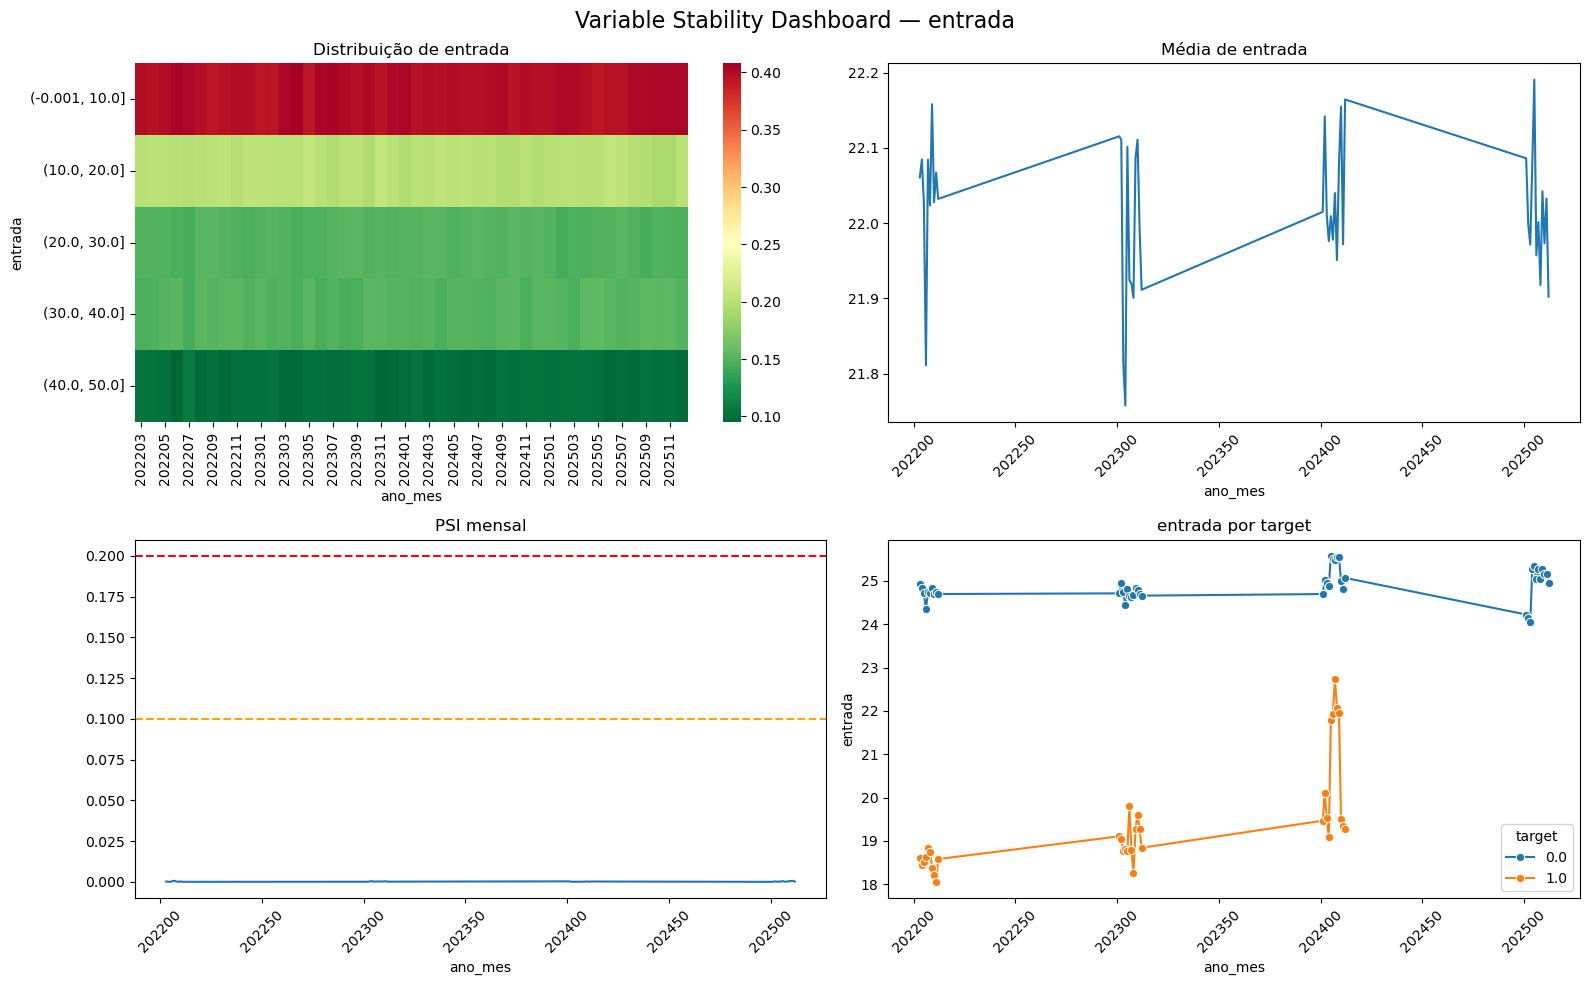

In [242]:
variable_stability_dashboard(
    df_teste,
    var='entrada',
    target='target',
    base_treino=peri_treinamento
)

### Pilar 2 - Discriminação

In [293]:
df_target_0 = df[(df['contratado'] == 1) & (df['target'] == 0)]
df_target_1 = df[(df['contratado'] == 1) & (df['target'] == 1)]

In [294]:

df_target_0 = df[(df['contratado'] == 1) & (df['target'] == 0)]

df_dist_target_0 = pd.crosstab(
    df_target_0['ano_mes'],
    df_target_0['score'],
    normalize='index'
).reindex(columns=range(1,11), fill_value=0)

df_dist_target_0.index.name = None
df_acum_target_0 = df_dist_target_0.cumsum(axis=1)

In [295]:
df_target_1 = df[(df['contratado'] == 1) & (df['target'] == 1)]

df_dist_target_1 = pd.crosstab(
    df_target_1['ano_mes'],
    df_target_1['score'],
    normalize='index'
).reindex(columns=range(1,11), fill_value=0)

df_dist_target_1.index.name = None

df_acum_target_1 = df_dist_target_1.cumsum(axis=1)

In [296]:
ks_mes = (df_acum_target_0 - df_acum_target_1).abs().max(axis=1)
ks_mes

202203    0.355225
202204    0.339296
202205    0.345219
202206    0.324022
202207    0.299863
202208    0.339779
202209    0.347479
202210    0.341130
202211    0.324987
202212    0.346920
202301    0.315722
202302    0.323722
202303    0.331741
202304    0.299153
202305    0.318042
202306    0.311042
202307    0.320967
202308    0.319731
202309    0.296300
202310    0.292812
202311    0.323195
202312    0.310754
202401    0.294877
202402    0.294533
202403    0.318660
202404    0.308191
202405    0.238276
202406    0.225360
202407    0.239862
202408    0.255181
202409    0.234896
202410    0.242635
202411    0.255290
202412    0.246508
202501         NaN
202502         NaN
202503         NaN
202504         NaN
202505         NaN
202506         NaN
202507         NaN
202508         NaN
202509         NaN
202510         NaN
202511         NaN
202512         NaN
dtype: float64

In [297]:
ks_treino = ks_mes[ks_mes.index.isin(peri_treinamento)].mean()
ks_treino

0.3336136658294952

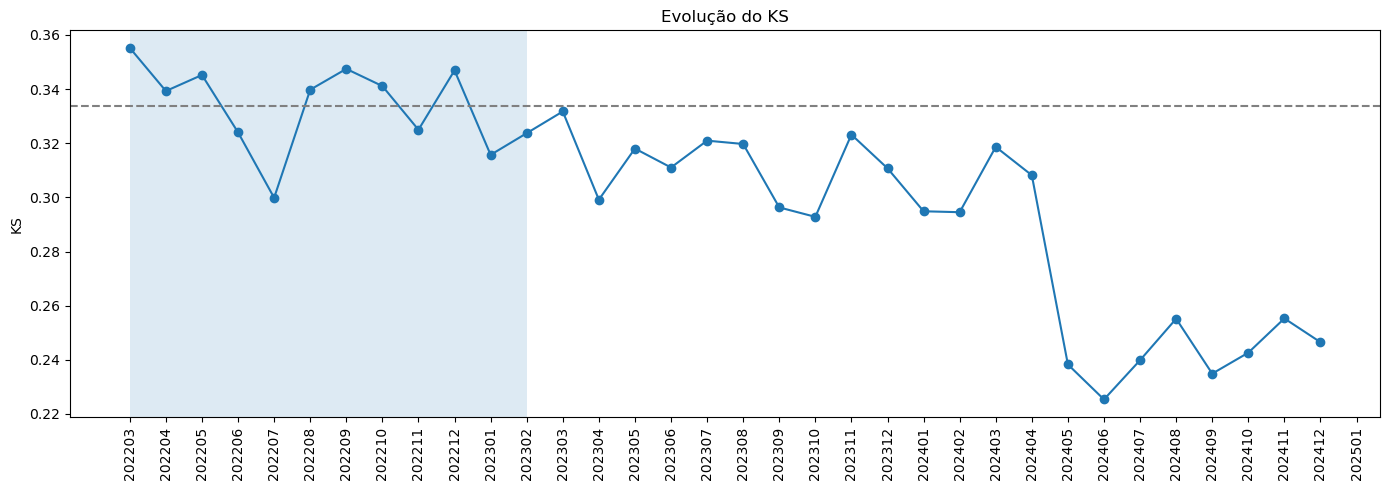

In [298]:
x = range(len(ks_mes))

plt.figure(figsize=(14,5))

plt.plot(x, ks_mes.values, marker='o')

plt.axhline(ks_treino, linestyle='--', color='gray')

plt.xticks(x, ks_mes.index, rotation=90)
plt.axvspan(0, len(peri_treinamento)-1, alpha=0.15)
plt.title("Evolução do KS")
plt.ylabel("KS")

plt.tight_layout()
plt.show()

In [300]:
def ks_table(df, score, target):

    tab = df.groupby(score).agg(
        total=(target,'count'),
        bad=(target,'sum')
    ).sort_index()

    tab['good'] = tab['total'] - tab['bad']

    tab['dist_good'] = tab['good'] / tab['good'].sum()
    tab['dist_bad'] = tab['bad'] / tab['bad'].sum()

    tab['cum_good'] = tab['dist_good'].cumsum()
    tab['cum_bad'] = tab['dist_bad'].cumsum()

    tab['ks'] = (tab['cum_bad'] - tab['cum_good']).abs()

    return tab

In [299]:

ks_treino_tab = ks_table(
    df[df['ano_mes'].isin(peri_treinamento)],
    'score',
    'target'
)

ks_mensal = {}

for mes, d in df.groupby('ano_mes'):

    if d['target'].nunique() < 2:
        continue

    ks_mensal[mes] = ks_table(d, 'score', 'target')

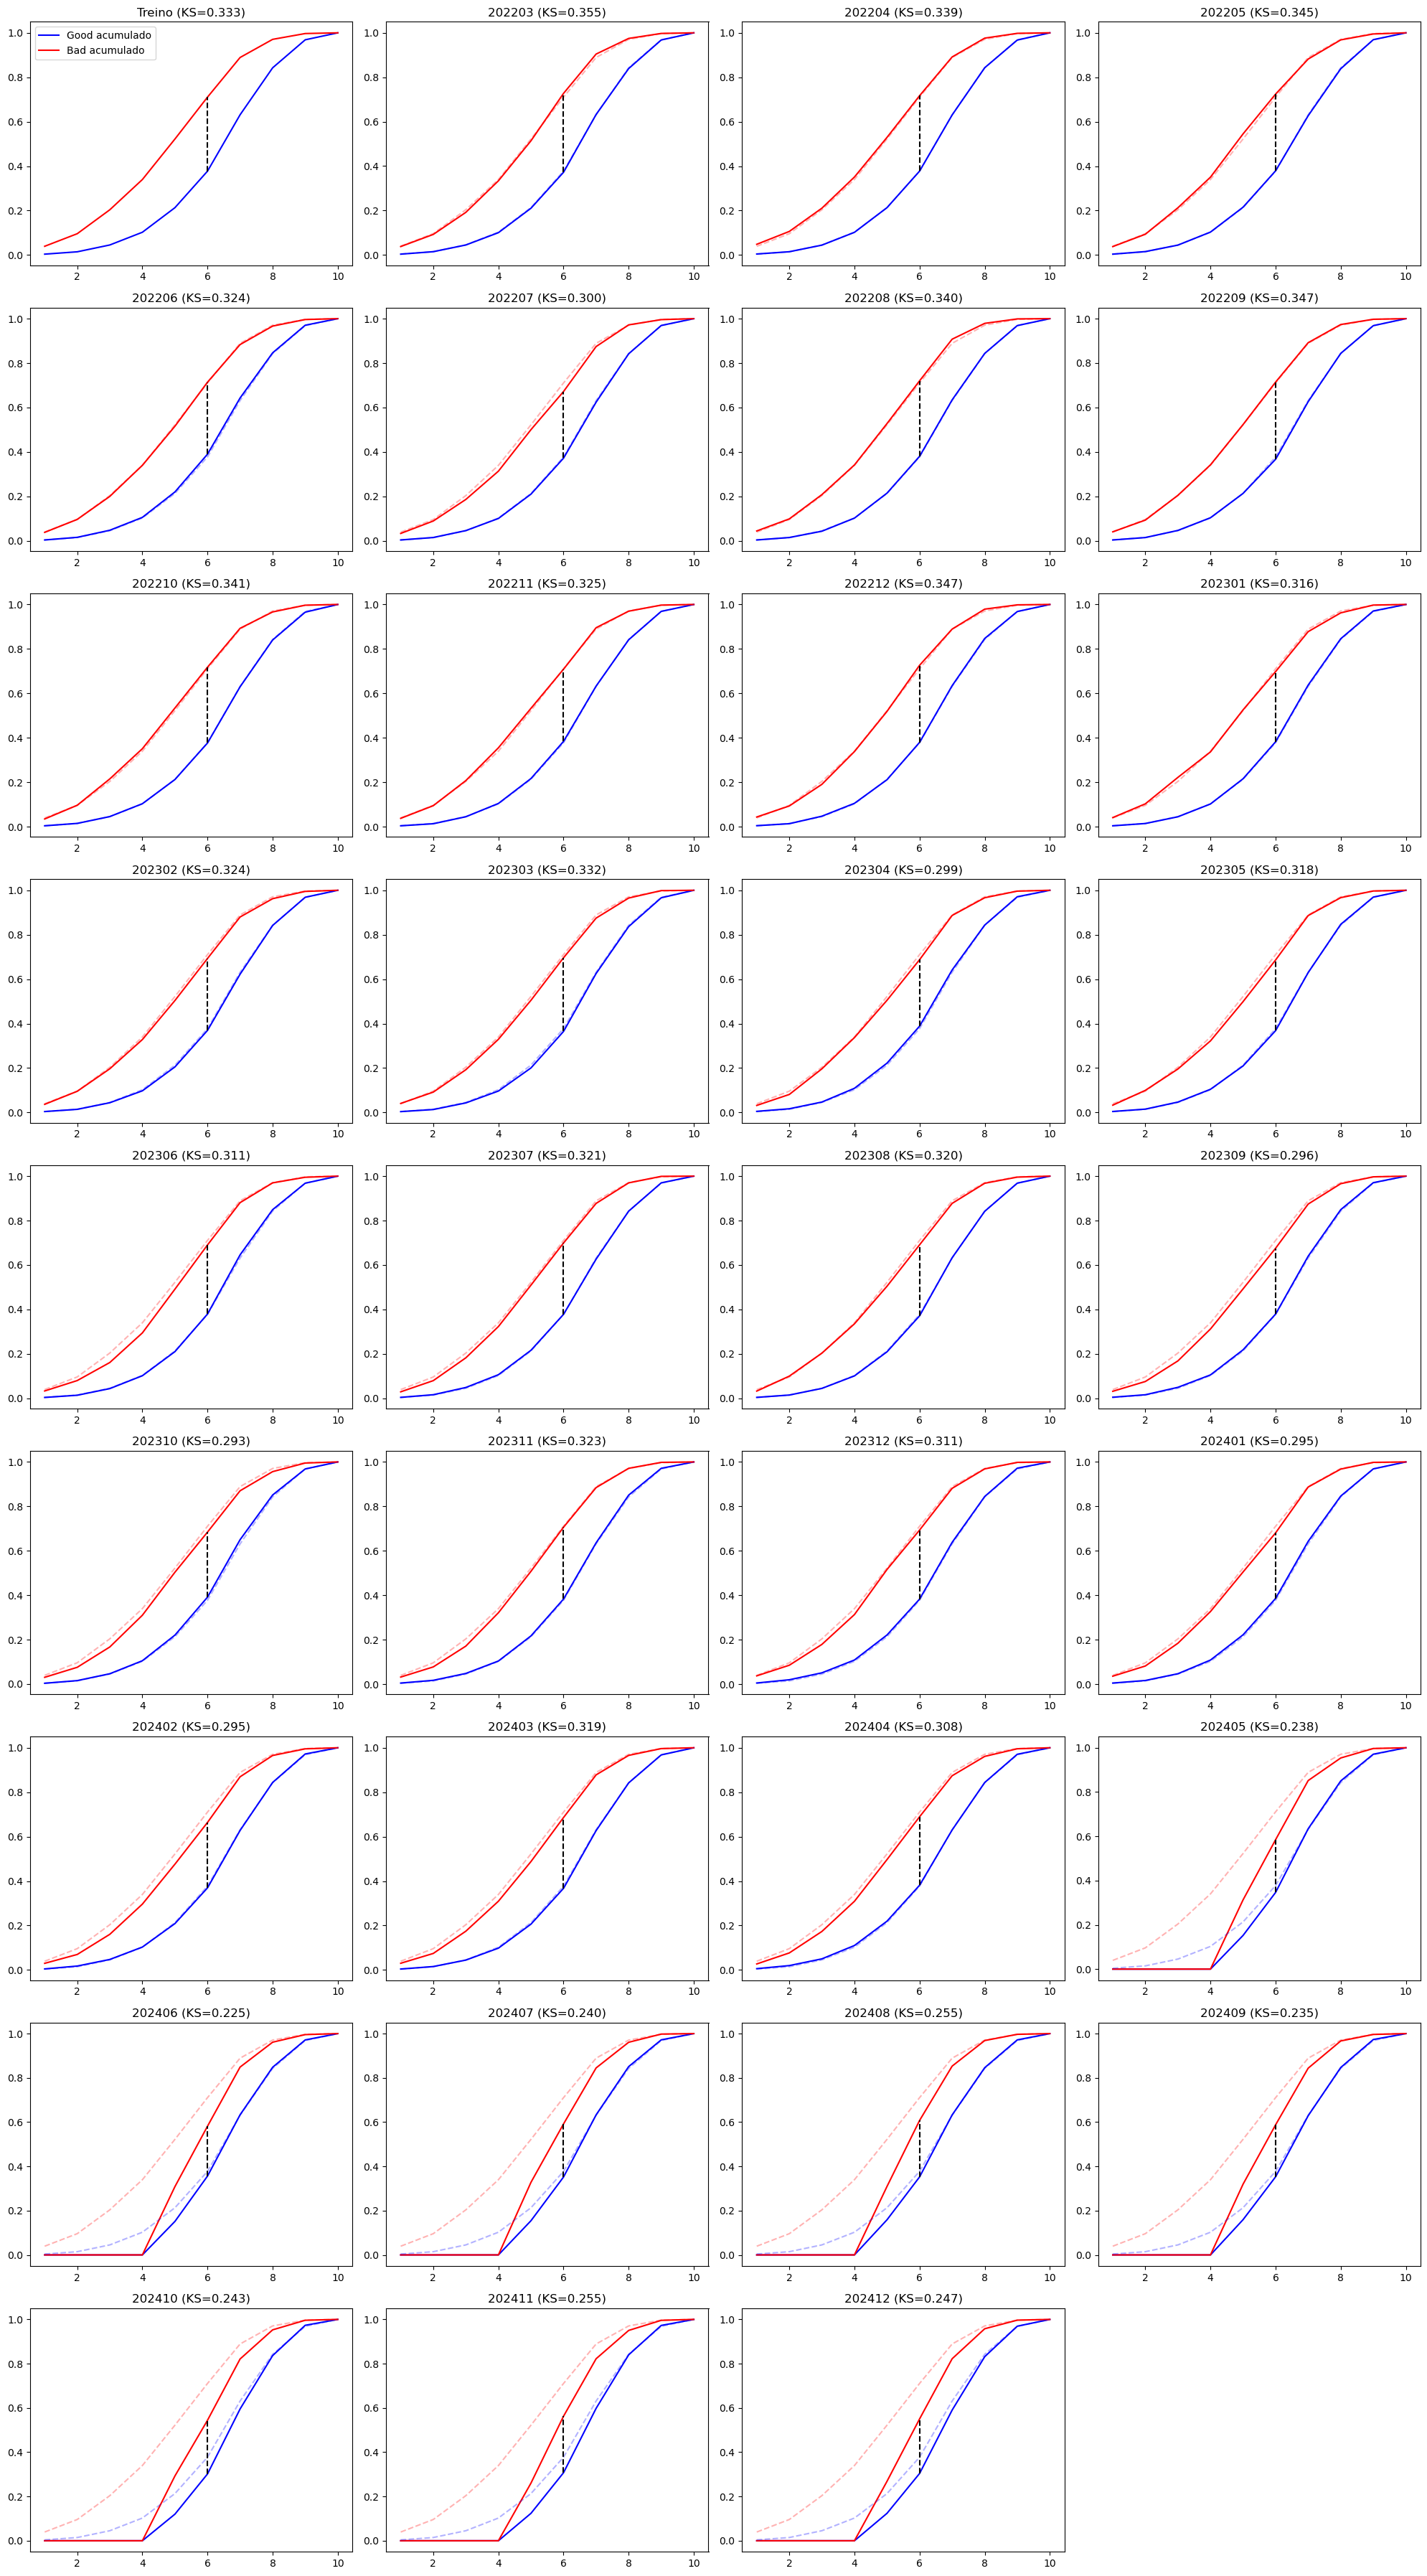

In [301]:

meses = list(ks_mensal.keys())

n = len(meses)

cols = 4
rows = math.ceil((n+1)/cols)

fig, axes = plt.subplots(rows, cols, figsize=(20,4*rows))

axes = axes.flatten()

# gráfico do treino
axes[0].plot(
    ks_treino_tab.index,
    ks_treino_tab['cum_good'],
    label='Good acumulado',
    color='blue'
)

axes[0].plot(
    ks_treino_tab.index,
    ks_treino_tab['cum_bad'],
    label='Bad acumulado',
    color='red'
)

# ponto KS treino
ks_diff = (ks_treino_tab['cum_bad'] - ks_treino_tab['cum_good']).abs()
ks_score = ks_diff.idxmax()
ks_value = ks_diff.max()

axes[0].vlines(ks_score,
               ks_treino_tab.loc[ks_score,'cum_good'],
               ks_treino_tab.loc[ks_score,'cum_bad'],
               color='black',
               linestyle='--')

axes[0].set_title(f"Treino (KS={ks_value:.3f})")

axes[0].legend()

# gráficos mensais
for i, mes in enumerate(meses):

    tab = ks_mensal[mes]

    axes[i+1].plot(tab.index, tab['cum_good'], color='blue')
    axes[i+1].plot(tab.index, tab['cum_bad'], color='red')

    # curva referência treino
    axes[i+1].plot(
        ks_treino_tab.index,
        ks_treino_tab['cum_good'],
        linestyle='--',
        color='blue',
        alpha=0.3
    )

    axes[i+1].plot(
        ks_treino_tab.index,
        ks_treino_tab['cum_bad'],
        linestyle='--',
        color='red',
        alpha=0.3
    )

    # calcular KS do mês
    ks_diff = (tab['cum_bad'] - tab['cum_good']).abs()
    ks_score = ks_diff.idxmax()
    ks_value = ks_diff.max()

    # marcar KS
    axes[i+1].vlines(
        ks_score,
        tab.loc[ks_score,'cum_good'],
        tab.loc[ks_score,'cum_bad'],
        color='black',
        linestyle='--'
    )

    axes[i+1].set_title(f"{mes} (KS={ks_value:.3f})")

# remover eixos vazios
for j in range(i+2, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Mudança expressiva de comportamento a partir de maio/24, com queda expressiva do Ks e ausência para targets <= 4. É muito provável que houve uma mudança de política de concessão de crédito a partir dessa data (implantação do modelo), onde não foi mais concedido crédito para score <= 4

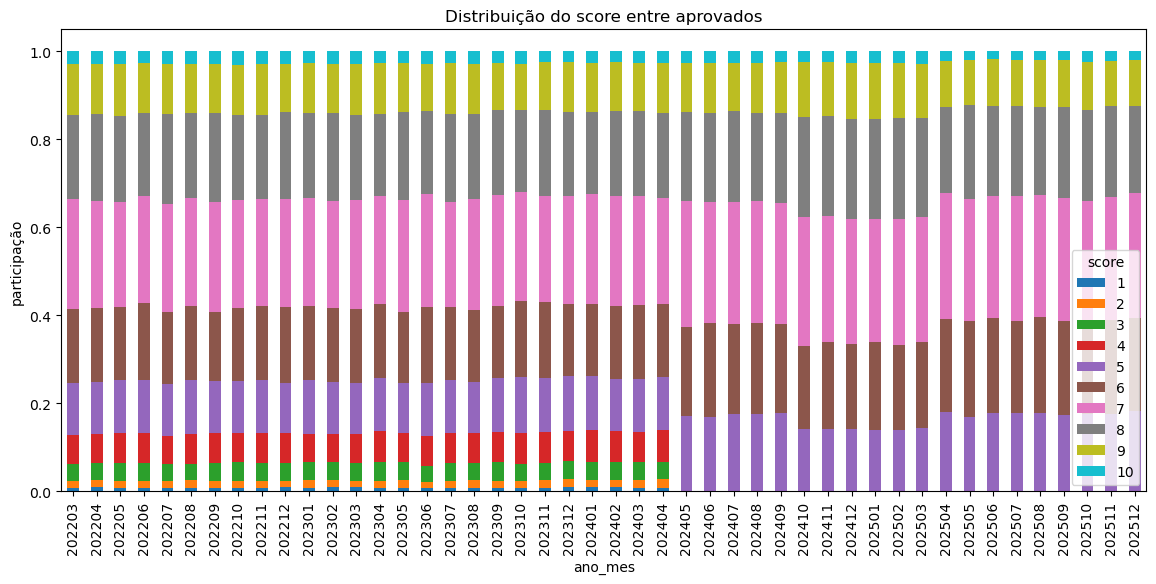

In [302]:
df_aprov = df[df['contratado'] == 1]

dist = pd.crosstab(
    df_aprov['ano_mes'],
    df_aprov['score'],
    normalize='index'
)

dist.plot(kind='bar', stacked=True, figsize=(14,6))
plt.title("Distribuição do score entre aprovados")
plt.ylabel("participação")
plt.xticks(rotation=90)
plt.show()

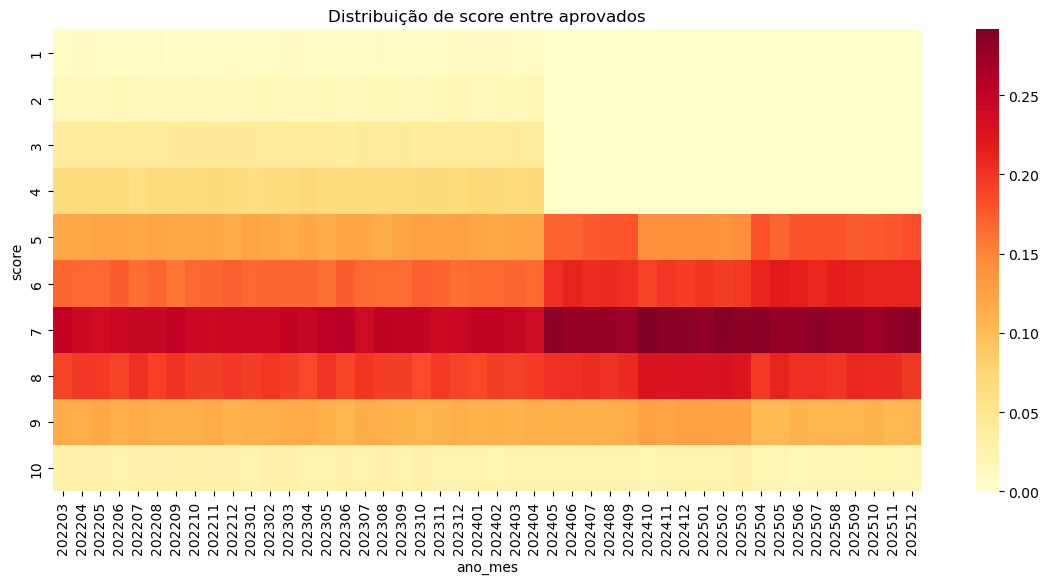

In [303]:
plt.figure(figsize=(14,6))

sns.heatmap(dist.T, cmap="YlOrRd")

plt.title("Distribuição de score entre aprovados")
plt.xlabel("ano_mes")
plt.ylabel("score")

plt.show()

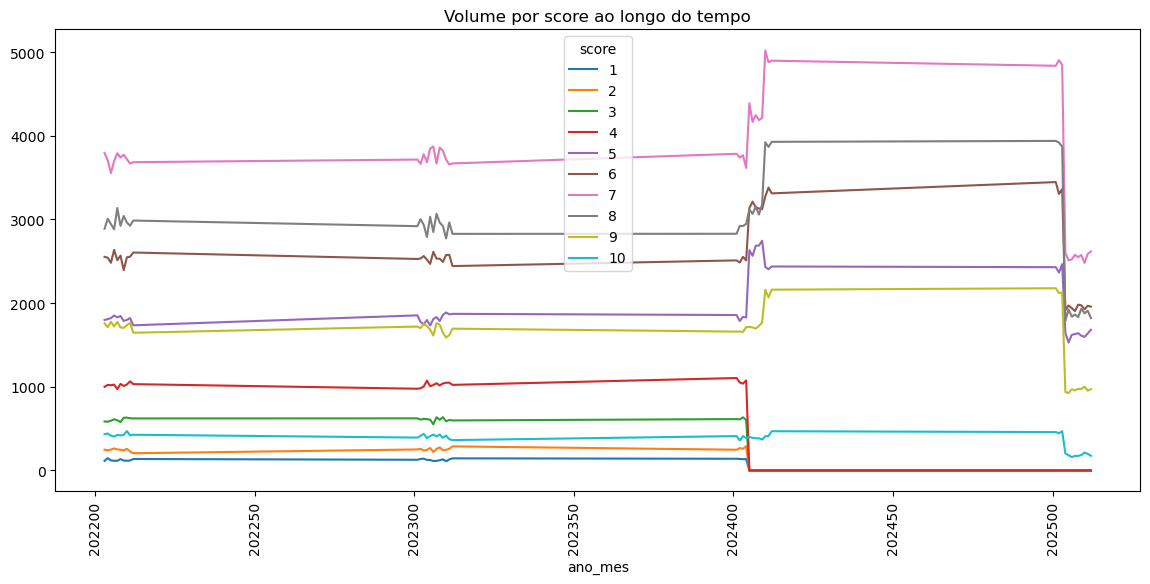

In [304]:
vol = pd.crosstab(df_aprov['ano_mes'], df_aprov['score'])

vol.plot(figsize=(14,6))
plt.title("Volume por score ao longo do tempo")
plt.xticks(rotation=90)
plt.show()

In [305]:
def population_pyramid(df, periodo):

    d = df[df['ano_mes'] == periodo]

    tab = pd.crosstab(
        d['score'],
        d['contratado']
    )

    tab = tab.reindex(range(1,11), fill_value=0)

    rejeitados = -tab[0]   # negativo para ir para esquerda
    aprovados = tab[1]

    plt.figure(figsize=(8,6))

    plt.barh(tab.index, rejeitados, label='rejeitados')
    plt.barh(tab.index, aprovados, label='aprovados')

    plt.axvline(0, color='black')

    plt.xlabel("volume")
    plt.ylabel("score")

    plt.title(f"Population pyramid do score - {periodo}")

    plt.legend()

    plt.show()

Antes da mudanças de política


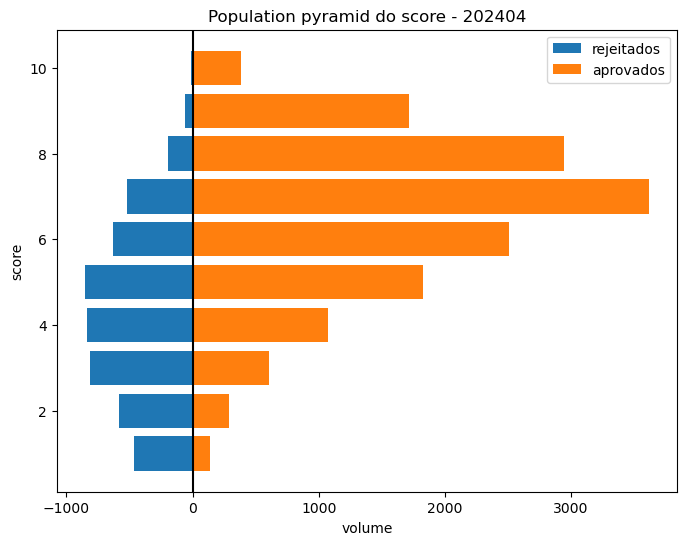

Após mudanças de política e implantação do modelo


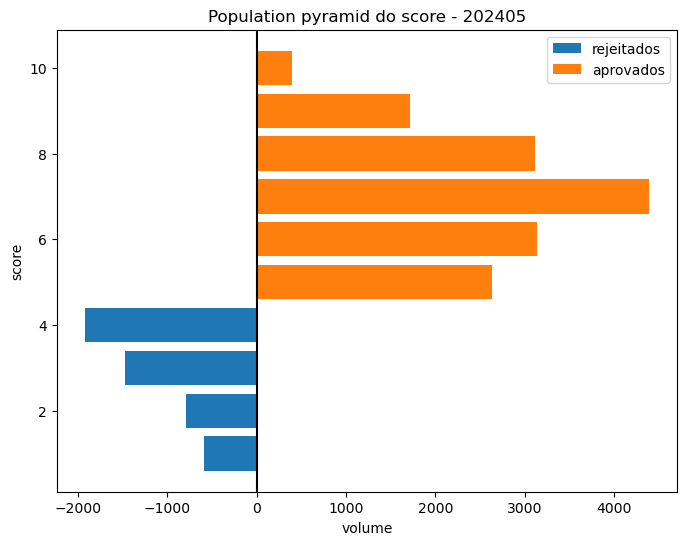

In [307]:
print('Antes da mudanças de política')
population_pyramid(df, 202404)
print('Após mudanças de política e implantação do modelo')
population_pyramid(df, 202405)

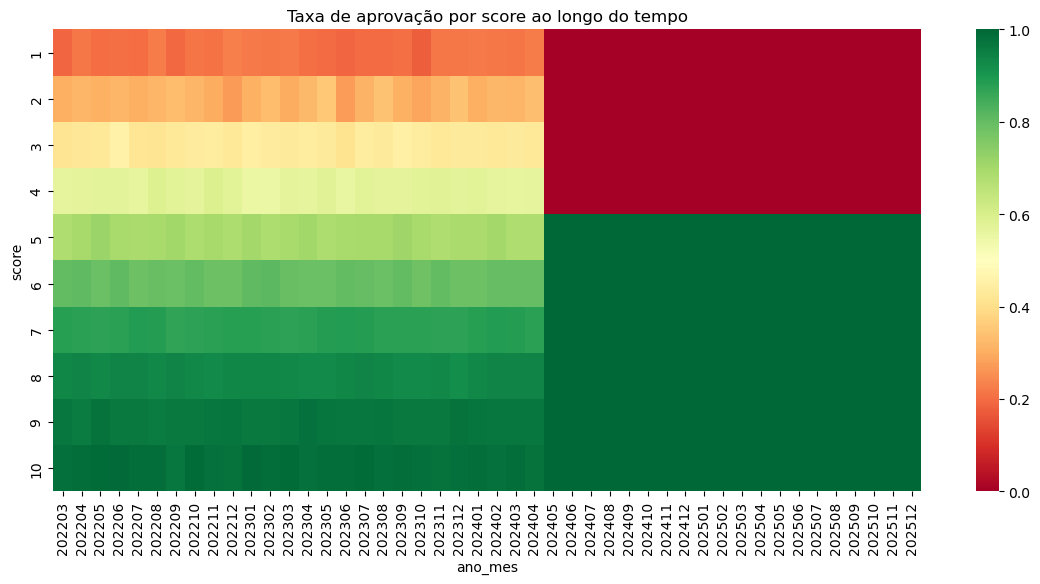

In [308]:
aprov = df.groupby(['ano_mes','score'])['contratado'].mean().unstack()

plt.figure(figsize=(14,6))

sns.heatmap(aprov.T, cmap="RdYlGn", center=0.5)

plt.title("Taxa de aprovação por score ao longo do tempo")
plt.xlabel("ano_mes")
plt.ylabel("score")

plt.show()

#### KS condicional

In [309]:
df_target_0 = df[(df['contratado'] == 1) & (df['target'] == 0) & (df['score'] >= 5)]
df_target_1 = df[(df['contratado'] == 1) & (df['target'] == 1) & (df['score'] >= 5)]

In [310]:
df_ks = df[
    (df['contratado'] == 1) &
    (df['score'] >= 5)
].copy()

ks_treino_tab = ks_table(
    df_ks[df_ks['ano_mes'].isin(peri_treinamento)],
    'score',
    'target'
)

ks_mensal = {}

for mes, d in df_ks.groupby('ano_mes'):

    if d['target'].nunique() < 2:
        continue

    ks_mensal[mes] = ks_table(d, 'score', 'target')

ks_mes = []

for mes, tab in ks_mensal.items():

    ks_mes.append({
        'ano_mes': mes,
        'ks': tab['ks'].max()
    })

ks_mes = pd.DataFrame(ks_mes).sort_values('ano_mes')

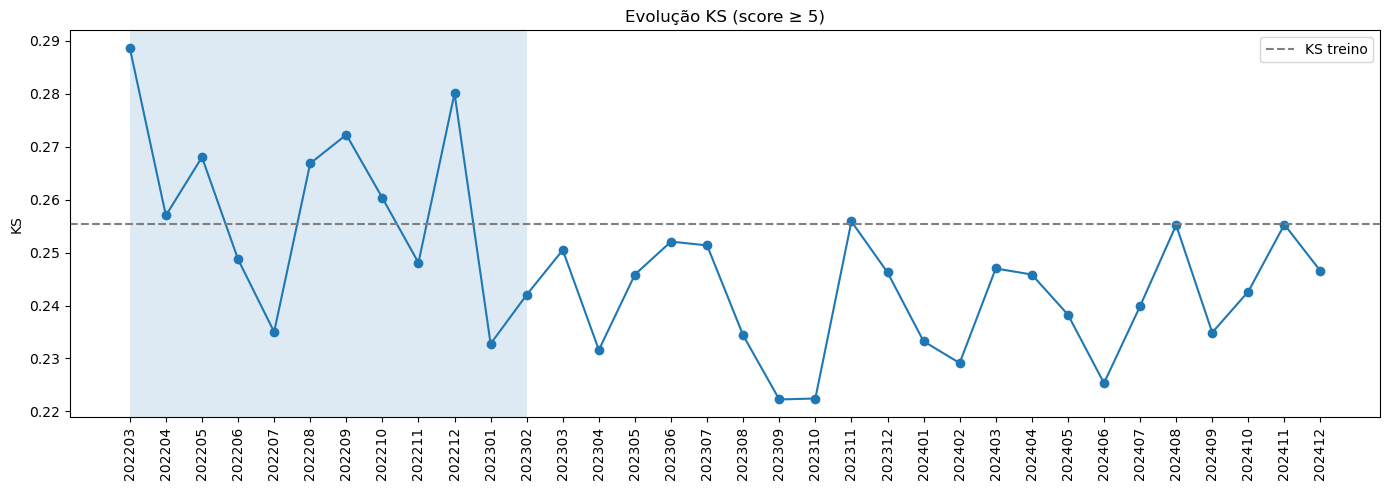

In [311]:
import matplotlib.pyplot as plt

x = range(len(ks_mes))

plt.figure(figsize=(14,5))

plt.plot(x, ks_mes['ks'], marker='o')

plt.axhline(
    ks_treino_tab['ks'].max(),
    linestyle='--',
    color='gray',
    label='KS treino'
)

plt.xticks(x, ks_mes['ano_mes'], rotation=90)

plt.title("Evolução KS (score ≥ 5)")
plt.ylabel("KS")

plt.legend()
plt.axvspan(0, len(peri_treinamento)-1, alpha=0.15)
plt.tight_layout()
plt.show()

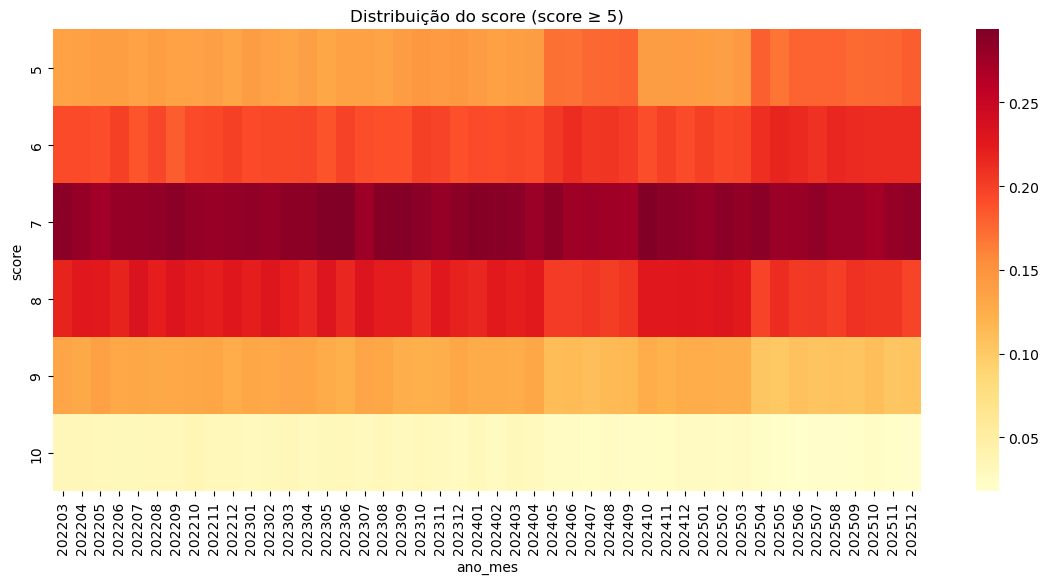

In [312]:
dist = pd.crosstab(
    df_ks['ano_mes'],
    df_ks['score'],
    normalize='index'
)

import seaborn as sns

plt.figure(figsize=(14,6))

sns.heatmap(dist.T, cmap='YlOrRd')

plt.title("Distribuição do score (score ≥ 5)")
plt.xlabel("ano_mes")
plt.ylabel("score")

plt.show()

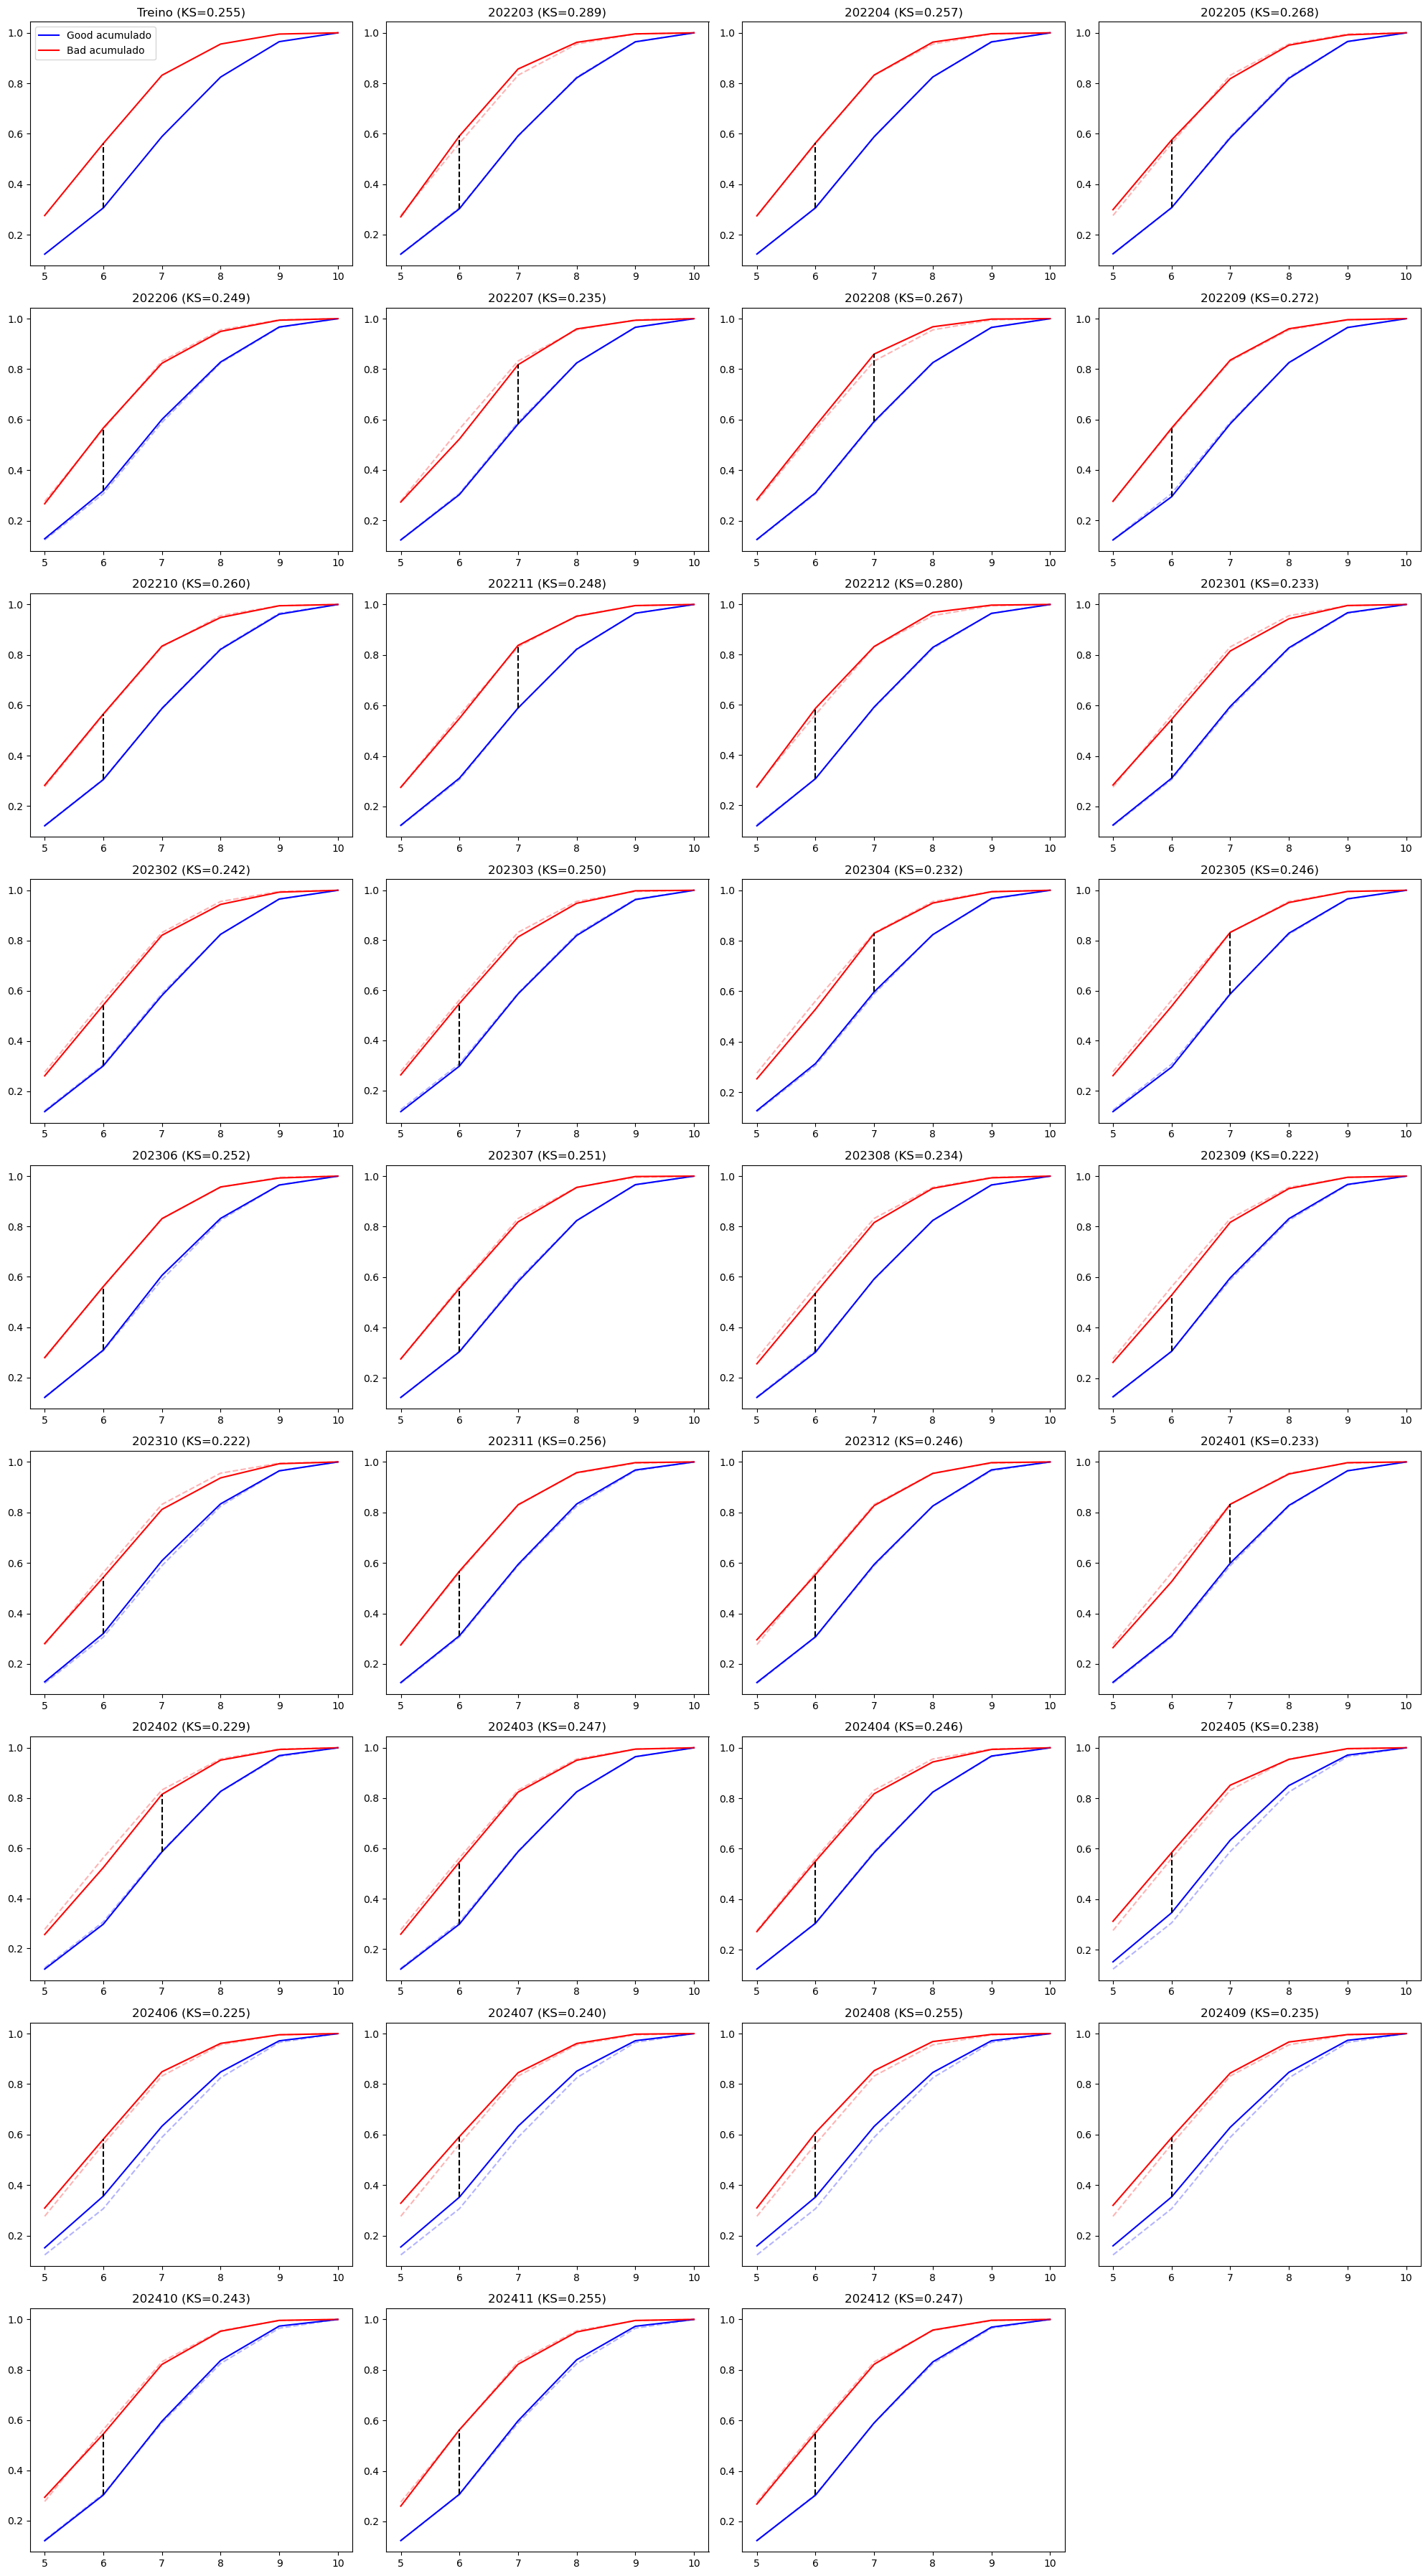

In [313]:

meses = list(ks_mensal.keys())

n = len(meses)

cols = 4
rows = math.ceil((n+1)/cols)

fig, axes = plt.subplots(rows, cols, figsize=(20,4*rows))

axes = axes.flatten()

# gráfico do treino
axes[0].plot(
    ks_treino_tab.index,
    ks_treino_tab['cum_good'],
    label='Good acumulado',
    color='blue'
)

axes[0].plot(
    ks_treino_tab.index,
    ks_treino_tab['cum_bad'],
    label='Bad acumulado',
    color='red'
)

# ponto KS treino
ks_diff = (ks_treino_tab['cum_bad'] - ks_treino_tab['cum_good']).abs()
ks_score = ks_diff.idxmax()
ks_value = ks_diff.max()

axes[0].vlines(ks_score,
               ks_treino_tab.loc[ks_score,'cum_good'],
               ks_treino_tab.loc[ks_score,'cum_bad'],
               color='black',
               linestyle='--')

axes[0].set_title(f"Treino (KS={ks_value:.3f})")

axes[0].legend()

# gráficos mensais
for i, mes in enumerate(meses):

    tab = ks_mensal[mes]

    axes[i+1].plot(tab.index, tab['cum_good'], color='blue')
    axes[i+1].plot(tab.index, tab['cum_bad'], color='red')

    # curva referência treino
    axes[i+1].plot(
        ks_treino_tab.index,
        ks_treino_tab['cum_good'],
        linestyle='--',
        color='blue',
        alpha=0.3
    )

    axes[i+1].plot(
        ks_treino_tab.index,
        ks_treino_tab['cum_bad'],
        linestyle='--',
        color='red',
        alpha=0.3
    )

    # calcular KS do mês
    ks_diff = (tab['cum_bad'] - tab['cum_good']).abs()
    ks_score = ks_diff.idxmax()
    ks_value = ks_diff.max()

    # marcar KS
    axes[i+1].vlines(
        ks_score,
        tab.loc[ks_score,'cum_good'],
        tab.loc[ks_score,'cum_bad'],
        color='black',
        linestyle='--'
    )

    axes[i+1].set_title(f"{mes} (KS={ks_value:.3f})")

# remover eixos vazios
for j in range(i+2, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Condicionando a avaliação para score >= 5, o ks apresenta boa estabilidade

In [314]:
ks_treino = ks_mes[ks_mes['ano_mes'].isin(peri_treinamento)]

media = ks_treino['ks'].mean()
desvio = ks_treino['ks'].std()

lim_sup = media + 2*desvio
lim_inf = media - 2*desvio

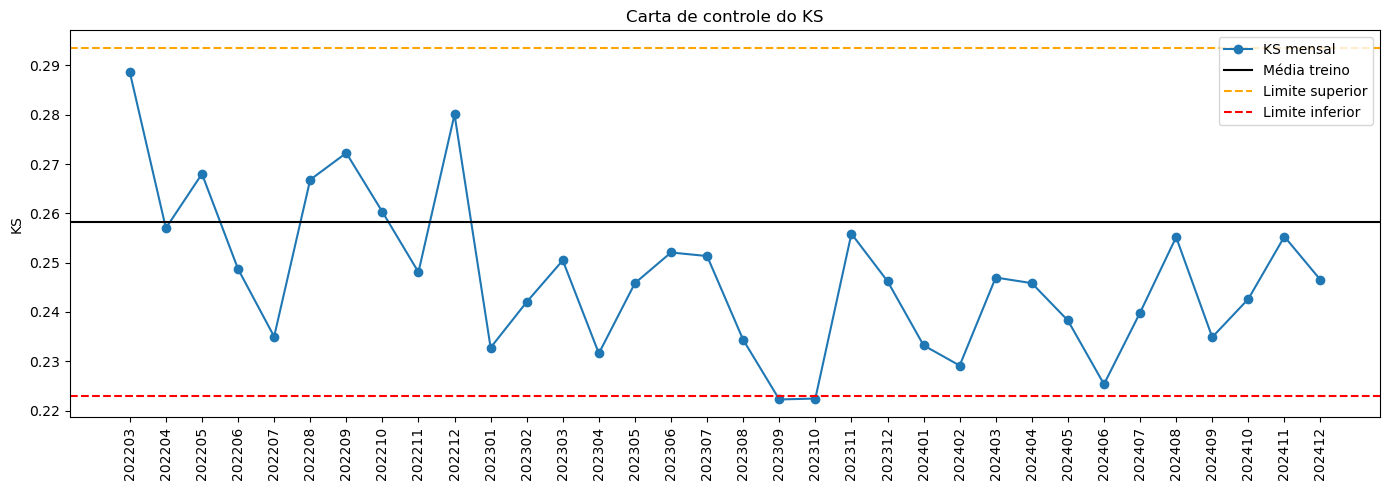

In [315]:
import matplotlib.pyplot as plt

x = range(len(ks_mes))

plt.figure(figsize=(14,5))

plt.plot(x, ks_mes['ks'], marker='o', label='KS mensal')

plt.axhline(media, color='black', linestyle='-', label='Média treino')

plt.axhline(lim_sup, color='orange', linestyle='--', label='Limite superior')

plt.axhline(lim_inf, color='red', linestyle='--', label='Limite inferior')

plt.xticks(x, ks_mes['ano_mes'], rotation=90)

plt.title("Carta de controle do KS")

plt.ylabel("KS")

plt.legend()

plt.tight_layout()

plt.show()

Conforme acima, aplicando o ks condicional a score >=5, percebemos que o modelo não teve perda de discriminação

In [316]:
df_mc = df[df['contratado'] == 1].copy()

df_mc['pred'] = (df_mc['score'] >= 5).astype(int)

In [317]:
from sklearn.metrics import confusion_matrix

mc_mes = {}

for mes, d in df_mc.groupby('ano_mes'):

    if d['target'].nunique() < 2:
        continue

    cm = confusion_matrix(d['target'], d['pred'])

    mc_mes[mes] = cm

In [318]:
df_treino = df_mc[df_mc['ano_mes'].isin(peri_treinamento)]

cm_treino = confusion_matrix(
    df_treino['target'],
    df_treino['pred']
)

In [319]:
def metricas_discriminacao(y_true, y_score):

    auc = roc_auc_score(y_true, y_score)
    gini = 2 * auc - 1

    fpr, tpr, thresholds = roc_curve(y_true, y_score)

    ks = np.max(np.abs(tpr - fpr))

    return auc, gini, ks, fpr, tpr

In [320]:
def avaliar_score(df, score, target):

    auc, gini, ks, fpr, tpr = metricas_discriminacao(
        df[target],
        df[score]
    )

    tabela = pd.DataFrame({
        "Métrica": ["AUC", "Gini", "KS"],
        "Valor": [auc, gini, ks]
    })

    print(tabela)

    # ROC
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1],'--')
    plt.title("Curva ROC")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.show()

    # KS
    plt.figure(figsize=(6,5))
    plt.plot(tpr, label="TPR")
    plt.plot(fpr, label="FPR")
    plt.title(f"KS = {ks:.3f}")
    plt.legend()
    plt.show()

    return tabela

In [321]:
df['target_trat'] = df['target'].fillna(0)

In [322]:
df_aval = df[(df['contratado'] == 1) & (df['ano_mes'] < 202501)]

  Métrica     Valor
0     AUC  0.296532
1    Gini -0.406936
2      KS  0.302723


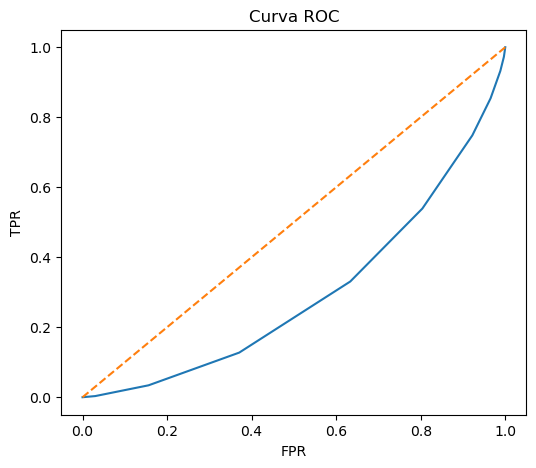

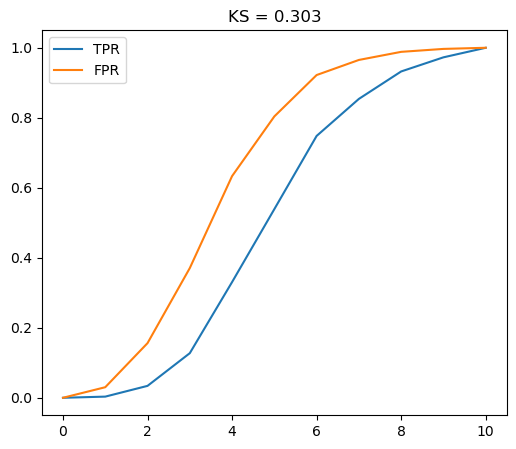

,Métrica,Valor
0,AUC,0.296532
1,Gini,-0.406936
2,KS,0.302723


In [323]:
avaliar_score(df_aval.drop(columns='target'), 'score', 'target_trat')

In [324]:
def avaliar_variaveis(df, target):

    vars_num = df.select_dtypes(include=np.number).columns
    vars_num = [v for v in vars_num if v != target]

    resultados = []

    for var in vars_num:

        try:

            auc, gini, ks, _, _ = metricas_discriminacao(
                df[target],
                df[var]
            )

            resultados.append({
                "variavel": var,
                "auc": auc,
                "gini": gini,
                "ks": ks
            })

        except:
            pass

    tabela = pd.DataFrame(resultados)

    tabela = tabela.sort_values("gini", ascending=False)

    return tabela

In [325]:
tabela_discriminacao = avaliar_variaveis(df_aval.drop(columns=['target','score','id']), 'target_trat')
tabela_discriminacao

,variavel,auc,gini,ks
16,flg_restr,0.568834,0.137667,0.137667
13,idade_media_veiculo,0.568177,0.136354,0.103284
9,tt_financiado_com_juros,0.555313,0.110627,0.088647
4,prazo,0.541812,0.083624,0.058018
8,comp_renda,0.534302,0.068604,0.050332
5,pmt,0.517347,0.034694,0.037787
0,ano_mes,0.509918,0.019837,0.031398
6,FPD,0.508094,0.016187,0.016187
15,vl_a_pagar_por_idade_media_veiculo,0.502649,0.005298,0.044931
7,contratado,0.500000,0.000000,0.000000


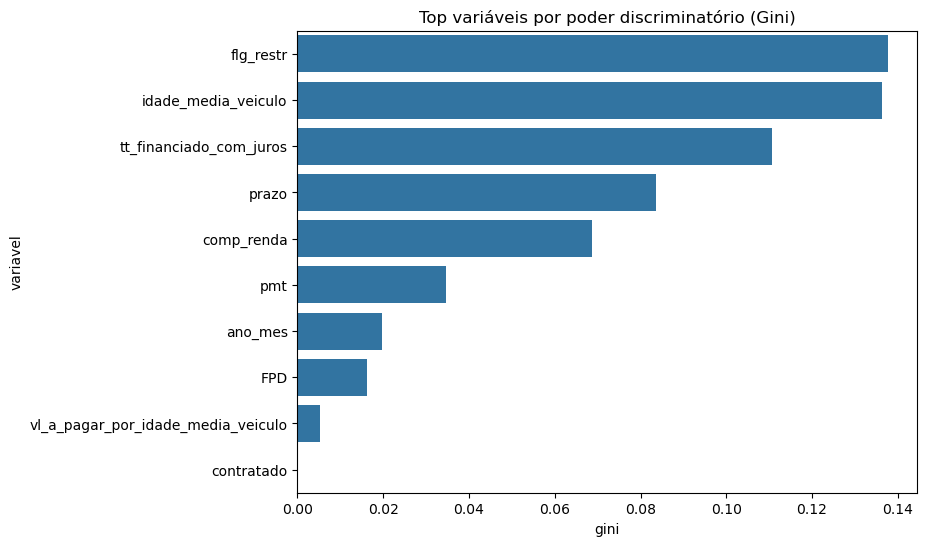

In [327]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=tabela_discriminacao.head(10),
    x="gini",
    y="variavel"
)

plt.title("Top variáveis por poder discriminatório (Gini)")
plt.show()

In [328]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve


def metricas_periodo(df, score, target, periodo='ano_mes'):

    resultados = []

    for p, d in df.groupby(periodo):

        if d[target].nunique() < 2:
            continue

        auc = roc_auc_score(d[target], d[score])
        gini = 2*auc - 1

        fpr, tpr, _ = roc_curve(d[target], d[score])
        ks = np.max(np.abs(tpr - fpr))

        resultados.append({
            periodo: p,
            'auc': auc,
            'gini': gini,
            'ks': ks,
            'n': len(d)
        })

    res = pd.DataFrame(resultados).sort_values(periodo)

    return res

In [329]:
evolucao = metricas_periodo(df, 'score', 'target_trat')

evolucao

,ano_mes,auc,gini,ks,n
0,202203,0.366780,-0.266440,0.228840,20095
1,202204,0.363824,-0.272352,0.218277,20037
2,202205,0.364314,-0.271371,0.224222,19733
3,202206,0.373958,-0.252085,0.207467,19939
4,202207,0.385297,-0.229406,0.174585,20300
5,202208,0.360655,-0.278690,0.219132,19996
6,202209,0.364314,-0.271372,0.225917,19917
7,202210,0.363315,-0.273371,0.220334,20166
8,202211,0.364013,-0.271973,0.206992,20004
9,202212,0.369055,-0.261889,0.222386,19959


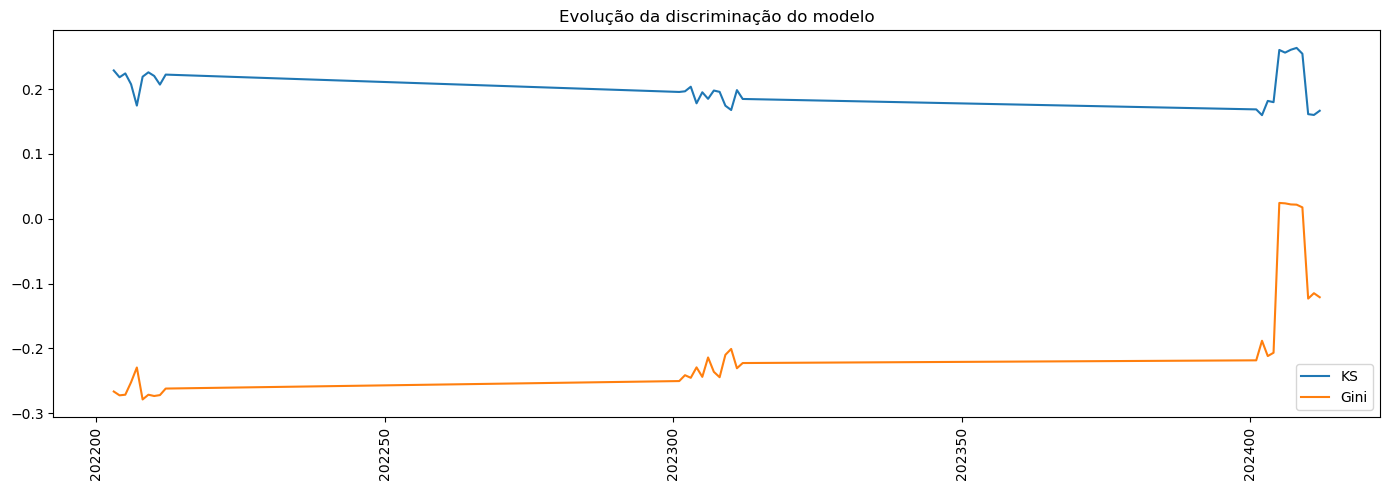

In [330]:
fig, ax = plt.subplots(figsize=(14,5))

ax.plot(evolucao['ano_mes'], evolucao['ks'], label='KS')
ax.plot(evolucao['ano_mes'], evolucao['gini'], label='Gini')

ax.legend()

ax.set_title("Evolução da discriminação do modelo")

ax.tick_params(axis='x', rotation=90)

plt.tight_layout()

In [331]:
evolucao_renda = metricas_periodo(df, 'renda', 'target_trat')
evolucao_renda

,ano_mes,auc,gini,ks,n
0,202203,0.470494,-0.059013,0.059218,20095
1,202204,0.463116,-0.073767,0.064447,20037
2,202205,0.458622,-0.082756,0.073698,19733
3,202206,0.457789,-0.084422,0.069739,19939
4,202207,0.459460,-0.081080,0.077203,20300
5,202208,0.470966,-0.058069,0.053119,19996
6,202209,0.465615,-0.068769,0.059449,19917
7,202210,0.469724,-0.060553,0.053799,20166
8,202211,0.470594,-0.058812,0.051428,20004
9,202212,0.475388,-0.049224,0.055904,19959


### Previsibilidade

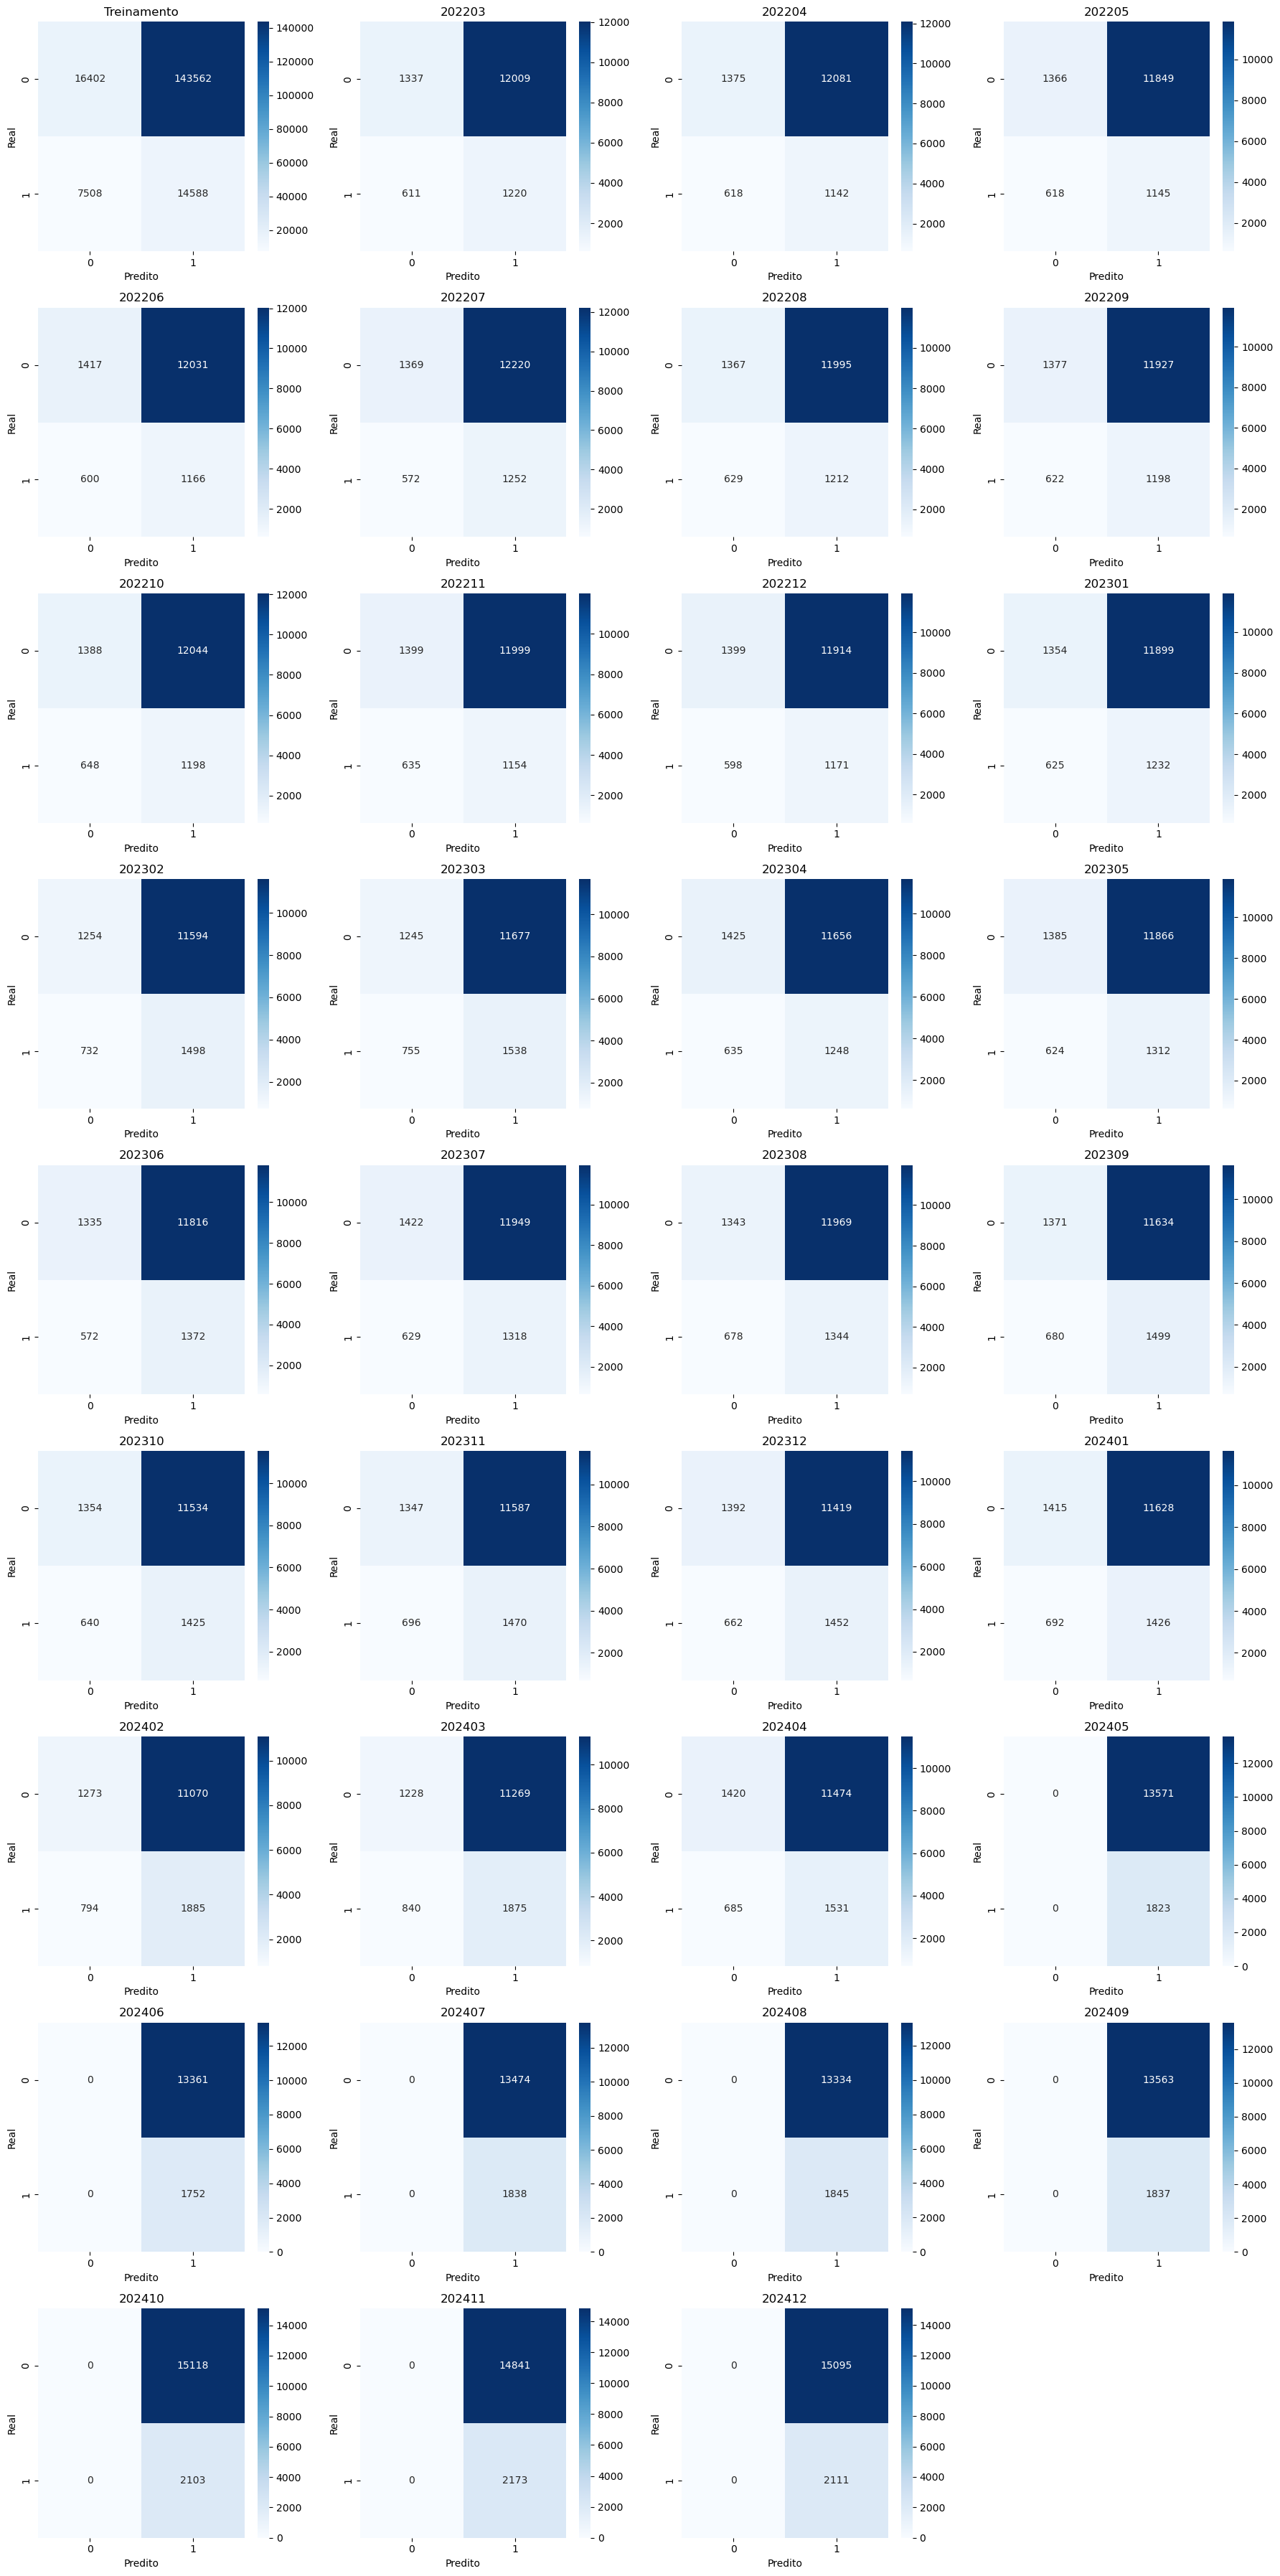

In [245]:
import seaborn as sns
import matplotlib.pyplot as plt
import math

meses = list(mc_mes.keys())

cols = 4
rows = math.ceil((len(meses)+1)/cols)

fig, axes = plt.subplots(rows, cols, figsize=(18,4*rows))

axes = axes.flatten()

# treino
sns.heatmap(
    cm_treino,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)

axes[0].set_title("Treinamento")
axes[0].set_xlabel("Predito")
axes[0].set_ylabel("Real")

# meses
for i, mes in enumerate(meses):

    sns.heatmap(
        mc_mes[mes],
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[i+1]
    )

    axes[i+1].set_title(str(mes))
    axes[i+1].set_xlabel("Predito")
    axes[i+1].set_ylabel("Real")

# remover eixos vazios
for j in range(i+2, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

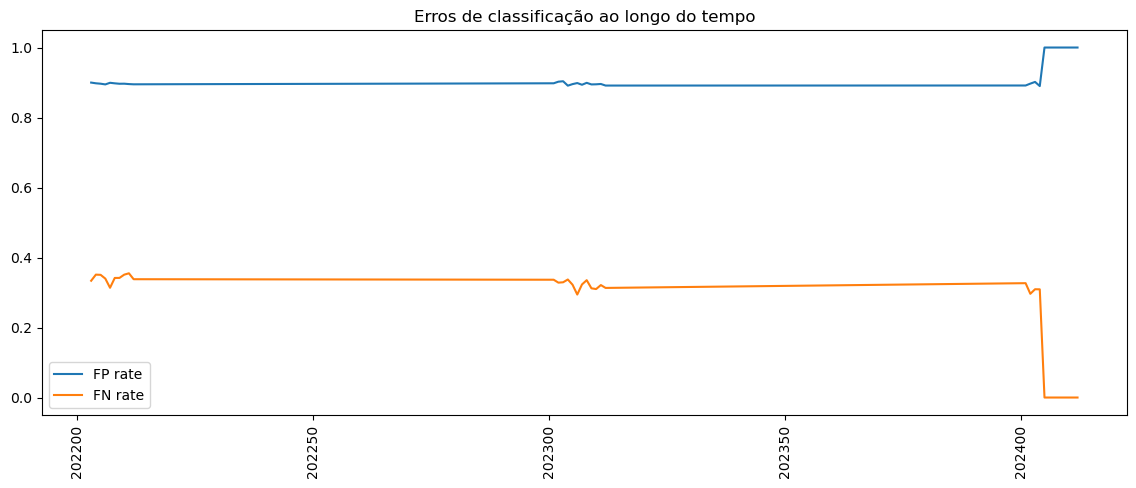

In [247]:
erro_mes = []

for mes, cm in mc_mes.items():

    tn, fp, fn, tp = cm.ravel()

    erro_mes.append({
        'ano_mes': mes,
        'false_positive_rate': fp/(fp+tn),
        'false_negative_rate': fn/(fn+tp)
    })

erro_mes = pd.DataFrame(erro_mes)

plt.figure(figsize=(14,5))

plt.plot(erro_mes['ano_mes'], erro_mes['false_positive_rate'], label='FP rate')
plt.plot(erro_mes['ano_mes'], erro_mes['false_negative_rate'], label='FN rate')

plt.xticks(rotation=90)

plt.title("Erros de classificação ao longo do tempo")

plt.legend()

plt.show()

In [335]:
df_prev = (
    df[df['contratado']==1]
    .groupby(['ano_mes','score'])['target']
    .mean()
    .unstack()
    .reindex(columns=range(1,11))
)

df_prev

score,1,2,3,4,5,6,7,8,9,10
ano_mes,,,,,,,,,,
202203,0.600000,0.403226,0.311111,0.260000,0.183435,0.153153,0.085353,0.044652,0.023322,0.011521
202204,0.578231,0.425000,0.315609,0.241447,0.173577,0.129768,0.082816,0.049518,0.022183,0.009050
202205,0.558333,0.392000,0.352941,0.238469,0.188358,0.127317,0.078222,0.051613,0.026464,0.021635
202206,0.577586,0.391635,0.299020,0.240741,0.167927,0.132727,0.080833,0.051006,0.030197,0.017284
202207,0.525862,0.404762,0.295000,0.238438,0.186339,0.124503,0.097310,0.056742,0.024239,0.018824
202208,0.602941,0.404858,0.347150,0.237911,0.185807,0.137850,0.092246,0.044802,0.021637,0.004773
202209,0.618644,0.398340,0.322222,0.247525,0.184667,0.145363,0.085586,0.048981,0.025235,0.011792
202210,0.547009,0.440154,0.346519,0.244163,0.187778,0.133046,0.086805,0.045884,0.032221,0.012739
202211,0.563025,0.451327,0.323718,0.247887,0.174629,0.123288,0.091033,0.045470,0.027794,0.011905


Ausência de percentual de target nos scores 1 a 4 a partir de mai/2024 reflete a política adotada após implantação do modelo
Assim como os valores zerados em 2025 reflete ainda não termos medições

In [356]:
df_plot = df_prev.copy()

mask = df_plot.index > 202412

df_plot.loc[mask, [5,6,7,8,9,10]] = np.nan

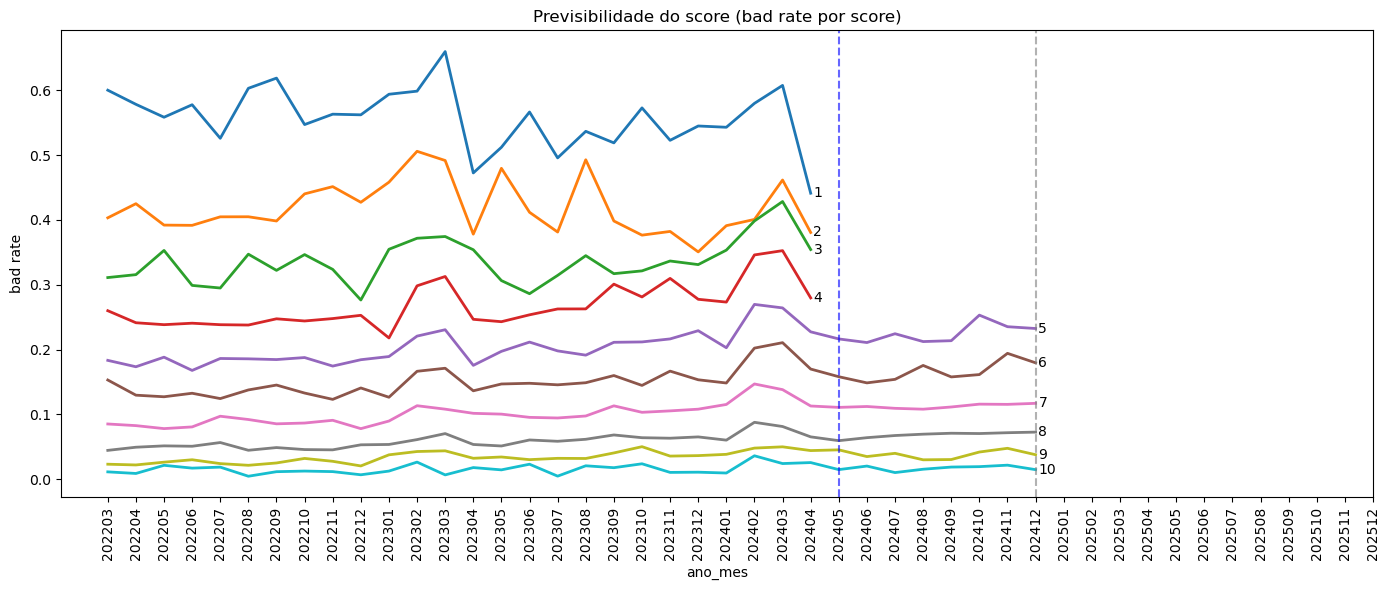

In [357]:
fig, ax = plt.subplots(figsize=(14,6))

x = np.arange(len(df_plot.index))

for score in df_plot.columns:

    y = df_plot[score].values

    ax.plot(x, y, linewidth=2)

    valid = np.isfinite(y)

    if valid.any():

        last_x = x[valid][-1]
        last_y = y[valid][-1]

        ax.text(
            last_x + 0.1,
            last_y,
            str(score),
            va='center',
            fontsize=10
        )

ax.set_xticks(x)
ax.set_xticklabels(df_plot.index, rotation=90)

ax.set_title("Previsibilidade do score (bad rate por score)")
ax.set_xlabel("ano_mes")
ax.set_ylabel("bad rate")

ax.axvline(
    df_plot.index.get_loc(202412),
    linestyle='--',
    color='gray',
    alpha=0.6
)

ax.axvline(
    df_plot.index.get_loc(202405),
    linestyle='--',
    color='blue',
    alpha=0.6
)

plt.tight_layout()
plt.show()

É preocupante o que ocorre com o score 2 em relação ao 3 no período de monitoramento. Isso possivelmente não afetará a implantação do modelo (nega tudo de 4 pra baixo), mas não deveria aontecer. PAra os scores 5 a 10, percebemos que a previsibilidade permanece adequada. (sem cruzamento das linhas)

In [346]:

df_prev = (
    df[df['contratado']==1]
    .groupby(['ano_mes','score'])['target']
    .mean()
    .unstack()
    .reindex(columns=range(1,11))
)

mask = df_prev.index > 202412

df_prev.loc[mask, [5,6,7,8,9,10]] = np.nan

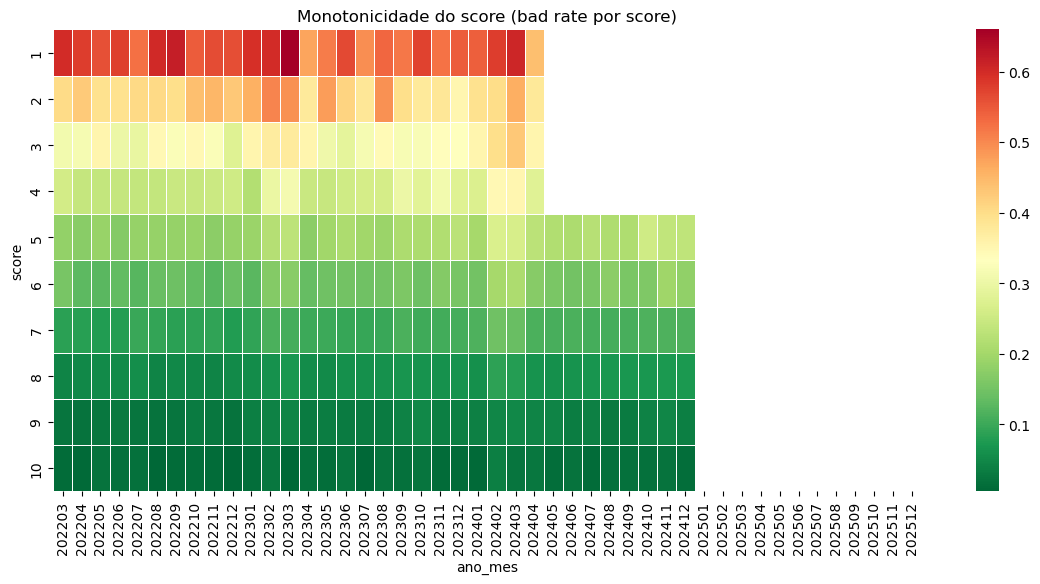

In [347]:


plt.figure(figsize=(14,6))

sns.heatmap(
    df_prev.T,
    cmap="RdYlGn_r",
    linewidths=0.5,
    annot=False
)

plt.title("Monotonicidade do score (bad rate por score)")
plt.xlabel("ano_mes")
plt.ylabel("score")

plt.xticks(rotation=90)

plt.show()

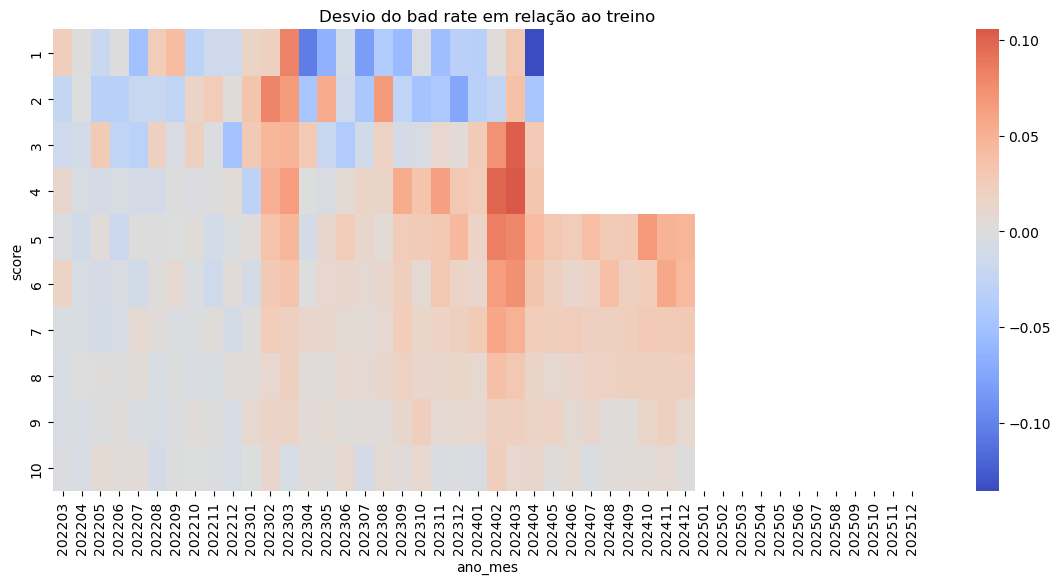

In [348]:
baseline = df_prev.loc[peri_treinamento].mean()

df_dev = df_prev - baseline

plt.figure(figsize=(14,6))

sns.heatmap(
    df_dev.T,
    cmap="coolwarm",
    center=0
)

plt.title("Desvio do bad rate em relação ao treino")

plt.xticks(rotation=90)

plt.show()

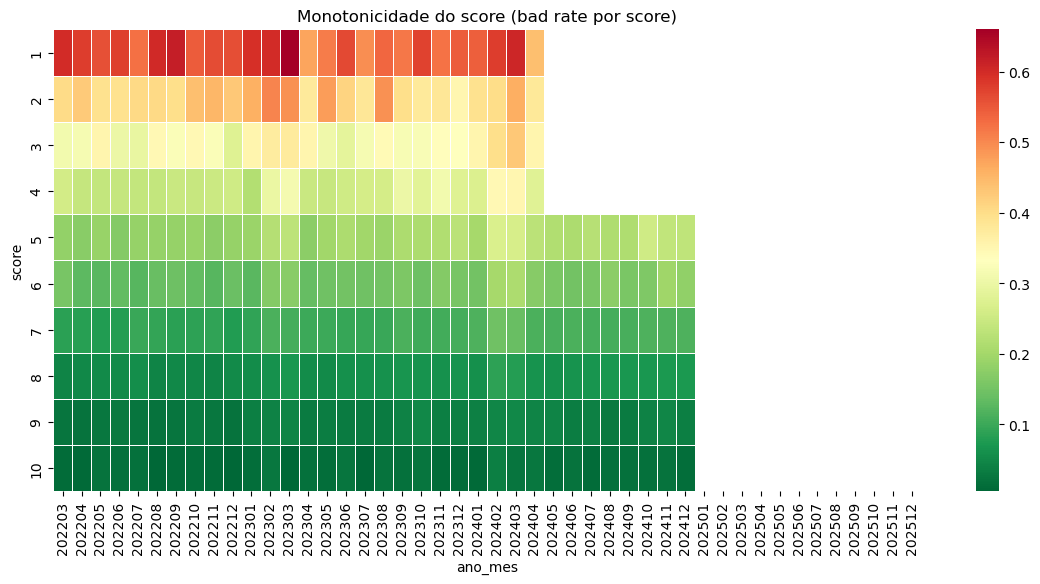

In [349]:
plt.figure(figsize=(14,6))

sns.heatmap(
    df_prev.T,
    cmap="RdYlGn_r",
    linewidths=0.5,
    annot=False
)

plt.title("Monotonicidade do score (bad rate por score)")
plt.xlabel("ano_mes")
plt.ylabel("score")

plt.xticks(rotation=90)

plt.show()

In [352]:
# Distribuição do score

dist_score = pd.crosstab(
    df[df['contratado']==1]['ano_mes'],
    df[df['contratado']==1]['score'],
    normalize='index'
).reindex(columns=range(1,11))

In [353]:
# Previsibilidade

bad_rate = (
    df[df['contratado']==1]
    .groupby(['ano_mes','score'])['target']
    .mean()
    .unstack()
)

In [354]:
# Tx de aprovação

approval = (
    df.groupby(['ano_mes','score'])['contratado']
    .mean()
    .unstack()
)

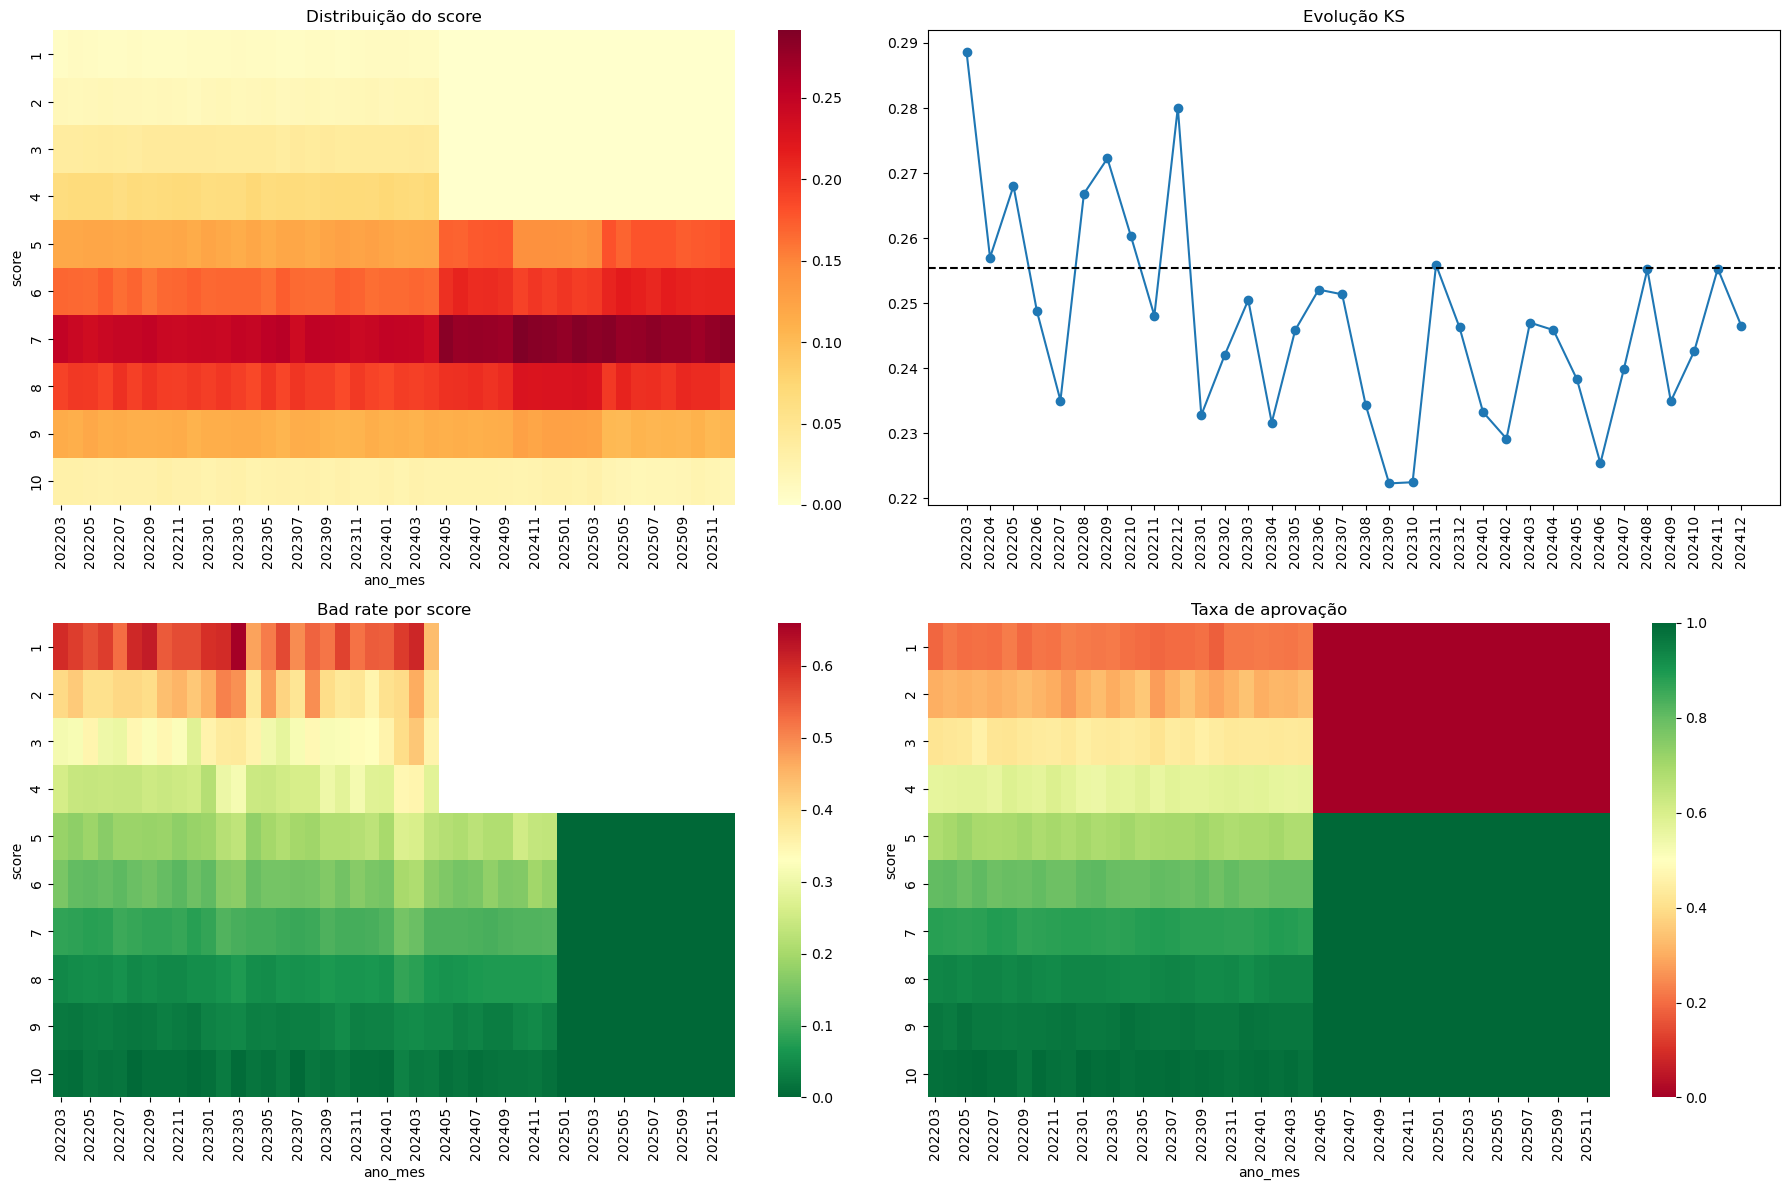

In [355]:
fig = plt.figure(figsize=(18,12))

# ----------------------------
# 1 distribuição do score
# ----------------------------

ax1 = plt.subplot(221)

sns.heatmap(
    dist_score.T,
    cmap="YlOrRd",
    ax=ax1
)

ax1.set_title("Distribuição do score")
ax1.set_xlabel("ano_mes")
ax1.set_ylabel("score")

# ----------------------------
# 2 evolução KS
# ----------------------------

ax2 = plt.subplot(222)

x = range(len(ks_mes))

ax2.plot(x, ks_mes['ks'], marker='o')

ax2.axhline(
    ks_treino_tab['ks'].max(),
    linestyle='--',
    color='black'
)

ax2.set_xticks(x)
ax2.set_xticklabels(ks_mes['ano_mes'], rotation=90)

ax2.set_title("Evolução KS")

# ----------------------------
# 3 previsibilidade
# ----------------------------

ax3 = plt.subplot(223)

sns.heatmap(
    bad_rate.T,
    cmap="RdYlGn_r",
    ax=ax3
)

ax3.set_title("Bad rate por score")

# ----------------------------
# 4 política de aprovação
# ----------------------------

ax4 = plt.subplot(224)

sns.heatmap(
    approval.T,
    cmap="RdYlGn",
    center=0.5,
    ax=ax4
)

ax4.set_title("Taxa de aprovação")

plt.tight_layout()
plt.show()

#### 1) Estabilidade da população (Distribuição do score)

Pelo heatmap superior esquerdo:

        Período inicial (até ~202404) - antes da implantação do modelo

> distribuição relativamente estável

> concentração principal nos scores 6–8

                Após 202404/202405 ocorre uma mudança clara:

> scores 1–4 desaparecem completamente

> população passa a começar no score 5

> forte concentração em scores 6–8

Isso indica claramente:

mudança de política de concessão

Provavelmente algo como: score < 5 → não aprovado

                Consequências:

> população observada muda

> métricas de performance deixam de ser comparáveis com o treino

                ✔ Conclusão do pilar de estabilidade:
                
> A população do modelo sofreu ruptura estrutural a partir de ~202404.

> Essa ruptura é operacional (política de crédito) e não necessariamente do modelo.

#### 2) Discriminação (KS)

> No gráfico superior direito:

        Treinamento (linha tracejada):
                KS ≈ 0.256

                Observações:

Antes da mudança de política (antes da implantação)

        KS varia aproximadamente: 0.235 – 0.28, o que indica discriminação estável e consistente em relação ao treino

Após mudança / implantação do modelo:

        KS na faixa entre 0.22 a 0.25 (remover scores baixos reduz separação observada)
        A redução é leve e esperad, pois quando riscos são eliminados, ks diminui.

        Conclusão:

> O modelo mantém poder discriminatório razoável.

> A leve redução do KS é consistente com a mudança de política e não indica degradação estrutural do modelo.


#### 3️) Previsibilidade (Bad rate por score)

No heatmap inferior esquerdo.

Aqui o comportamento é muito bom.

O gráfico mostra claramente, que  quanto maior score, menor bad rate, ou seja scores maiores relevem menor inadimplência

Além disso:

as cores permanecem relativamente estáveis ao longo do tempo

não aparecem inversões relevantes

Ou seja:

✔ monotonicidade preservada
✔ modelo continua ordenando corretamente risco.

        Conclusão:

> O modelo mantém forte capacidade de ordenação de risco ao longo do tempo.

> Não há evidência de quebra de monotonicidade.




#### 4) Política de aprovação

        Conclusão: 

> A partir de maio/25, não temos aprovação de scores abaixo de 5. Dessa forma, podemos inferir que o score começou a ser utilizado como "regra dura" na política de aprovação. O Score começou a ser utilizado como política de crédito.



In [360]:


df_eval = df.copy()

cutoffs = range(1,11)

result = []

for c in cutoffs:

    aprovados = df_eval[df_eval['score'] >= c]

    approval_rate = len(aprovados) / len(df_eval)

    bad_rate = aprovados['target'].mean()

    result.append({
        'cutoff': c,
        'approval_rate': approval_rate,
        'bad_rate': bad_rate,
        'volume': len(aprovados)
    })

df_cutoff = pd.DataFrame(result)
df_cutoff


,cutoff,approval_rate,bad_rate,volume
0,1,1.000000,0.103524,848001
1,2,0.972410,0.101211,824605
2,3,0.935105,0.097997,792970
3,4,0.867985,0.092011,736052
4,5,0.779689,0.084187,661177
5,6,0.649311,0.071257,550616
6,7,0.488847,0.056920,414543
7,8,0.271929,0.038694,230596
8,9,0.109674,0.025290,93004
9,10,0.020209,0.013207,17137


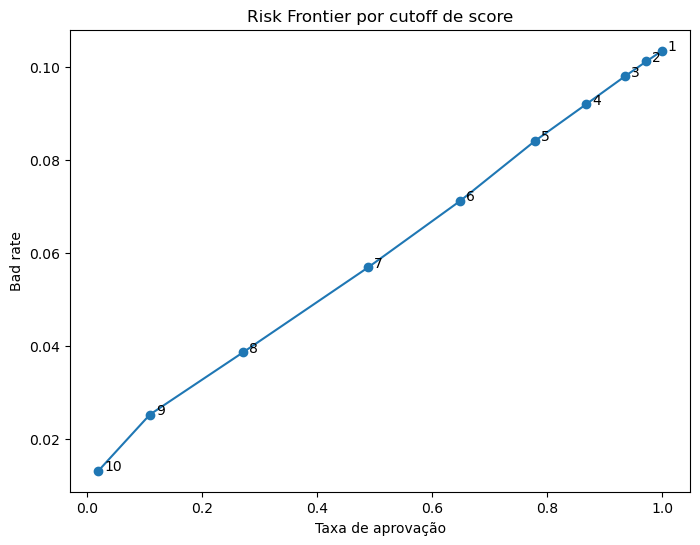

In [361]:
plt.figure(figsize=(8,6))

plt.plot(
    df_cutoff['approval_rate'],
    df_cutoff['bad_rate'],
    marker='o'
)

for i,row in df_cutoff.iterrows():

    plt.text(
        row['approval_rate']+0.01,
        row['bad_rate'],
        str(int(row['cutoff']))
    )

plt.xlabel("Taxa de aprovação")
plt.ylabel("Bad rate")

plt.title("Risk Frontier por cutoff de score")

plt.show()

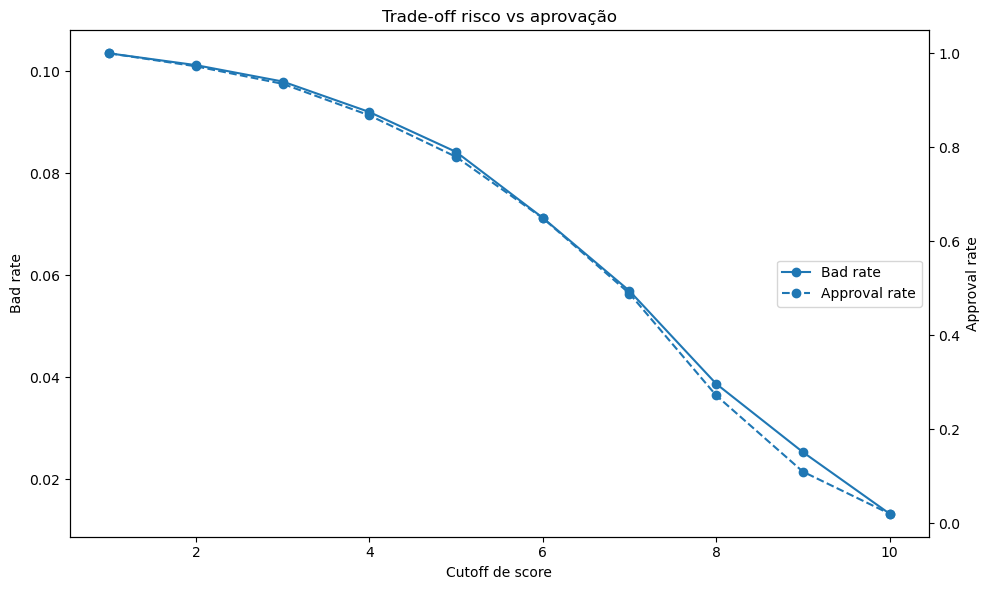

In [363]:
fig, ax1 = plt.subplots(figsize=(10,6))

# linha bad rate
line1 = ax1.plot(
    df_cutoff['cutoff'],
    df_cutoff['bad_rate'],
    marker='o',
    label='Bad rate'
)

ax1.set_ylabel("Bad rate")

# segundo eixo
ax2 = ax1.twinx()

line2 = ax2.plot(
    df_cutoff['cutoff'],
    df_cutoff['approval_rate'],
    marker='o',
    linestyle='--',
    label='Approval rate'
)

ax2.set_ylabel("Approval rate")

# juntar legendas
lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(lines, labels, loc='center right')

ax1.set_xlabel("Cutoff de score")

plt.title("Trade-off risco vs aprovação")

plt.tight_layout()
plt.show()

Nesse gráfico, percebemos que existe uma queda mais acentuada no bad rate após o score 6, o que poderia ser uma alternativa de cutoff mais conservadora. No entanto, 5 com certa de 80% de aprovação pode ser mais adequado à tolerância ao risco.

In [413]:
df['valor_financiado'] = df['valor_medio_fx'] * (1- df['entrada']/100)
df['receita'] = df['tt_financiado_com_juros'] - df['valor_financiado']

In [414]:
df_aval_receita = df.groupby('ano_mes').agg(
    valor_financiado_soma=('valor_financiado','sum'),
    valor_financiado_contagem=('valor_financiado','count'),

    entrada_soma=('entrada','sum'),
    entrada_contagem=('entrada','count'),

    valor_medio_fx_soma=('valor_medio_fx','sum'),
    valor_medio_fx_contagem=('valor_medio_fx','count'),

    tt_financiado_com_juros_soma=('tt_financiado_com_juros','sum'),
    tt_financiado_com_juros_contagem=('tt_financiado_com_juros','count'),

    receita_soma=('receita','sum'),
    receita_contagem=('receita','count')
)

In [416]:
df_aval_receita['tkt_medio_valor_financiado'] = df_aval_receita['valor_financiado_soma'] / df_aval_receita['valor_financiado_contagem']
df_aval_receita['tkt_medio_tt_financiado'] = df_aval_receita['tt_financiado_com_juros_soma'] / df_aval_receita['tt_financiado_com_juros_contagem']
df_aval_receita['receita_media'] = df_aval_receita['receita_soma'] / df_aval_receita['receita_contagem']


In [417]:
df_aval_receita[['tkt_medio_tt_financiado','tkt_medio_valor_financiado','receita_media']].mean()

tkt_medio_tt_financiado       45229.519779
tkt_medio_valor_financiado    34115.258108
receita_media                 11114.261671
dtype: float64

In [419]:
df_aval_receita['tkt_medio_tt_financiado'].mean()

45229.51977877714

In [384]:
df['valor_financiado'] = df['valor_medio_fx'] * (1 - df['entrada']/100)
df['receita']  = df['tt_financiado_com_juros'] - df['valor_financiado'] 

In [439]:
receita_bom = df_aval_receita['receita_media'].mean()     # receita média cliente bom
perda_default = df_aval_receita['tkt_medio_tt_financiado'].mean() * 0.8   # perda média cliente que entra em default 
#(sugerindo que default ocorre com 20% do contrato)

print(f'receita = {receita_bom:.2f}, perda_default = {perda_default:.2f}')

receita = 11114.26, perda_default = 36183.62


In [440]:
cutoffs = range(1,11)

result = []

for c in cutoffs:

    aprovados = df[df['score'] >= c]

    bons = (aprovados['target'] == 0).sum()
    maus = (aprovados['target'] == 1).sum()

    lucro = bons * receita_bom - maus * perda_default

    result.append({
        'cutoff': c,
        'bons': bons,
        'maus': maus,
        'lucro': lucro
    })

df_profit = pd.DataFrame(result)

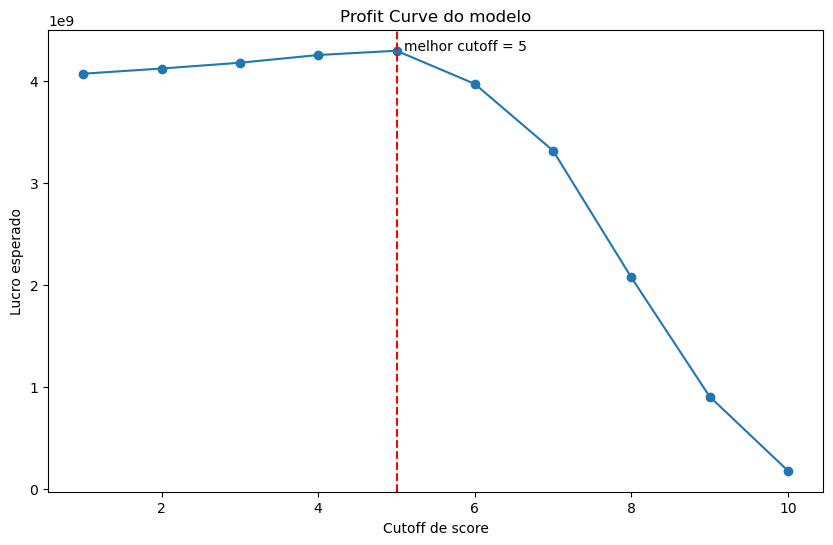

In [441]:

plt.figure(figsize=(10,6))

plt.plot(
    df_profit['cutoff'],
    df_profit['lucro'],
    marker='o'
)

# destacar melhor cutoff
best = df_profit.loc[df_profit['lucro'].idxmax()]

plt.axvline(best['cutoff'], linestyle='--', color='red')

plt.text(
    best['cutoff'] + 0.1,
    best['lucro'],
    f"melhor cutoff = {int(best['cutoff'])}"
)

plt.xlabel("Cutoff de score")
plt.ylabel("Lucro esperado")

plt.title("Profit Curve do modelo")

plt.show()

#### Correlação entre FPD e target

In [442]:
df_fpdt = df.groupby('ano_mes')[['FPD','target']].mean()

df_fpdt.head()

,FPD,target
ano_mes,,
202203,0.029057,0.120643
202204,0.030297,0.115668
202205,0.028175,0.117706
202206,0.029184,0.116077
202207,0.028353,0.118342


In [453]:
# remover períodos sem target
df_fpdt = df_fpdt[df_fpdt.index < 202501]

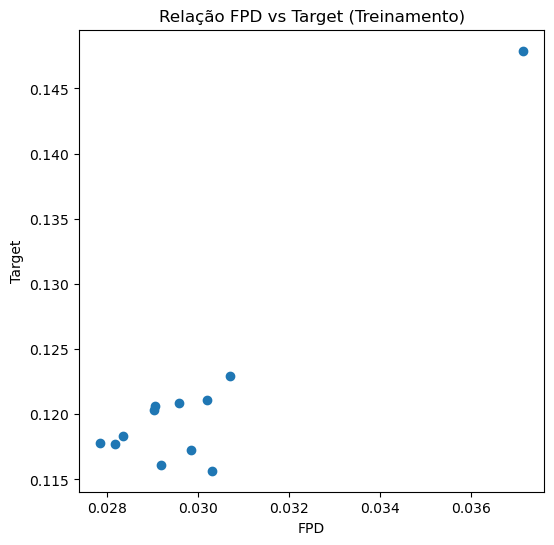

In [454]:
df_treino = df_fpdt.loc[peri_treinamento]

plt.figure(figsize=(6,6))

plt.scatter(
    df_treino['FPD'],
    df_treino['target']
)

plt.xlabel("FPD")
plt.ylabel("Target")

plt.title("Relação FPD vs Target (Treinamento)")

plt.show()

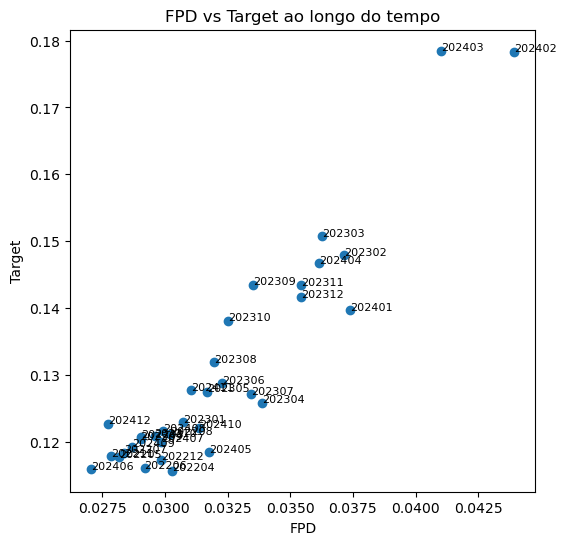

In [465]:
plt.figure(figsize=(6,6))

plt.scatter(
    df_fpdt['FPD'],
    df_fpdt['target']
)

for mes in df_fpdt.index:
    
    plt.text(
        df_fpdt.loc[mes,'FPD'],
        df_fpdt.loc[mes,'target'],
        str(mes),
        fontsize=8
    )

plt.xlabel("FPD")
plt.ylabel("Target")

plt.title("FPD vs Target ao longo do tempo")

plt.show()

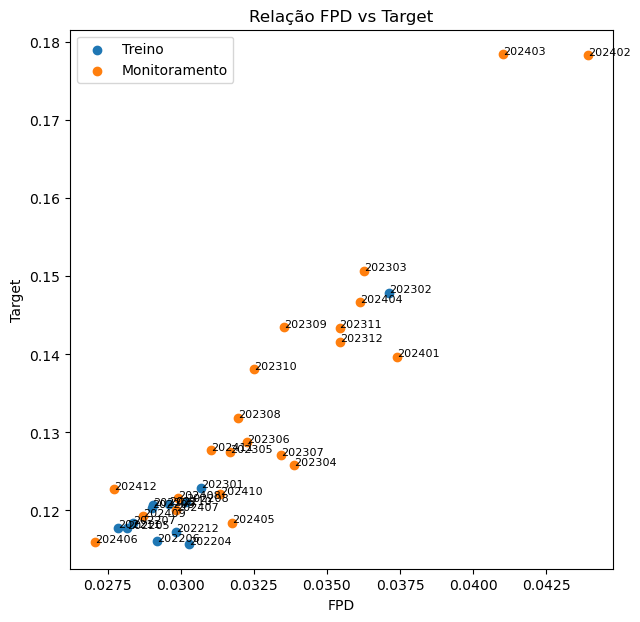

In [466]:
plt.figure(figsize=(7,7))

# treino
plt.scatter(
    df_treino['FPD'],
    df_treino['target'],
    label='Treino'
)

# monitoramento
df_monitor = df_fpdt.drop(peri_treinamento)

plt.scatter(
    df_monitor['FPD'],
    df_monitor['target'],
    label='Monitoramento'
)

for mes in df_fpdt.index:
    
    plt.text(
        df_fpdt.loc[mes,'FPD'],
        df_fpdt.loc[mes,'target'],
        str(mes),
        fontsize=8
    )


plt.xlabel("FPD")
plt.ylabel("Target")


plt.title("Relação FPD vs Target")

plt.legend()

plt.show()

Comportamento de treinamento similar ao comportamento durante janela de observação e produção

In [480]:

x = df_fpdt['FPD']
y = df_fpdt['target']

coef = np.polyfit(x, y, 1)

a = coef[0]   # inclinação
b = coef[1]   # intercepto

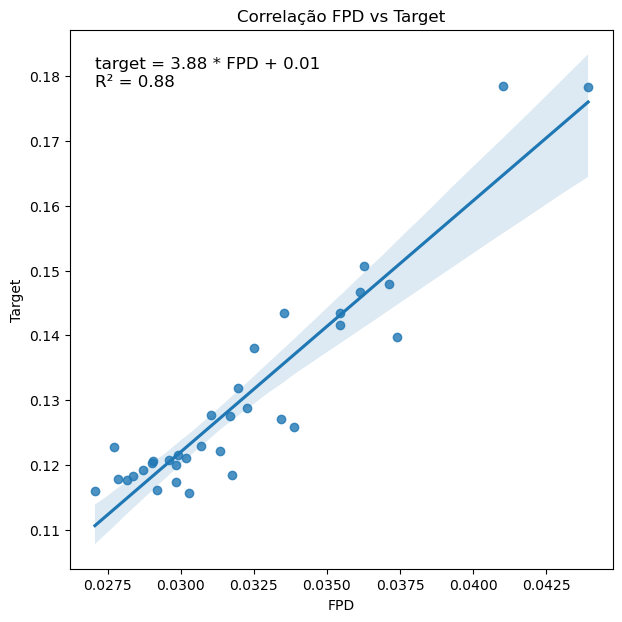

Correlação todo o período: 0.94, treinamento: 0.93


In [477]:
corr_total = df_fpdt['FPD'].corr(df_fpdt['target'])

corr_treino = df_treino['FPD'].corr(df_treino['target'])


plt.figure(figsize=(7,7))

y_pred = a*x + b

r2 = r2_score(y, y_pred)

# equação da reta no gráfico
plt.text(
    x.min(),
    y.max(),
    f"target = {a:.2f} * FPD + {b:.2f}\nR² = {r2:.2f}",
    fontsize=12
)

sns.regplot(
    x=df_fpdt['FPD'],
    y=df_fpdt['target']
)

plt.xlabel("FPD")
plt.ylabel("Target")

plt.title("Correlação FPD vs Target")

plt.show()
print(f'Correlação todo o período: {corr_total:.2f}, treinamento: {corr_treino:.2f}')

correlação é mantida no decorrer do tempo, porém necessário cautela quando tempos valores mais alto de fpd (mais raros também)